# Statistical analysis of the DS / nDS MAR runs

Significance testing behind the wind, surface-density, threshold-friction-velocity
and melt results: reference period (1981-2010) future period (2071-2100), for MAR
forced by CNRM-CM6-1, IPSL-CM6A-LR, MPI-ESM1-2-HR and UKESM1-0-LL under SSP5-8.5.
anomaly=future minus reference


- regional series (whole ice sheet / grounded / shelves), Fisher-Snedecor to pick
  Student or Welch
- pixel by pixel, with the significant pixels on the anomaly maps

**Paths are hardcoded to a local machine.** `BASE_DIR` and `BASE_DIR_MAIN` need
editing before anything will run elsewhere. The MAR output is not in this
repository

The first cell defines the masks and the `ref_dic` / `bs_dic`
dictionaries everything else reads from.

### Base setup: masks, MAR output, regional means

Builds the ice, grounded and shelf masks from the MAR file, opens the DS and nDS runs for the four forcings, and fills `ref_dic` (nDS) and `bs_dic` (DS) with the regionally integrated and averaged series.

/var/folders/m4/s6gxk__51rnfsvq365qr6fx40000gn/T/ipykernel_6498/3558611188.py:232: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmapin= cm.get_cmap('BrBG')
/var/folders/m4/s6gxk__51rnfsvq365qr6fx40000gn/T/ipykernel_6498/3558611188.py:236: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bottom = cm.get_cmap('Blues', 128)
/var/folders/m4/s6gxk__51rnfsvq365qr6fx40000gn/T/ipykernel_6498/3558611188.py:248: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  dates = pd.date_range('1980-01-01', '2100-01-01', freq='AS')
/var/folders/m4/s6gxk__51rnfsvq365qr6fx40000gn/T/ipykernel_6498/3558611188.py

UKM
CM6
MPI
IPL
UKM
CM6
MPI
IPL
UKM
CM6
MPI
IPL


/var/folders/m4/s6gxk__51rnfsvq365qr6fx40000gn/T/ipykernel_6498/3558611188.py:535: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  ablation_dic['TIME'] = pd.date_range('1980-01-01', '2100-01-01', freq='AS')
/var/folders/m4/s6gxk__51rnfsvq365qr6fx40000gn/T/ipykernel_6498/3558611188.py:541: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  area_dic['TIME'] = pd.date_range('1980-01-01', '2100-01-01', freq='AS')


UKM
CM6
MPI
IPL


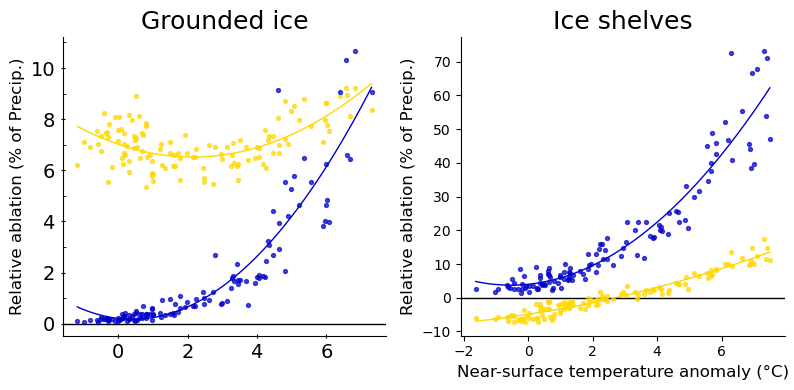

In [98]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Thu May 30 17:18:51 2024

@author: charlesamory
"""
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools

import numpy as np
import numpy.ma as ma # masked array
import xarray as xr
import matplotlib as mpl
import matplotlib.colors as colors
from matplotlib import pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.legend_handler import HandlerLine2D
from matplotlib import ticker as mticker

#import plotlib as pls


import matplotlib.gridspec as gridspec


import shade2D as shade


plt.close('all')

# =============================================================================
# Definition of ICE MASK ; used color maps, 
# =============================================================================
MSK,ice,lsm,ground,shelf,x2D,y2D,sh,dh,rock,ice_msk,grd_msk = shade.ice_masking()

# =============================================================================
# 2. CREATE the ICE MASK 
# =============================================================================
test = xr.open_dataset('/Users/dashakan/Desktop/scripts_AIS/MARcst-AN35km-176x148.cdf2'
                       ,decode_times=False,engine="netcdf4")
#test=test.rename_dims({'x':'X', 'y':'Y'}) #change dim name
#Only AIS=1, other islands  =0
ais = test['AIS'].where(test['AIS'] >0) 
#Ice where ICE mask >= 30% (ICE[0-100%], dividing by 100 in the next ligne)
ice= test['ICE'].where(test['ICE']>30)  
#Combine ais + ice/100 * factor area for taking into account the projection deformation
ice_msk = (ais*ice*test['AREA']/ 100)    

#ground mask
grd=test['GROUND'].where (test['GROUND']>30)# & (test['SH']<1000) )
grd_msk = (ais*grd*test['AREA']/ 100)

#ice-shelf mask
shf=test['ICE'].where((test['ICE']>30) & (test['GROUND']<50) & (test['ROCK']<30))
shf_msk=(shf*test['AREA'])/100

rig=test['RIGNOT']
west=shf.where((rig==1) | (rig==2) | (rig==9) | (rig==14) | (rig==18)  | (rig==24) | (rig==24.5) | (rig==19) | (rig==19.5) |(rig==20) | (rig==20.5 ) )
west_msk=(west*test['AREA'])/100.

east=shf.where( (rig==3) | (rig==4) | (rig==5) | (rig==10) | (rig==12)  | (rig==23)  | (rig==23.5) | (rig==6) | (rig==7) | (rig==8) | (rig==11) | (rig==13)  | (rig==21) | (rig==22) | (rig==21.5) | (rig==22) )
east_msk=(east*test['AREA'])/100.

peni = shf.where((rig==15) | (rig==16) | (rig==17) | (rig==15) | (rig==25)  | (rig==25.5) | (rig==26) | (rig==26.5))
peni_msk=(peni*test['AREA'])/100.


cmap_seq, cmap_smb, cmap_div, cmap_qual, cmap_BuRd, obs_color, sh_color, cmap_Puor = shade.def_cmaps()

dpi=300

def preprocess(ds):
    '''
    Avoid reading/opening the whole ds. => Selection of interesting variable
    Also try to remove SECTOR dimension 
    (Sector=1 corresponds to the ice sheet in MAR (2= tundra or rocks))
    '''
    #ds_new = ds['ME', 'RU', 'RF', 'SF', 'SU','SMB']
    ds_new = ds
    try:
        ds_new= ds_new.sel(SECTOR=1) #SMB RU SU
        ds_new= ds_new.sel(SECTOR1_1=1) #SMB RU SU
        ds_new['TT']=ds_new['TT'].sel(ATMLAY=0.99973)
        #ds_new['Ablation area']=(ds_new['SMB']<0)
        #ds_new['Ablation area']=(ds_new['SF']+ds_new['RF']-ds_new['ER']-ds_new['RU']-ds_new['SU'])<0
        #ds_new['Runoff area']=(ds_new['RU']>1)
        #ds_new['Runoff area']=(ds_new['RU']>ds_new['SF'])
        ds_new['Melt area']=(ds_new['ME']>1)
        #ds_new['Erosion area']=((ds_new['ER']/ds_new['SF'])>0.5)
        ds_new['Erosion area']=((ds_new['ER']>ds_new['SF']))
        
    except:
        ds_new=ds_new
    try:
        ds_new= ds_new.sel(SECTOR1_1=1) #SMB RU SU

    except:
        ds_new=ds_new
    try:
        ds_new=ds_new.rename_dims({'x':'X','y':'Y'})
        #ds_new=ds_new.rename_vars({'x':'X','y':'Y'})
    except:
        ds_new=ds_new
        
    
    # try:
    # #     ds_new['IDX']= ds_new['IDX'].sel(SECTOR1_1=1) #ME
    #      ds_new['ME']= ds_new['ME'].sel(SECTOR1_1=1) #ME
    # except:
    # #     ds_new['IDX']=ds_new['IDX'] 
    #      ds_new['ME']=ds_new['ME'] 
    # try:
    #     ds_new= ds_new.sel(SECTOR='1')
    # except:
    #     ds_new=ds_new
    # try:
    #     ds_new= ds_new.sel(SECTOR1_1='1')
    # except:
    #     ds_new=ds_new
    return ds_new


def SMBcomponents_to_gt(SMB_array, variable,mask, data_start=1980, data_end=2100,reso=35):
    '''This function returns a daily time series of absolute SMB
    component values, expressed as gigatons.
    35 000 m = MAR resolution
    1e12 factor to convert kg/m² in Gt
     mask= [~0-~1] values weighted by 1) ice fraction 2) area factor related to proj
    '''
    reso=reso*1000
    data = SMB_array[variable] * mask.values
    # Make sure only wanted time frame is used
    data = data.loc[str(data_start) + '-01-01':str(data_end) + '-12-31']
    # Convert to gigatons and sum up spatially over the AIS
    sum_spatial = data.sum(dim=['X', 'Y']
                           ) * ((reso * reso) / (1e12))

    return sum_spatial

def date(ys,ye,freq='AS'):
    if freq=='AS':
        return pd.date_range(str(ys)+'-01-01', str(ye)+'-01-01', freq=freq)
    if freq=='D':
        return pd.date_range(str(ys)+'-01-01', str(ye)+'-12-31', freq=freq)

def spcolor(var2D,cmap,bounds,sig):
    return shade.spcolor(x2D,y2D,var2D,cmap,bounds,dh,sig)

def spcolor2(var2D,cmap,sig,vmin,vmax):
    return shade.spcolor2(x2D,y2D,var2D,cmap,dh,sig,vmin,vmax)

def annual_mean(data):
    '''
    This function returns the annual sum
    '''
    annual_mean = data.mean(dim='TIME')
    return annual_mean

def compute_ano(df,refs,refe,period):
    '''
    This function returns a ds(!) with the anomalie compared to the reference period (refs--refe)
    + a rolling mean (period)
    '''
    dfo= df - df.sel(TIME=slice(str(refs)+'-01-01',str(refe)+'-01-01')).mean(dim=['TIME'])
    dfor= dfo.rolling(TIME=period, center=True).mean()
    return dfor 

def compute_int(list_SMB, variables, list_names,msk, data_start, data_end,season='annual'):
    #df = pd.DataFrame()
    df=list_SMB.copy()
    for var in variables:
        SMB_ts = SMBcomponents_to_gt(
            list_SMB, var, msk, data_start, data_end)
        if var =='EI':
            data=list_SMB['EI']
            SMB_ts=spatial_mean(data,msk)
        if var =='Ablation area'or var =='Runoff area' or var =='Melt area' or var =='Erosion area' or var =='Sublimation area':
            SMB_ts=extent(list_SMB, var, msk, data_start, data_end)
        df[var] = SMB_ts

    return df

def spatial_mean(SMB_array, variable,mask, data_start=1980, data_end=2100):
    '''
    This function returns the spatial mean
    '''
    data = SMB_array[variable] * mask.values
    data = data.loc[str(data_start) + '-01-01':str(data_end) + '-12-31']
    mean_spatial =data.mean(dim=['X', 'Y'])
    

    return mean_spatial

def compute_ave(list_SMB, variables, list_names,msk, data_start, data_end,season='annual'):
    '''
    This function returns a ds(!) with the original variables but averaged
    spatially over the ice sheet/region
    '''
    df=list_SMB.copy()
    for var in variables:
        var_ts = spatial_mean(list_SMB, var, msk, data_start, data_end)
        df[var] = var_ts

    return df

def extent(SMB_array, variable,mask, data_start=1980, data_end=2100):
    '''This function returns a time series of the (Melt/Ru/ablation) extent of the ice sheet area,
    expressed as %.
    35 000 m = MAR resolution
    1e12 factor to convert kg/m² in Gt
    '''
    
    data = SMB_array[variable] * mask.values
    # Make sure only wanted time frame is used
    data = data.loc[str(data_start) + '-01-01':str(data_end) + '-12-31']
    # Convert to gigatons and sum up spatially over the AIS
    sum_spatial = data.sum(dim=['X', 'Y']) * (35 * 35) 
    
    ice_extent= mask.sum(dim=['X', 'Y']) * (35 * 35)
    
    fraction=sum_spatial*100/ice_extent

    return fraction


from matplotlib.colors import ListedColormap, LinearSegmentedColormap
cmapblue = LinearSegmentedColormap.from_list("", ["white","navy"])
cmapin= cm.get_cmap('BrBG')
newcmp = ListedColormap(cmapin(np.linspace(0, 0.5, 128)))
#top = cm.get_cmap('Oranges_r', 128)
top=newcmp
bottom = cm.get_cmap('Blues', 128)
#bottom=cmapblue
newcolors = np.vstack((top(np.linspace(0, 1, 128)),
                       bottom(np.linspace(0, 1, 128))))
newcmp = ListedColormap(newcolors, name='BlOr')
    
# =============================================================================
# 3. OPEN MAR outputs
# =============================================================================

#A MAR NON DRIFT
#Definition of the period. WARNING
dates = pd.date_range('1980-01-01', '2100-01-01', freq='AS') 


UKMr = xr.open_mfdataset('/Users/dashakan/Desktop/scripts_AIS/year-MAR-nDS_UKM-1980-2100.nc',decode_times=False,preprocess=preprocess,engine="netcdf4")
UKMr['TIME']=dates
UKMr['P']=UKMr['SF']+UKMr['RF']
UKMr['Runoff area']=UKMr['RU']>UKMr['P']
UKMr['Ablation area']=UKMr['SMB']<0

MPIr = xr.open_mfdataset('/Users/dashakan/Desktop/scripts_AIS/year-MAR-nDS_MPI-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4") 
MPIr['TIME']=dates
MPIr['P']=MPIr['SF']+MPIr['RF']
MPIr['Runoff area']=MPIr['RU']>MPIr['P']
MPIr['Ablation area']=MPIr['SMB']<0

CM6r = xr.open_mfdataset('/Users/dashakan/Desktop/scripts_AIS/year-MAR-nDS_CNRM-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4")
CM6r['TIME']=dates
CM6r['P']=CM6r['SF']+CM6r['RF']
CM6r['Runoff area']=CM6r['RU']>CM6r['P']
CM6r['Ablation area']=CM6r['SMB']<0

IPLr = xr.open_mfdataset('/Users/dashakan/Desktop/scripts_AIS/year-MAR-nDS_IPL-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4")
IPLr['TIME']=dates
IPLr['P']=IPLr['SF']+IPLr['RF']
IPLr['Runoff area']=IPLr['RU']>IPLr['P']
IPLr['Ablation area']=IPLr['SMB']<0

# Not visible one
#CM2r = xr.open_mfdataset('./data_melt/year-MAR-nDS_CESM2-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4")
#CM2r = xr.open_mfdataset('./data_melt/year-MAR_CESM2v2-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4")
#CM2r['TIME']=dates
#CM2r['P']=CM2r['SF']+CM2r['RF']
#CM2r['Runoff area']=CM2r['RU']>CM2r['P']
#CM2r['Ablation area']=CM2r['SMB']<0
   
list_mod_ref = []
list_mod_ref=[UKMr,CM6r,MPIr,IPLr]
#list_mod_ref=[UKMr,CM6r,MPIr,IPLr,CM2r]
list_mod_names = []
list_mod_names=['UKM','CM6','MPI', 'IPL']
#list_mod_names=['UKM','CM6','MPI', 'IPL','CM2']


#B MAR DRIFT
#Definition of the period. WARNING
dates = pd.date_range('1980-01-01', '2100-01-01', freq='AS') 

UKM = xr.open_mfdataset('/Users/dashakan/Desktop/scripts_AIS/year-MAR-DS_UKM-1980-2100.nc',decode_times=False,preprocess=preprocess,engine="netcdf4")
UKM['TIME']=dates
UKM['P']=UKMr['SF']+UKM['RF']
UKM['Runoff area']=UKM['RU']>UKM['P']
#UKM['Runoff area']=UKM['RU']>(UKM['SF']+UKM['RF'])
UKM['Sublimation area']=UKM['SU']>UKM['P']
#UKM['Sublimation area']=UKM['SU']>(UKM['SF']+UKM['RF']-UKM['ER'])
#UKM['Ablation area']=UKM['SMB'].where((UKM['SMB']<0) | (UKM['RU']>UKM['P']) | (UKM['SU']>UKM['P']) | (UKM['ER']>UKM['P']))
#UKM['Ablation area']=UKM['RU']>UKM['P']
#UKM['Ablation area']=UKM['P']
#UKM['Ablation area']=UKM['SMB']<0
#UKM['Ablation area']=UKM['Ablation area'].where((UKM['RU']>UKM['P']) | (UKM['SMB']<0) | (UKM['SU']>UKM['P']) | (UKM['ER']>UKM['P']))
#UKM['Ablation area']=UKM['SMB'].where((UKM['RU']>UKM['P']) | (UKM['SMB']<0) | (UKM['SU']>UKM['P']) | (UKM['ER']>UKM['P']))
#UKM['Erosion area']=(UKM['SF']+UKM['RF']-UKM['ER'])<UKMr['P']

UKM['Erosion area']=UKM['ER']>(UKM['SF']+UKM['RF'])
UKM['Runoff area']=UKM['RU']>(UKM['SF']+UKM['RF']-UKM['ER'])
UKM['Ablation area']=(UKM['SF']+UKM['RF']-UKM['ER']-UKM['RU']-UKM['SU'])<0

MPI = xr.open_mfdataset('/Users/dashakan/Desktop/scripts_AIS/year-MAR-DS_MPI-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4") 
MPI['TIME']=dates
MPI['P']=MPIr['SF']+MPI['RF']
MPI['Runoff area']=MPI['RU']>MPI['P']
#MPI['Runoff area']=MPI['RU']>(MPI['SF']+MPI['RF'])
MPI['Sublimation area']=MPI['SU']>MPI['P']
#MPI['Sublimation area']=MPI['SU']>(MPI['SF']+MPI['RF']-MPI['ER'])
#MPI['Ablation area']=MPI['RU']>MPI['P']
#MPI['Ablation area']=MPI['P']
#MPI['Ablation area']=MPI['SMB']<0
#MPI['Ablation area']=MPI['Ablation area'].where((MPI['RU']>MPI['P']) | (MPI['SMB']<0) | (MPI['SU']>MPI['P']) | (MPI['ER']>MPI['P']))
#MPI['Ablation area']=MPI['SMB'].where((MPI['RU']>MPI['P']) | (MPI['SMB']<0) | (MPI['SU']>MPI['P']) | (MPI['ER']>MPI['P']))
#MPI['Erosion area']=(MPI['SF']+MPI['RF']-MPI['ER'])<MPIr['P']

MPI['Erosion area']=MPI['ER']>(MPI['SF']+MPI['RF'])
MPI['Runoff area']=MPI['RU']>(MPI['SF']+MPI['RF']-MPI['ER'])
MPI['Ablation area']=(MPI['SF']+MPI['RF']-MPI['ER']-MPI['RU']-MPI['SU'])<0


CM6 = xr.open_mfdataset('/Users/dashakan/Desktop/scripts_AIS/year-MAR-DS_CNRM-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4")
CM6['TIME']=dates
CM6['P']=CM6r['SF']+CM6['RF']
CM6['Runoff area']=CM6['RU']>CM6['P']
#CM6['Runoff area']=CM6['RU']>(CM6['SF']+CM6['RF'])
CM6['Sublimation area']=CM6['SU']>CM6['P']
#CM6['Sublimation area']=CM6['SU']>(CM6['SF']+CM6['RF']-CM6['ER'])
#CM6['Ablation area']=CM6['RU']>CM6['P']
#CM6['Ablation area']=CM6['P']
#CM6['Ablation area']=CM6['SMB']<0
#CM6['Ablation area']=CM6['Ablation area'].where((CM6['RU']>CM6['P']) | (CM6['SMB']<0 ) | (CM6['SU']>CM6['P']) | (CM6['ER']>CM6['P']))
#CM6['Ablation area']=CM6['SMB'].where((CM6['RU']>CM6['P']) | (CM6['SMB']<0 ) | (CM6['SU']>CM6['P']) | (CM6['ER']>CM6['P']))
#CM6['Erosion area']=(CM6['SF']+CM6['RF']-CM6['ER'])<CM6r['P']

CM6['Erosion area']=CM6['ER']>(CM6['SF']+CM6['RF'])
CM6['Runoff area']=CM6['RU']>(CM6['SF']+CM6['RF']-CM6['ER'])
CM6['Ablation area']=(CM6['SF']+CM6['RF']-CM6['ER']-CM6['RU']-CM6['SU'])<0


IPL = xr.open_mfdataset('/Users/dashakan/Desktop/scripts_AIS/year-MAR-DS_IPL-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4")
IPL['TIME']=dates
IPL['P']=IPLr['SF']+IPL['RF']
#IPL['Runoff area']=IPL['RU']>IPL['P']
#IPL['Runoff area']=IPL['RU']>(IPL['SF']+IPL['RF'])
IPL['Sublimation area']=IPL['SU']>IPL['P']
#IPL['Ablation area']=IPL['RU']>IPL['P']
#IPL['Ablation area']=IPL['P']
#IPL['Ablation area']=IPL['SMB']<0
#IPL['Ablation area']=IPL['Ablation area'].where((IPL['RU']>IPL['P']) | (IPL['SMB']<0 ) | (IPL['SU']>IPL['P']) | (IPL['ER']>IPL['P']))
#IPL['Ablation area']=IPL['SMB'].where((IPL['RU']>IPL['P']) | (IPL['SMB']<0 ) | (IPL['SU']>IPL['P']) | (IPL['ER']>IPL['P']))
#IPL['Erosion area']=(IPL['SF']+IPL['RF']-IPL['ER'])<IPLr['P']

IPL['Erosion area']=IPL['ER']>(IPL['SF']+IPL['RF'])
IPL['Runoff area']=IPL['RU']>(IPL['SF']+IPL['RF']-IPL['ER'])
IPL['Ablation area']=(IPL['SF']+IPL['RF']-IPL['ER']-IPL['RU']-IPL['SU'])<0

# ! not visible dataset
#CM2 = xr.open_mfdataset('./data_melt/year-MAR-DS_CESM2-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4")
#CM2['TIME']=dates
#CM2['P']=CM2r['SF']+CM2['RF']
#CM2['Erosion area']=CM2['ER']>(CM2['SF']+CM2['RF'])
#CM2['Runoff area']=CM2['RU']>CM2['P']
#CM2['Sublimation area']=CM2['SU']>CM2r['P']
#CM2['Ablation area']=CM2['SMB'].where((CM2['SMB']<0) | (CM2['RU']>CM2['P']) | (CM2['SU']>CM2['P']) | (CM2['ER']>CM2['P']))


   
list_mod_bs = []
list_mod_bs=[UKM,CM6,MPI,IPL]
#list_mod_bs=[UKM,CM6,MPI,IPL,CM2]
     
## =============================================================================
# 4. COMPUTE AVERAGED VALUES + (rolling) ANOMALIES for all the variables
# =============================================================================

#rolling mean period 
rolling=1
#definition of the variables
vars_SMB = ['P','SMB','SF','RF','ME','RU','SU','Ablation area','Runoff area','Melt area']
#vars_mean = ['TT','SHF','LWD','SWD','IWP','CWP','LHF','AL2','WVP']
vars_mean=['TT']

result_ice_dic = {}
result_ice_ano_dic={}

result_grd_dic={}
result_grd_ano_dic={}

result_shf_dic={}
result_shf_ano_dic={}

###################
### A. No drift ###
###################

## i) compute spatially integrated anomalies

for i in range(len(list_mod_ref)):
    print (list_mod_names[i])
    #ALL AIS
    dfi=compute_int(list_mod_ref[i], vars_SMB, list_mod_names[i],ice_msk, 1980, 2100)
    result_ice_dic[list_mod_names[i]]=dfi   
    dfano=compute_ano(dfi,1981,2010,rolling)
    result_ice_ano_dic[list_mod_names[i]]=dfano
        
    #Grounded only
    dfg=compute_int(list_mod_ref[i], vars_SMB, list_mod_names[i],grd_msk, 1980, 2100)
    result_grd_dic[list_mod_names[i]]=dfg 
    dfano=compute_ano(dfg,1981,2010,rolling)
    result_grd_ano_dic[list_mod_names[i]]=dfano   
      
    #Shelves only
    dfs=compute_int(list_mod_ref[i], vars_SMB, list_mod_names[i],shf_msk, 1980, 2100)
    result_shf_dic[list_mod_names[i]]=dfs  
    dfano=compute_ano(dfs,1981,2010,rolling)
    result_shf_ano_dic[list_mod_names[i]]=dfano


ref_dic = {}
ref_dic['ice']=result_ice_dic
ref_dic['grd']=result_grd_dic
ref_dic['shelf']=result_shf_dic
ref_dic_ano = {}
ref_dic_ano['ice']=result_ice_ano_dic
ref_dic_ano['grd']=result_grd_ano_dic
ref_dic_ano['shelf']=result_shf_ano_dic


## ii) compute spatially averaged anomalies

result_ice_dic = {}
result_ice_ano_dic={}
result_grd_dic={}
result_grd_ano_dic={}
result_shf_dic={}
result_shf_ano_dic={}

for i in range(len(list_mod_ref)):
    print (list_mod_names[i])
    #ALL AIS
    dfi=compute_ave(list_mod_ref[i], vars_mean, list_mod_names[i],ice_msk, 1980, 2099)
    result_ice_dic[list_mod_names[i]]=dfi    
    dfano=compute_ano(dfi,1981,2010,rolling)
    result_ice_ano_dic[list_mod_names[i]]=dfano
        
    #Grounded only
    dfg=compute_ave(list_mod_ref[i], vars_mean, list_mod_names[i],grd_msk, 1980, 2099)
    result_grd_dic[list_mod_names[i]]=dfg    
    dfano=compute_ano(dfg,1981,2010,rolling)
    result_grd_ano_dic[list_mod_names[i]]=dfano   
    
    
    #Shelves only
    dfs=compute_ave(list_mod_ref[i], vars_mean, list_mod_names[i],shf_msk, 1980, 2099)
    result_shf_dic[list_mod_names[i]]=dfs 
    dfano=compute_ano(dfs,1981,2010,rolling)
    result_shf_ano_dic[list_mod_names[i]]=dfano

ref_dicm = {}
ref_dicm['ice']=result_ice_dic
ref_dicm['grd']=result_grd_dic
ref_dicm['shelf']=result_shf_dic
ref_dicm_ano = {}
ref_dicm_ano['ice']=result_ice_ano_dic
ref_dicm_ano['grd']=result_grd_ano_dic
ref_dicm_ano['shelf']=result_shf_ano_dic



################
### B. Drift ###
################

## i) compute spatially integrated anomalies

result_ice_dic = {}
result_ice_ano_dic={}

result_grd_dic={}
result_grd_ano_dic={}

result_shf_dic={}
result_shf_ano_dic={}

vars_SMB = ['SMB','SF','RF','ME','RU','SU','ER','Ablation area','Runoff area','Melt area','Erosion area', 'Sublimation area']


for i in range(len(list_mod_bs)):
    print (list_mod_names[i])
    #ALL AIS
    dfi=compute_int(list_mod_bs[i], vars_SMB, list_mod_names[i],ice_msk, 1980, 2100)
    result_ice_dic[list_mod_names[i]]=dfi   
    dfano=compute_ano(dfi,1981,2010,rolling)
    result_ice_ano_dic[list_mod_names[i]]=dfano
        
    #Grounded only
    dfg=compute_int(list_mod_bs[i], vars_SMB, list_mod_names[i],grd_msk, 1980, 2100)
    result_grd_dic[list_mod_names[i]]=dfg 
    dfano=compute_ano(dfg,1981,2010,rolling)
    result_grd_ano_dic[list_mod_names[i]]=dfano   
      
    #Shelves only
    dfs=compute_int(list_mod_bs[i], vars_SMB, list_mod_names[i],shf_msk, 1980, 2100)
    result_shf_dic[list_mod_names[i]]=dfs  
    dfano=compute_ano(dfs,1981,2010,rolling)
    result_shf_ano_dic[list_mod_names[i]]=dfano
    
    
bs_dic = {}
bs_dic['ice']=result_ice_dic
bs_dic['grd']=result_grd_dic
bs_dic['shelf']=result_shf_dic

bs_dic_ano = {}
bs_dic_ano['ice']=result_ice_ano_dic
bs_dic_ano['grd']=result_grd_ano_dic
bs_dic_ano['shelf']=result_shf_ano_dic

ablation_dic = {}
ablation_dic['ice'] = {}
ablation_dic['grd'] = {}
ablation_dic['shelf'] = {}
ablation_dic['TIME'] = pd.date_range('1980-01-01', '2100-01-01', freq='AS')

area_dic = {}
area_dic['ice'] = {}
area_dic['grd'] = {}
area_dic['shelf'] = {}
area_dic['TIME'] = pd.date_range('1980-01-01', '2100-01-01', freq='AS')

#models = ['UKM','CM6','MPI', 'IPL','CM2']
years = pd.date_range(start='1980-01-01', periods=121, freq='YS')
#data = np.random.rand(len(list_mod_names), len(years)) # que tu remplis plus tard avec tes vraies valeurs


## ii) compute spatially averaged anomalies

result_ice_dic = {}
result_ice_ano_dic={}
result_grd_dic={}
result_grd_ano_dic={}
result_shf_dic={}
result_shf_ano_dic={}

for i in range(len(list_mod_bs)):
    print (list_mod_names[i])
    #ALL AIS
    dfi=compute_ave(list_mod_bs[i], vars_mean, list_mod_names[i],ice_msk, 1980, 2100)
    result_ice_dic[list_mod_names[i]]=dfi    
    dfano=compute_ano(dfi,1981,2010,rolling)
    result_ice_ano_dic[list_mod_names[i]]=dfano
        
    #Grounded only
    dfg=compute_ave(list_mod_bs[i], vars_mean, list_mod_names[i],grd_msk, 1980, 2100)
    result_grd_dic[list_mod_names[i]]=dfg    
    dfano=compute_ano(dfg,1981,2010,rolling)
    result_grd_ano_dic[list_mod_names[i]]=dfano   
    
    
    #Shelves only
    dfs=compute_ave(list_mod_bs[i], vars_mean, list_mod_names[i],shf_msk, 1980, 2100)
    result_shf_dic[list_mod_names[i]]=dfs 
    dfano=compute_ano(dfs,1981,2010,rolling)
    result_shf_ano_dic[list_mod_names[i]]=dfano

bs_dicm = {}
bs_dicm['ice']=result_ice_dic
bs_dicm['grd']=result_grd_dic
bs_dicm['shelf']=result_shf_dic
bs_dicm_ano = {}
bs_dicm_ano['ice']=result_ice_ano_dic
bs_dicm_ano['grd']=result_grd_ano_dic
bs_dicm_ano['shelf']=result_shf_ano_dic


############################
### C. Relative ablation ###
############################

data_er = pd.DataFrame(columns=list_mod_names, index=years)
data_ru_nds = pd.DataFrame(columns=list_mod_names, index=years)
data_ru_ds = pd.DataFrame(columns=list_mod_names, index=years)
data_su_nds = pd.DataFrame(columns=list_mod_names, index=years)
data_su_ds = pd.DataFrame(columns=list_mod_names, index=years)

reg_list=["ice","grd","shelf"]
for reg in reg_list:
    for mod in range(len(list_mod_names)):
        #df=(bs_dic[reg][list_mod_names[mod]]['ER']/bs_dic[reg][list_mod_names[mod]]['SF']*100)
        df=( (ref_dic[reg][list_mod_names[mod]]['P']-(bs_dic[reg][list_mod_names[mod]]['SF'] + bs_dic[reg][list_mod_names[mod]]['RF'] - bs_dic[reg][list_mod_names[mod]]['ER']))/ ref_dic[reg][list_mod_names[mod]]['P']*100)
        bs_dic[reg][list_mod_names[mod]]['relative_ablation_ER']=df
        data_er[list_mod_names[mod]]=df
    
        ref_dic[reg][list_mod_names[mod]]['relative_ablation_ER']=df*0
        # data[list_mod_names[mod]][:]=df
        
        # if reg == 'shelf':
        # # Create the DataArray
        #     ablation_sh_er= xr.DataArray(
        #     data,
        #     dims=['model', 'time'],
        #     coords={'model': list_mod_names, 'time': years},
        #     name='relative ablation')
            
        # if reg == 'grd':
        # # Create the DataArray
        #     ablation_gd_er= xr.DataArray(
        #     data,
        #     dims=['model', 'time'],
        #     coords={'model': list_mod_names, 'time': years},
        #     name='relative ablation')
    
        
        df=(ref_dic[reg][list_mod_names[mod]]['RU']/ref_dic[reg][list_mod_names[mod]]['P']*100)
        ref_dic[reg][list_mod_names[mod]]['relative_ablation_RU']=df
        data_ru_nds[list_mod_names[mod]]=df
        
        df=(bs_dic[reg][list_mod_names[mod]]['RU']/ref_dic[reg][list_mod_names[mod]]['P']*100)
        bs_dic[reg][list_mod_names[mod]]['relative_ablation_RU']=df
        data_ru_ds[list_mod_names[mod]]=df
        
        df=(ref_dic[reg][list_mod_names[mod]]['SU']/ref_dic[reg][list_mod_names[mod]]['P']*100)
        ref_dic[reg][list_mod_names[mod]]['relative_ablation_SU']=df
        data_su_nds[list_mod_names[mod]]=df
        
        df=(bs_dic[reg][list_mod_names[mod]]['SU']/ref_dic[reg][list_mod_names[mod]]['P']*100)
        bs_dic[reg][list_mod_names[mod]]['relative_ablation_SU']=df
        data_su_ds[list_mod_names[mod]]=df
        
        
        # data[list_mod_names[mod]][:]=df
        
        # if reg == 'shelf':
        # # Create the DataArray
        #     ablation_sh_ru_= xr.DataArray(
        #     data,
        #     dims=['model', 'time'],
        #     coords={'model': list_mod_names, 'time': years},
        #     name='relative ablation')
            
        # if reg == 'grd':
        # # Create the DataArray
        #     ablation_gd_ru= xr.DataArray(
        #     data,
        #     dims=['model', 'time'],
        #     coords={'model': list_mod_names, 'time': years},
        #     name='relative ablation')

        
    ablation_dic[reg]["erosion"]=  data_er.iloc[:, :5].mean(axis=1)
    ablation_dic[reg]["erosion_std"]= data_er.iloc[:, :5].std(axis=1)
    
    ablation_dic[reg]["runoff_nds"]= data_ru_nds.iloc[:, :5].mean(axis=1)
    ablation_dic[reg]["runoff_nds_std"]= data_ru_nds.iloc[:, :5].std(axis=1)
    
    ablation_dic[reg]["runoff_ds"]= data_ru_ds.iloc[:, :5].mean(axis=1)
    ablation_dic[reg]["runoff_ds_std"]= data_ru_ds.iloc[:, :5].std(axis=1)
    
    ablation_dic[reg]["sublimation_nds"]= data_su_nds.iloc[:, :5].mean(axis=1)
    ablation_dic[reg]["sublimation_nds_std"]= data_su_nds.iloc[:, :5].std(axis=1)
    
    ablation_dic[reg]["sublimation_ds"]= data_su_ds.iloc[:, :5].mean(axis=1)
    ablation_dic[reg]["sublimation_ds_std"]= data_su_ds.iloc[:, :5].std(axis=1)
    
    #tentative de faire une moyenne inter-modèle sur le dic 
    #total = sum(item.get(key,0) for item in dict_list) / len(dict_list)
    #mean =  sum(item[] for item in bs_dic[reg][list_mod_bs]['ablation']) / len(bs_dic[reg]   
    #df=bs_dic[reg][list_mod_names]['ablation'].mean()
    #ablation_dic[reg]=df
 


#.mean(dim=‘model’) après ou .std aussi si tu veux ajouter une zone grise autour

# def temp_anom_to_SMB_grd(ds):
#     ds['SMB'] = -1.3(ds.TAS**2) + 115.4(ds.TAS) -11.1
#     ds['SMB'] = ds['SMB'].sel(YEAR=slice(1980,2100))
#     ds['STD'] = ds.SMB.std(dim='MODEL')
    
#D Ablation, Erosion and Runoff areas
data_area_ab = pd.DataFrame(columns=list_mod_names, index=years)
data_area_er = pd.DataFrame(columns=list_mod_names, index=years)
data_area_ru = pd.DataFrame(columns=list_mod_names, index=years)
data_area_su = pd.DataFrame(columns=list_mod_names, index=years)

reg_list=["ice","grd","shelf"]
for reg in reg_list:
    for mod in range(len(list_mod_names)):
        
        data_area_ab[list_mod_names[mod]]=bs_dic[reg][list_mod_names[mod]]['Ablation area']
        data_area_er[list_mod_names[mod]]=bs_dic[reg][list_mod_names[mod]]['Erosion area']
        data_area_ru[list_mod_names[mod]]=bs_dic[reg][list_mod_names[mod]]['Runoff area']
        data_area_su[list_mod_names[mod]]=bs_dic[reg][list_mod_names[mod]]['Sublimation area']
                
        
    area_dic[reg]["Ablation"]=  data_area_ab.iloc[:, :5].mean(axis=1)
    area_dic[reg]["Ablation_std"]= data_area_ab.iloc[:, :5].std(axis=1)
    
    area_dic[reg]["Erosion"]= data_area_er.iloc[:, :5].mean(axis=1)
    area_dic[reg]["Erosion_std"]= data_area_er.iloc[:, :5].std(axis=1)
    
    area_dic[reg]["Runoff"]= data_area_ru.iloc[:, :5].mean(axis=1)
    area_dic[reg]["Runoff_std"]= data_area_ru.iloc[:, :5].std(axis=1)
    
    area_dic[reg]["Sublimation"]= data_area_su.iloc[:, :5].mean(axis=1)
    area_dic[reg]["Sublimation_std"]= data_area_su.iloc[:, :5].std(axis=1)
    
    
        
def timeseries(var):
    '''
    #Série temporelle grounded vs shelves pour SMB, ME, RU, SU, ER/SF
    '''
    #list_letter   = ['(a)','(b)'] 
    list_letter   = ['',''] 
    
    nrow=1
    ncol=2  
    list_mod_names_l=['UKESM1-0-LL','CNRM-CM6-1','MPI-ESM1-2-HR','IPSL-CM6A-LR']
    #list_mod_names_l=['UKESM1-0-LL','CNRM-CM6-1','MPI-ESM1-2-HR','IPSL-CM6A-LR','CESM2']
    list_color=['navy','goldenrod','firebrick','saddlebrown']
    #list_color=['navy','slategrey','steelblue','lightsteelblue','cornflowerblue','royalblue']
    
    vars_SMB = ['SMB','RU','ME','SU']
    vars_abla = ['Ablation area','Runoff area','Melt area','Erosion area','Sublimation area']
    vars_mean = ['TT','SHF','LWD','SWD','AL2','IWP','CWP']
    
    if var in vars_SMB:
        ref=ref_dic
        bs=bs_dic
        #ref=ref_dic_ano
        #bs=bs_dic_ano
        unit='(Gt yr$^{-1}$)'
    else:
        ref=ref_dicm_ano
        bs=bs_dicm_ano
        unit=' '
    
    if var in vars_abla:
        ref=ref_dic
        bs=bs_dic
        unit='(%)'
#    ymin=-300
#    ymax=800

    fig, ax2 = plt.subplots(nrows=nrow,ncols=ncol,figsize=(12,4))
    
    for i in range(len(list_mod_names)):
        
        #ref['grd'][list_mod_names[i]][var].cumsum().plot(ax=ax2[0],
        ref['grd'][list_mod_names[i]][var].plot(ax=ax2[0],
                      color=list_color[i],label=list_mod_names_l[i])
        #bs['grd'][list_mod_names[i]][var].cumsum().plot(ax=ax2[0],
        bs['grd'][list_mod_names[i]][var].plot(ax=ax2[0],
                      color=list_color[i],linestyle='dashed')
        
        #ref['shelf'][list_mod_names[i]][var].cumsum().plot(ax=ax2[1],
        ref['shelf'][list_mod_names[i]][var].plot(ax=ax2[1],
                      color=list_color[i],label=list_mod_names_l[i])
        #bs['shelf'][list_mod_names[i]][var].cumsum().plot(ax=ax2[1],
        bs['shelf'][list_mod_names[i]][var].plot(ax=ax2[1],
                      color=list_color[i],linestyle='dashed')
        if var == 'ME':
            dfref=ref['shelf'][list_mod_names[i]]['ME'].cumsum().sel(TIME=slice('2100-01-01','2100-01-01')).mean(dim=['TIME'])
            dfbs=bs['shelf'][list_mod_names[i]]['ME'].cumsum().sel(TIME=slice('2100-01-01','2100-01-01')).mean(dim=['TIME'])
            df=(dfbs-dfref)*100/dfref
            print(list_mod_names[i])
            print(df.values)
         
    #ax2[0].set_ylabel(var+' anomaly '+unit, fontsize=16)
    #ax2[0].set_ylabel('Cumulative anomaly '+unit, fontsize=16)
    #ax2[0].set_ylabel('Anomaly '+unit, fontsize=16)
    ax2[0].set_ylabel(var+' '+unit, fontsize=16)
    ax2[0].set_xlabel('', fontsize=5)
    ax2[0].tick_params(axis="x", labelsize=14) 
    ax2[0].tick_params(axis="y", labelsize=14)
    ax2[0].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[0].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[0].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[0].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    #ax2[0].axhline(color='black', alpha=1,lw=1)
    ax2[0].set_title("", fontsize=0)
    ax2[0].text(0.9, 0.05, list_letter[0],fontsize=14, transform=ax2[0].transAxes, fontdict={'weight': 'bold'})


    #ax2[1].set_ylabel('Cumulative '+var+' anomaly '+unit, fontsize=16)
    #ax2[1].set_ylabel('Cumulative anomaly '+unit, fontsize=16)
    ax2[1].set_ylabel('', fontsize=16)
    ax2[1].set_xlabel('', fontsize=14)
    ax2[1].tick_params(axis="x", labelsize=14) 
    ax2[1].tick_params(axis="y", labelsize=14)
    ax2[1].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[1].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[1].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[1].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    #ax2[1].axhline(color='black', alpha=1,lw=1)
    ax2[1].set_title("", fontsize=0)
    ax2[1].text(0.9, 0.05, list_letter[1],fontsize=14, transform=ax2[1].transAxes, fontdict={'weight': 'bold'})


    ax2[1].legend(frameon=False, prop={'size': 14})#,loc='upper right')
    ax2[0].set_title("Grounded ice", fontsize=18)
    ax2[1].set_title("Ice shelves", fontsize=18)
    plt.tight_layout() 
    sns.despine()
    plt.show()
    #fig.savefig(var+'_ano_CMIP6.png',format='PNG', dpi=200)
    fig.savefig(var+'_CMIP6.png',format='PNG', dpi=200)
    
def timeseries_erosion(var='Erosion area'):
    '''
    '''
    #list_letter   = ['(a)','(b)'] 
    list_letter   = ['',''] 
    
    nrow=1
    ncol=2  
    #list_mod_names_l=['UKESM1-0-LL','CNRM-CM6-1','MPI-ESM1-2-HR','IPSL-CM6A-LR','CESM2']
    list_mod_names_l=['UKESM1-0-LL','CNRM-CM6-1','MPI-ESM1-2-HR','IPSL-CM6A-LR']
    list_color=['navy','slategrey','steelblue','lightsteelblue','cornflowerblue','royalblue']
    
    bs=bs_dic
    unit='(%)'

    fig, ax2 = plt.subplots(nrows=nrow,ncols=ncol,figsize=(12,4))
    
    for i in range(len(list_mod_names)):
        
        bs['grd'][list_mod_names[i]][var].plot(ax=ax2[0],
                      color=list_color[i],label=list_mod_names_l[i])
        
        bs['shelf'][list_mod_names[i]][var].plot(ax=ax2[1],
                      color=list_color[i],label=list_mod_names_l[i])
       
    ax2[0].set_ylabel(var+' '+unit, fontsize=16)
    ax2[0].set_xlabel('', fontsize=5)
    ax2[0].tick_params(axis="x", labelsize=14) 
    ax2[0].tick_params(axis="y", labelsize=14)
    ax2[0].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[0].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[0].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[0].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    #ax2[0].axhline(color='black', alpha=1,lw=1)
    ax2[0].set_title("", fontsize=0)
    ax2[0].text(0.9, 0.05, list_letter[0],fontsize=14, transform=ax2[0].transAxes, fontdict={'weight': 'bold'})


    #ax2[1].set_ylabel('Cumulative '+var+' anomaly '+unit, fontsize=16)
    #ax2[1].set_ylabel('Cumulative anomaly '+unit, fontsize=16)
    ax2[1].set_ylabel('', fontsize=16)
    ax2[1].set_xlabel('', fontsize=14)
    ax2[1].tick_params(axis="x", labelsize=14) 
    ax2[1].tick_params(axis="y", labelsize=14)
    ax2[1].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[1].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[1].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[1].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    #ax2[1].axhline(color='black', alpha=1,lw=1)
    ax2[1].set_title("", fontsize=0)
    ax2[1].text(0.9, 0.05, list_letter[1],fontsize=14, transform=ax2[1].transAxes, fontdict={'weight': 'bold'})


    ax2[1].legend(frameon=False, prop={'size': 14})#,loc='upper right')
    ax2[0].set_title("Grounded ice", fontsize=18)
    ax2[1].set_title("Ice shelves", fontsize=18)
    plt.tight_layout() 
    sns.despine()
    plt.show()
    #fig.savefig(var+'_ano_CMIP6.png',format='PNG', dpi=200)
    fig.savefig(var+'_CMIP6.png',format='PNG', dpi=200)

def plot_ablation(var):
    '''
    #Série temporelle grounded vs shelves pour SMB, ME, RU, SU, ER/SF
    '''
    #list_letter   = ['(a)','(b)'] 
    list_letter   = ['',''] 
    
    nrow=1
    ncol=2  
    #list_mod_names_l=['UKESM1-0-LL','CNRM-CM6-1','MPI-ESM1-2-HR','IPSL-CM6A-LR','CESM2']
    list_mod_names_l=['UKESM1-0-LL','CNRM-CM6-1','MPI-ESM1-2-HR','IPSL-CM6A-LR']
    list_color=['navy','goldenrod','firebrick','saddlebrown','darkslategrey']
    #list_color=['navy','goldenrod','firebrick','saddlebrown']
    
    ref=ref_dic
    bs=bs_dic
    unit=' (% of precip.)'
#    else:
#        ref=ref_dicm_ano
#        bs=bs_dicm_ano
#        unit=' '
    
#    ymin=-300
#    ymax=800

    fig, ax2 = plt.subplots(nrows=nrow,ncols=ncol,figsize=(12,4))
    for i in range(len(list_mod_names)):
        
        #ref['grd'][list_mod_names[i]][var].cumsum().plot(ax=ax2[0],
        ref['grd'][list_mod_names[i]][var].plot(ax=ax2[0],
                      color=list_color[i],label=list_mod_names_l[i])
        #bs['grd'][list_mod_names[i]][var].cumsum().plot(ax=ax2[0],
        bs['grd'][list_mod_names[i]][var].plot(ax=ax2[0],
                      color=list_color[i],linestyle='dashed')
        
        #ref['shelf'][list_mod_names[i]][var].cumsum().plot(ax=ax2[1],
        ref['shelf'][list_mod_names[i]][var].plot(ax=ax2[1],
                      color=list_color[i],label=list_mod_names_l[i])
        #bs['shelf'][list_mod_names[i]][var].cumsum().plot(ax=ax2[1],
        bs['shelf'][list_mod_names[i]][var].plot(ax=ax2[1],
                      color=list_color[i],linestyle='dashed')

         
    #ax2[0].set_ylabel(var+' anomaly '+unit, fontsize=16)
    #ax2[0].set_ylabel('Cumulative anomaly '+unit, fontsize=16)
    ax2[0].set_ylabel(var+unit, fontsize=14)
    ax2[0].set_xlabel('', fontsize=5)
    ax2[0].tick_params(axis="x", labelsize=14) 
    ax2[0].tick_params(axis="y", labelsize=14)
    ax2[0].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[0].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[0].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[0].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    ax2[0].axhline(color='black', alpha=1,lw=1)
    ax2[0].set_title("", fontsize=0)
    ax2[0].text(0.9, 0.05, list_letter[0],fontsize=14, transform=ax2[0].transAxes, fontdict={'weight': 'bold'})


    #ax2[1].set_ylabel('Cumulative '+var+' anomaly '+unit, fontsize=16)
    #ax2[1].set_ylabel('Cumulative anomaly '+unit, fontsize=16)
    #ax2[1].set_ylabel('', fontsize=16)
    ax2[1].set_ylabel('Surface ablation '+unit, fontsize=14)
    ax2[1].set_xlabel('', fontsize=5)
    ax2[1].tick_params(axis="x", labelsize=14) 
    ax2[1].tick_params(axis="y", labelsize=14)
    ax2[1].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[1].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[1].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[1].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    ax2[1].axhline(color='black', alpha=1,lw=1)
    ax2[1].set_title("", fontsize=0)
    ax2[1].text(0.9, 0.05, list_letter[1],fontsize=14, transform=ax2[1].transAxes, fontdict={'weight': 'bold'})


    ax2[1].legend(frameon=False, prop={'size': 14})#,loc='upper right')
    ax2[0].set_title("Grounded ice", fontsize=18)
    ax2[1].set_title("Ice shelves", fontsize=18)
    plt.tight_layout() 
    sns.despine()
    plt.show()
    fig.savefig(var+'_CMIP6.png',format='PNG', dpi=200)
    
    
# =============================================================================
# # OUT STORED IN DIC (key= reg => ice, grd, shelf)
# =============================================================================  

# #variables stored in 
# ref_dic['ice']=result_ice_dic
# ref_dic['grd']=result_grd_dic
# ref_dic['shelf']=result_shf_dic

# bs_dic['ice']=result_ice_dic
# bs_dic['grd']=result_grd_dic
# bs_dic['shelf']=result_shf_dic


reg_list=["ice","grd","shelf"]


        
def plot_ablation_mean():

    list_letter   = ['',''] 
    
    nrow=1
    ncol=2
    
    unit='(% of precip.)'
#    else:
#        ref=ref_dicm_ano
#        bs=bs_dicm_ano
#        unit=' '
    
#    ymin=-300
#    ymax=800
     
    fig, ax2 = plt.subplots(nrows=nrow,ncols=ncol,figsize=(12,4))
   
    #color=['goldenrod','navy']   
    color=['lightsteelblue','navy','slategrey'] 
    #color=['darkgreen','navy','lightsteelblue','firebrick','lightcoral'] 
    #color=['lightsteelblue','navy','firebrick']#,'lightcoral'] 
    
    #erosion
    ablation_dic['grd']['erosion'].plot(ax=ax2[0],
                      color=color[0])

    ax2[0].fill_between(years,ablation_dic['grd']['erosion']+1.64*ablation_dic['grd']['erosion_std'],
                      ablation_dic['grd']['erosion']-1.64*ablation_dic['grd']['erosion_std'],
                      color=color[0],alpha=0.2)
                                                    
    ablation_dic['shelf']['erosion'].plot(ax=ax2[1],
                      color=color[0],label="Snow transport")
    ax2[1].fill_between(years,ablation_dic['shelf']['erosion']+1.64*ablation_dic['shelf']['erosion_std'],
                      ablation_dic['shelf']['erosion']-1.64*ablation_dic['shelf']['erosion_std'],
                      color=color[0],alpha=0.2)
    # #runoff nDS
    # ablation_dic['grd']['runoff_nds'].plot(ax=ax2[0],
    #                   color=color[1]) 
    # ax2[0].fill_between(years,ablation_dic['grd']['runoff_nds']+1.64*ablation_dic['grd']['runoff_nds_std'],
    #                   ablation_dic['grd']['runoff_nds']-1.64*ablation_dic['grd']['runoff_nds_std'],
    #                   color=color[1],alpha=0.2)
    
    # ablation_dic['shelf']['runoff_nds'].plot(ax=ax2[1],
    #                   color=color[1],label="Runoff without DS")
    # ax2[1].fill_between(years,ablation_dic['shelf']['runoff_nds']+1.64*ablation_dic['shelf']['runoff_nds_std'],
    #                   ablation_dic['shelf']['runoff_nds']-1.64*ablation_dic['shelf']['runoff_nds_std'],
    #                   color=color[1],alpha=0.2)
    #runoff DS
    ablation_dic['grd']['runoff_ds'].plot(ax=ax2[0],
                      color=color[1]) 
    ax2[0].fill_between(years,ablation_dic['grd']['runoff_ds']+1.64*ablation_dic['grd']['runoff_ds_std'],
                      ablation_dic['grd']['runoff_ds']-1.64*ablation_dic['grd']['runoff_ds_std'],
                      color=color[1],alpha=0.2)
    
    ablation_dic['shelf']['runoff_ds'].plot(ax=ax2[1],
                      color=color[1],label="Runoff")
    ax2[1].fill_between(years,ablation_dic['shelf']['runoff_ds']+1.64*ablation_dic['shelf']['runoff_ds_std'],
                      ablation_dic['shelf']['runoff_ds']-1.64*ablation_dic['shelf']['runoff_ds_std'],
                      color=color[1],alpha=0.2)
    
    # #sublimation nDS
    # ablation_dic['grd']['sublimation_nds'].plot(ax=ax2[0],
    #                   color=color[2]) 
    # ax2[0].fill_between(years,ablation_dic['grd']['sublimation_nds']+1.64*ablation_dic['grd']['sublimation_nds_std'],
    #                   ablation_dic['grd']['sublimation_nds']-1.64*ablation_dic['grd']['sublimation_nds_std'],
    #                   color=color[2],alpha=0.2)
    
    # ablation_dic['shelf']['sublimation_nds'].plot(ax=ax2[1],
    #                   color=color[2],label="Sublimation without DS")
    # ax2[1].fill_between(years,ablation_dic['shelf']['sublimation_nds']+1.64*ablation_dic['shelf']['sublimation_nds_std'],
    #                   ablation_dic['shelf']['sublimation_nds']-1.64*ablation_dic['shelf']['sublimation_nds_std'],
    #                   color=color[2],alpha=0.2)
    #sublimation DS
    ablation_dic['grd']['sublimation_ds'].plot(ax=ax2[0],
                      color=color[2]) 
    ax2[0].fill_between(years,ablation_dic['grd']['sublimation_ds']+1.64*ablation_dic['grd']['sublimation_ds_std'],
                      ablation_dic['grd']['sublimation_ds']-1.64*ablation_dic['grd']['sublimation_ds_std'],
                      color=color[2],alpha=0.2)
    
    ablation_dic['shelf']['sublimation_ds'].plot(ax=ax2[1],
                      color=color[2],label="Surface sublimation")
    ax2[1].fill_between(years,ablation_dic['shelf']['sublimation_ds']+1.64*ablation_dic['shelf']['sublimation_ds_std'],
                      ablation_dic['shelf']['sublimation_ds']-1.64*ablation_dic['shelf']['sublimation_ds_std'],
                      color=color[2],alpha=0.2)
    
         
    #ax2[0].set_ylabel(var+' anomaly '+unit, fontsize=16)
    #ax2[0].set_ylabel('Cumulative anomaly '+unit, fontsize=16)
    ax2[0].set_ylabel('Surface ablation '+unit, fontsize=14)
    ax2[0].set_xlabel('', fontsize=5)
    ax2[0].tick_params(axis="x", labelsize=14) 
    ax2[0].tick_params(axis="y", labelsize=14)
    ax2[0].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[0].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[0].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[0].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    ax2[0].axhline(color='black', alpha=1,lw=1)
    ax2[0].set_title("", fontsize=0)
    #ax2[0].text(0.9, 0.05, list_letter[0],fontsize=14, transform=ax2[0].transAxes, fontdict={'weight': 'bold'})
    ax2[0].text(0.9, 0.05, list_letter[0],fontsize=14, transform=ax2[0].transAxes, fontdict={'weight': 'bold'})
    
    ax2[1].legend(frameon=False, prop={'size': 16},loc='upper left')
    
    ymin=-7
    ymax=22.5
    ax2[0].set_ylim(ymin,ymax)
    ymin=-70
    ymax=225
    ax2[1].set_ylim(ymin,ymax)
    # xmin='1980-01-01'
    # xmax='2100-01-01'
    # #xmin=8
    # #xmax=127
    # ax2[0].set_xlim(xmin,xmax)
    # ax2[1].set_xlim(xmin,xmax)

    #ax2[1].set_ylabel('Surface ablation '+unit, fontsize=14)
    ax2[1].set_xlabel('', fontsize=5)
    ax2[1].tick_params(axis="x", labelsize=14) 
    ax2[1].tick_params(axis="y", labelsize=14)
    ax2[1].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[1].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[1].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[1].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    ax2[1].axhline(color='black', alpha=1,lw=1)
    ax2[1].set_title("", fontsize=0)
    ax2[1].text(0.9, 0.05, list_letter[1],fontsize=14, transform=ax2[1].transAxes, fontdict={'weight': 'bold'})


    #ax2[1].legend(frameon=False, prop={'size': 14})#,loc='upper right')
    ax2[0].set_title("Grounded ice", fontsize=18)
    ax2[1].set_title("Ice shelves", fontsize=18)
    plt.tight_layout() 
    sns.despine()
    plt.show()
    fig.savefig('ablation_mean.png',format='PNG', dpi=200)
    
def plot_area_mean():

    list_letter   = ['',''] 
    
    nrow=1
    ncol=2
    
    unit='area (%)'
     
    fig, ax2 = plt.subplots(nrows=nrow,ncols=ncol,figsize=(12,4))
   
    color=['lightsteelblue','navy','slategrey','steelblue'] 
    #color=['navy','slategrey','steelblue','lightsteelblue','cornflowerblue','royalblue']
    

    
    #erosion
    # area_dic['grd']['Erosion'].plot(ax=ax2[0],
    #                   color=color[0])

    # ax2[0].fill_between(years,area_dic['grd']['Erosion']+1.64*area_dic['grd']['Erosion_std'],
    #                   area_dic['grd']['Erosion']-1.64*area_dic['grd']['Erosion_std'],
    #                   color=color[0],alpha=0.2)
                                                    
    # area_dic['shelf']['Erosion'].plot(ax=ax2[1],
    #                   color=color[0],label="Snow transport")
    # ax2[1].fill_between(years,area_dic['shelf']['Erosion']+1.64*area_dic['shelf']['Erosion_std'],
    #                   area_dic['shelf']['Erosion']-1.64*area_dic['shelf']['Erosion_std'],
    #                   color=color[0],alpha=0.2)

    #runoff DS
    area_dic['grd']['Runoff'].plot(ax=ax2[0],
                      color=color[1]) 
    ax2[0].fill_between(years,area_dic['grd']['Runoff']+1.64*area_dic['grd']['Runoff_std'],
                      area_dic['grd']['Runoff']-1.64*area_dic['grd']['Runoff_std'],
                      color=color[1],alpha=0.2)
    
    area_dic['shelf']['Runoff'].plot(ax=ax2[1],
                      color=color[1],label="Runoff")
    ax2[1].fill_between(years,area_dic['shelf']['Runoff']+1.64*area_dic['shelf']['Runoff_std'],
                      area_dic['shelf']['Runoff']-1.64*area_dic['shelf']['Runoff_std'],
                      color=color[1],alpha=0.2)
    
    # #Sublimation
    # area_dic['grd']['Sublimation'].plot(ax=ax2[0],
    #                   color=color[2]) 
    # ax2[0].fill_between(years,area_dic['grd']['Sublimation']+1.64*area_dic['grd']['Sublimation_std'],
    #                   area_dic['grd']['Sublimation']-1.64*area_dic['grd']['Sublimation_std'],
    #                   color=color[2],alpha=0.2)
    
    # area_dic['shelf']['Sublimation'].plot(ax=ax2[1],
    #                   color=color[2],label="Sublimation")
    # ax2[1].fill_between(years,area_dic['shelf']['Sublimation']+1.64*area_dic['shelf']['Sublimation_std'],
    #                   area_dic['shelf']['Sublimation']-1.64*area_dic['shelf']['Sublimation_std'],
    #                   color=color[2],alpha=0.2)
    #ablation
    area_dic['grd']['Ablation'].plot(ax=ax2[0],
                      color=color[2]) 
    ax2[0].fill_between(years,area_dic['grd']['Ablation']+1.64*area_dic['grd']['Ablation_std'],
                      area_dic['grd']['Ablation']-1.64*area_dic['grd']['Ablation_std'],
                      color=color[2],alpha=0.2)
    
    area_dic['shelf']['Ablation'].plot(ax=ax2[1],
                      color=color[2],label="Total")
    ax2[1].fill_between(years,area_dic['shelf']['Ablation']+1.64*area_dic['shelf']['Ablation_std'],
                      area_dic['shelf']['Ablation']-1.64*area_dic['shelf']['Ablation_std'],
                      color=color[2],alpha=0.2)
    
         
    #ax2[0].set_ylabel(var+' anomaly '+unit, fontsize=16)
    #ax2[0].set_ylabel('Cumulative anomaly '+unit, fontsize=16)
    ax2[0].set_ylabel('Ablation '+unit, fontsize=14)
    ax2[0].set_xlabel('', fontsize=5)
    ax2[0].tick_params(axis="x", labelsize=14) 
    ax2[0].tick_params(axis="y", labelsize=14)
    ax2[0].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[0].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[0].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[0].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    ax2[0].axhline(color='black', alpha=1,lw=1)
    ax2[0].set_title("", fontsize=0)
    #ax2[0].text(0.9, 0.05, list_letter[0],fontsize=14, transform=ax2[0].transAxes, fontdict={'weight': 'bold'})
    ax2[0].text(0.9, 0.05, list_letter[0],fontsize=14, transform=ax2[0].transAxes, fontdict={'weight': 'bold'})
    
    ax2[1].legend(frameon=False, prop={'size': 16},loc='upper left')
    
    ymin=-0
    ymax=6
    ax2[0].set_ylim(ymin,ymax)
    ymin=0
    ymax=60
    ax2[1].set_ylim(ymin,ymax)
    # xmin='1980-01-01'
    # xmax='2100-01-01'
    # #xmin=8
    # #xmax=127
    # ax2[0].set_xlim(xmin,xmax)
    # ax2[1].set_xlim(xmin,xmax)

    #ax2[1].set_ylabel('Surface ablation '+unit, fontsize=14)
    ax2[1].set_xlabel('', fontsize=5)
    ax2[1].tick_params(axis="x", labelsize=14) 
    ax2[1].tick_params(axis="y", labelsize=14)
    ax2[1].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[1].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[1].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[1].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    ax2[1].axhline(color='black', alpha=1,lw=1)
    ax2[1].set_title("", fontsize=0)
    ax2[1].text(0.9, 0.05, list_letter[1],fontsize=14, transform=ax2[1].transAxes, fontdict={'weight': 'bold'})


    #ax2[1].legend(frameon=False, prop={'size': 14})#,loc='upper right')
    ax2[0].set_title("Grounded ice", fontsize=18)
    ax2[1].set_title("Ice shelves", fontsize=18)
    plt.tight_layout() 
    sns.despine()
    plt.show()
    fig.savefig('area_mean.png',format='PNG', dpi=200)


def map2D(var, ds, ds_ref, what=''):
    fig, gs = shade.set_fig() 
    
    dataplot=(ds[var]-ds_ref[var]).mean(dim=['TIME'])
   
    if var == 'SMB': 
        plt.title("Surface mass balance [kg m$^{-2}$ y$^{-1}$]")
        bounds=[-200,-100,0,100,200]
        cmap=newcmp
        extend='both'
        
     
    if var == 'ME': 
        plt.title("Surface melt [kg m$^{-2}$ y$^{-1}$]")
        mskshade= (abs(dataplot)<1)
        bounds=[-200,-100,0,100,200]
        cmap=cmap=plt.get_cmap('RdBu_r')
        dataplot=ma.array(dataplot,mask=mskshade)
        extend='both'  
        
    
    if var == 'RU': 
        plt.title("Runoff [kg m$^{-2}$ y$^{-1}$]")  
        bounds=[-50,-25,0,25,50]
        cmap=cmap=plt.get_cmap('RdBu_r')
        extend='both'
        mskshade= (abs(dataplot)<0.1)
        dataplot=ma.array(dataplot,mask=mskshade)
        

    dataplot=ma.array(dataplot,mask=lsm)
    p=plt.pcolormesh(x2D+dh,y2D+dh,dataplot,cmap=cmap,vmin=min(bounds),vmax=max(bounds))
    #plt.gca().set_xticklabels([])
    #plt.gca().set_yticklabels([])
    #plt.gca().set_xlabel("")
    #plt.gca().set_ylabel("")
    #plt.tick_params(bottom = False,left=False) 
    plt.plot([-1000,0],[-1600,-1600],lw=3,color='k')
    plt.text(-500,-1700,'1000 km',va='top',ha='center')
    #shade.plot_graticules()
    shade.layout(x2D,y2D,sh,lsm,ground)
    fig.patch.set_visible(False)
    plt.gca().axis('off')
    
    # add colorbar
    cb_ax = fig.add_axes([.84,.068,.03,.863])
    label="[kg m$^{-2}$ y$^{-1}$]"
    
    cbar=fig.colorbar(p,orientation='vertical',cax=cb_ax,extend=extend,label=label)
    cbar.set_ticks(bounds)
    cbar.ax.tick_params(labelsize='15')
    cbar.set_ticklabels(bounds)
    
    fig.savefig(var+'_'+what+'.png',
                format='PNG', dpi=500)
    
    
def plotvst2m(ax2,dic,reg,var,legend='True',deg=2,mrk="o",fit_reg='True',s=8,lw=1,aplha=0.7,lwr=1.5,ls='solid'):
   #MAR ano y
   T2m=bs_dicm_ano[reg]['UKM']['TT'].values

   CNRM_var=bs_dic[reg]['UKM'][var].values
   CNRM_RU=bs_dic[reg]['UKM']['relative_ablation_RU'].values

        
   sns.regplot(x=T2m,y=CNRM_var,ax=ax2,order=deg,label='Snow transport', 
                color='gold',marker=mrk,scatter_kws={"s": s, "alpha": aplha,"zorder":10},
                line_kws={"linewidth": lw,"linestyle":ls}, ci=None,fit_reg=fit_reg,truncate=True) 
   
   sns.regplot(x=T2m,y=CNRM_RU,ax=ax2,order=deg,label='Runoff', 
                color='mediumblue',marker=mrk,scatter_kws={"s": s, "alpha": aplha,"zorder":10},
                line_kws={"linewidth": lw,"linestyle":ls}, ci=None,fit_reg=fit_reg,truncate=True) 
  
   ax2.set_xlabel('Near-surface temperature anomaly (°C)', fontsize=12)
   ax2.set_ylabel('Relative ablation (% of Precip.)', fontsize=12)
        
   if legend!='False':
       ax2.legend(frameon=False, prop={'size': 12})
   ax2.axhline(color='black', alpha=1,lw=1)
   return

def plotvst2m2(ax2,dic,mod,reg,mrk,deg=2,fit_reg='False',s=8,lw=1,aplha=0.7,lwr=1.5,ls='solid'):

   x=bs_dicm_ano[reg][mod]['TT'].values
   y1=dic[reg][mod]['relative_ablation_ER'].values
   y2=dic[reg][mod]['relative_ablation_RU'].values

   
   #ax2.scatter(x, y, s=60, alpha=0.7, edgecolors="k")    
        
   sns.regplot(x=x,y=y1,ax=ax2,order=deg,label='Snow transport', 
                color='gold',marker=mrk,scatter_kws={"s": s, "alpha": aplha,"zorder":10},
                line_kws={"linewidth": lw,"linestyle":ls}, ci=None,fit_reg=fit_reg,truncate=True) 
   
   sns.regplot(x=x,y=y2,ax=ax2,order=deg,label='Runoff', 
                color='mediumblue',marker=mrk,scatter_kws={"s": s, "alpha": aplha,"zorder":10},
                line_kws={"linewidth": lw,"linestyle":ls}, ci=None,fit_reg=fit_reg,truncate=True) 
  
   ax2.set_xlabel('Near-surface temperature anomaly (°C)', fontsize=12)
   ax2.set_ylabel('Relative ablation (% of Precip.)', fontsize=12)
        
#   if legend!='False':
#       ax2.legend(frameon=False, prop={'size': 12})
   ax2.axhline(color='black', alpha=1,lw=1)
   return

def varvs():
    nrow=1
    ncol=2
    lws=1.5

    fig, ax2 = plt.subplots(nrows=nrow,ncols=ncol,figsize=(8,4))
      
    #list_mod_names=['UKM','CM6','MPI', 'IPL']
    list_mod_names=['UKM','CM6','MPI', 'IPL','CM2']
    list_mod_names=['UKM']
    #list_mod_names_l=['UKESM1-0-LL','CNRM-CM6-1','MPI-ESM1-2-HR','IPSL-CM6A-LR','CESM2']
    list_mod_names_l=['UKESM1-0-LL','CNRM-CM6-1','MPI-ESM1-2-HR','IPSL-CM6A-LR']
    list_color=['navy','goldenrod','firebrick','saddlebrown']
    #list_color=['navy','slategrey','steelblue','lightsteelblue','cornflowerblue','royalblue']
    #list_marker=["o","s","^","D","+"]
    list_marker=["o","s","^","+"]

    ref=bs_dic
    unit='(% of Precip.)'

    for i in range(len(list_mod_names)):
        #plotvst2m(ax2[0],ref,"grd",var,legend='True',deg=2,lwr=0,mrk="o")
        #plotvst2m(ax2[1],ref,"shelf",var,legend='True',deg=2,lwr=0,mrk="o")
        plotvst2m2(ax2[0],ref,list_mod_names[i],"grd",list_marker[i],deg=2,lwr=0)
        plotvst2m2(ax2[1],ref,list_mod_names[i],"shelf",list_marker[i],deg=2,lwr=0)
    
    ax2[0].set_title("Grounded ice", fontsize=18) 
    ax2[1].set_title("Ice shelves", fontsize=18)
    plt.tight_layout()
    sns.despine()
    fig.savefig('Ablation_vs_T2m_UKM.png',
                format='PNG', dpi=500)
                 
    #ax2[0].set_ylabel(var+' anomaly '+unit, fontsize=16)
    #ax2[0].set_ylabel('Cumulative anomaly '+unit, fontsize=16) 
    #ax2[0].set_ylabel('Anomaly '+unit, fontsize=16)
    #ax2[0].set_ylabel(var+' '+unit, fontsize=16)
    ax2[0].set_xlabel('', fontsize=5)
    ax2[0].tick_params(axis="x", labelsize=14) 
    ax2[0].tick_params(axis="y", labelsize=14)
    ax2[0].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[0].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[0].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[0].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)    


### plots ###
#timeseries('SMB')
#timeseries('SU')
#timeserie()
#plot_ablation('relative_ablation_ER')
#plot_ablation('relative_ablation_RU')
#plot_ablation_mean()
#plot_area_mean()

#timeseries('Ablation area') #comparer le % de zone d’ablation apparues entre DS et nDS sur présent et futur
#timeseries('Runoff area')
#timeseries('Melt area')
#timeseries_erosion()

varvs()


### Preprocessing for the wind, density and threshold-velocity files

`year-UV-RHO-USTH-MAR-DS_*.nc` needs near-surface atmospheric layer for UV, top snow layer for RO1, ice-sheet sector for UUSTH, and x/y renamed to X/Y 

In [9]:
def preprocess_uv_rho_usth(ds):
    """
    Preprocess for year-UV-RHO-USTH-MAR-DS_*.nc files.
    - UV: select near-surface atmospheric layer ATMLAY=0.99973
    - RO1: select surface snow layer OUTLAY='0'
    - UUSTH: keep SECTOR=1 (ice sheet sector) if present
    - Rename x/y -> X/Y if needed
    """
    ds_new = ds

    # sector selection, matters for UUSTH and a few other variables
    # sector naming varies between MAR files
    for dim_name in ["SECTOR", "SECTOR1_1"]:
        if dim_name in ds_new.dims or dim_name in ds_new.coords:
            try:
                ds_new = ds_new.sel({dim_name: 1})
            except Exception:
                pass

    # UV, near-surface layer
    if "UV" in ds_new:
        if "ATMLAY" in ds_new["UV"].dims:
            ds_new["UV"] = ds_new["UV"].sel(ATMLAY=0.99973)

    # RO1, top snow layer
    # only slice if OUTLAY is actually there
    if "OUTLAY" in ds_new.dims or "OUTLAY" in ds_new.coords:
        try:
            ds_new = ds_new.sel(OUTLAY="0")
        except Exception:
            # OUTLAY is int 0 in some files
            try:
                ds_new = ds_new.sel(OUTLAY=0)
            except Exception:
                pass

    # rename dims to match the masks
    if "x" in ds_new.dims and "X" not in ds_new.dims:
        ds_new = ds_new.rename_dims({"x": "X"})
    if "y" in ds_new.dims and "Y" not in ds_new.dims:
        ds_new = ds_new.rename_dims({"y": "Y"})

    return ds_new

### Open

In [10]:
# Time coordinate (yearly)
dates = pd.date_range('1980-01-01', '2100-01-01', freq='AS')

base = "/Users/dashakan/Desktop/scripts_AIS/winddensity/"

paths = {
    "UKM":  base + "year-UV-RHO-USTH-MAR-DS_UKM-1980-2100.nc",
    "CM6":  base + "year-UV-RHO-USTH-MAR-DS_CNRM-1980-2100.nc",
    "MPI":  base + "year-UV-RHO-USTH-MAR-DS_MPI-1980-2100.nc",
    "IPL":  base + "year-UV-RHO-USTH-MAR-DS_IPSL-1980-2100.nc",  # note IPSL in filename
}

dyn_ds = {}
for name, p in paths.items():
    ds = xr.open_mfdataset(p, decode_times=False, preprocess=preprocess_uv_rho_usth,
                           engine="netcdf4")
    ds["TIME"] = dates
    dyn_ds[name] = ds

list_dyn_names = list(dyn_ds.keys())

/var/folders/m4/s6gxk__51rnfsvq365qr6fx40000gn/T/ipykernel_6498/256272448.py:2: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  dates = pd.date_range('1980-01-01', '2100-01-01', freq='AS')


In [11]:
dyn_mean = {"ice": {}, "grd": {}, "shelf": {}}

vars_dyn = ["UV", "RO1", "UUSTH"]

for model in list_dyn_names:
    ds = dyn_ds[model]

    dyn_mean["ice"][model]   = compute_ave(ds, vars_dyn, model, ice_msk, 1980, 2100)
    dyn_mean["grd"][model]   = compute_ave(ds, vars_dyn, model, grd_msk, 1980, 2100)
    dyn_mean["shelf"][model] = compute_ave(ds, vars_dyn, model, shf_msk, 1980, 2100)

### End-of-century anomalies

2071-2100 minus 1981-2010, for every region, model and variable.

In [12]:
def period_mean(da, y0, y1):
    """Mean over years y0..y1 inclusive for a yearly TIME coordinate."""
    years = da["TIME"].dt.year
    return da.where((years >= y0) & (years <= y1), drop=True).mean("TIME")

def future_anomaly(dic, reg, model, var, fut=(2071,2100), ref=(1981,2010)):
    da = dic[reg][model][var]
    return period_mean(da, fut[0], fut[1]) - period_mean(da, ref[0], ref[1])

anom = {"ice": {}, "grd": {}, "shelf": {}}
for reg in ["ice", "grd", "shelf"]:
    for model in list_dyn_names:
        anom[reg][model] = {}
        for var in vars_dyn:
            anom[reg][model][var] = float(future_anomaly(dyn_mean, reg, model, var).values)

anom

{'ice': {'UKM': {'UV': -0.1513821872056269,
   'RO1': 5.74504062351383,
   'UUSTH': 0.017481610307127637},
  'CM6': {'UV': -0.08550431156149596,
   'RO1': 6.965565901918865,
   'UUSTH': 0.02111465780001187},
  'MPI': {'UV': -0.03865649967991658,
   'RO1': 2.7790316750657666,
   'UUSTH': 0.0084597669508098},
  'IPL': {'UV': -0.025569711897343694,
   'RO1': 5.743017593333775,
   'UUSTH': 0.0174518324095973}},
 'grd': {'UKM': {'UV': -0.15489700177328292,
   'RO1': 1.8657147148199442,
   'UUSTH': 0.005812430807484836},
  'CM6': {'UV': -0.08847809443612409,
   'RO1': 2.289258225316928,
   'UUSTH': 0.007112214281790985},
  'MPI': {'UV': -0.030614783642539223,
   'RO1': 1.1550559325297627,
   'UUSTH': 0.0035844404930223117},
  'IPL': {'UV': -0.022138066385237742,
   'RO1': 2.586560830617884,
   'UUSTH': 0.00796904004000537}},
 'shelf': {'UKM': {'UV': -0.08463239669799805,
   'RO1': 32.871490478515625,
   'UUSTH': 0.09881436824798584},
  'CM6': {'UV': -0.03654670715332031,
   'RO1': 39.2429809

In [13]:
import pandas as pd

rows = []
for reg in ["ice","grd","shelf"]:
    for model in list_dyn_names:
        rows.append({
            "region": reg,
            "model": model,
            "dUV (m/s)": anom[reg][model]["UV"],
            "dRO1 (kg/m3)": anom[reg][model]["RO1"],
            "dUUSTH (m/s)": anom[reg][model]["UUSTH"],
        })

df_anom = pd.DataFrame(rows).set_index(["region","model"])
df_anom

dUV (m/s)  dRO1 (kg/m3)  dUUSTH (m/s)
region model                                       
ice    UKM    -0.151382      5.745041      0.017482
       CM6    -0.085504      6.965566      0.021115
       MPI    -0.038656      2.779032      0.008460
       IPL    -0.025570      5.743018      0.017452
grd    UKM    -0.154897      1.865715      0.005812
       CM6    -0.088478      2.289258      0.007112
       MPI    -0.030615      1.155056      0.003584
       IPL    -0.022138      2.586561      0.007969
shelf  UKM    -0.084632     32.871490      0.098814
       CM6    -0.036547     39.242981      0.117516
       MPI    -0.080624     14.039856      0.042181
       IPL    -0.033863     27.242645      0.081892

### UV anomaly map for one model

/var/folders/m4/s6gxk__51rnfsvq365qr6fx40000gn/T/ipykernel_6498/3230455845.py:62: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  dates = pd.date_range("1980-01-01", "2100-01-01", freq="AS")


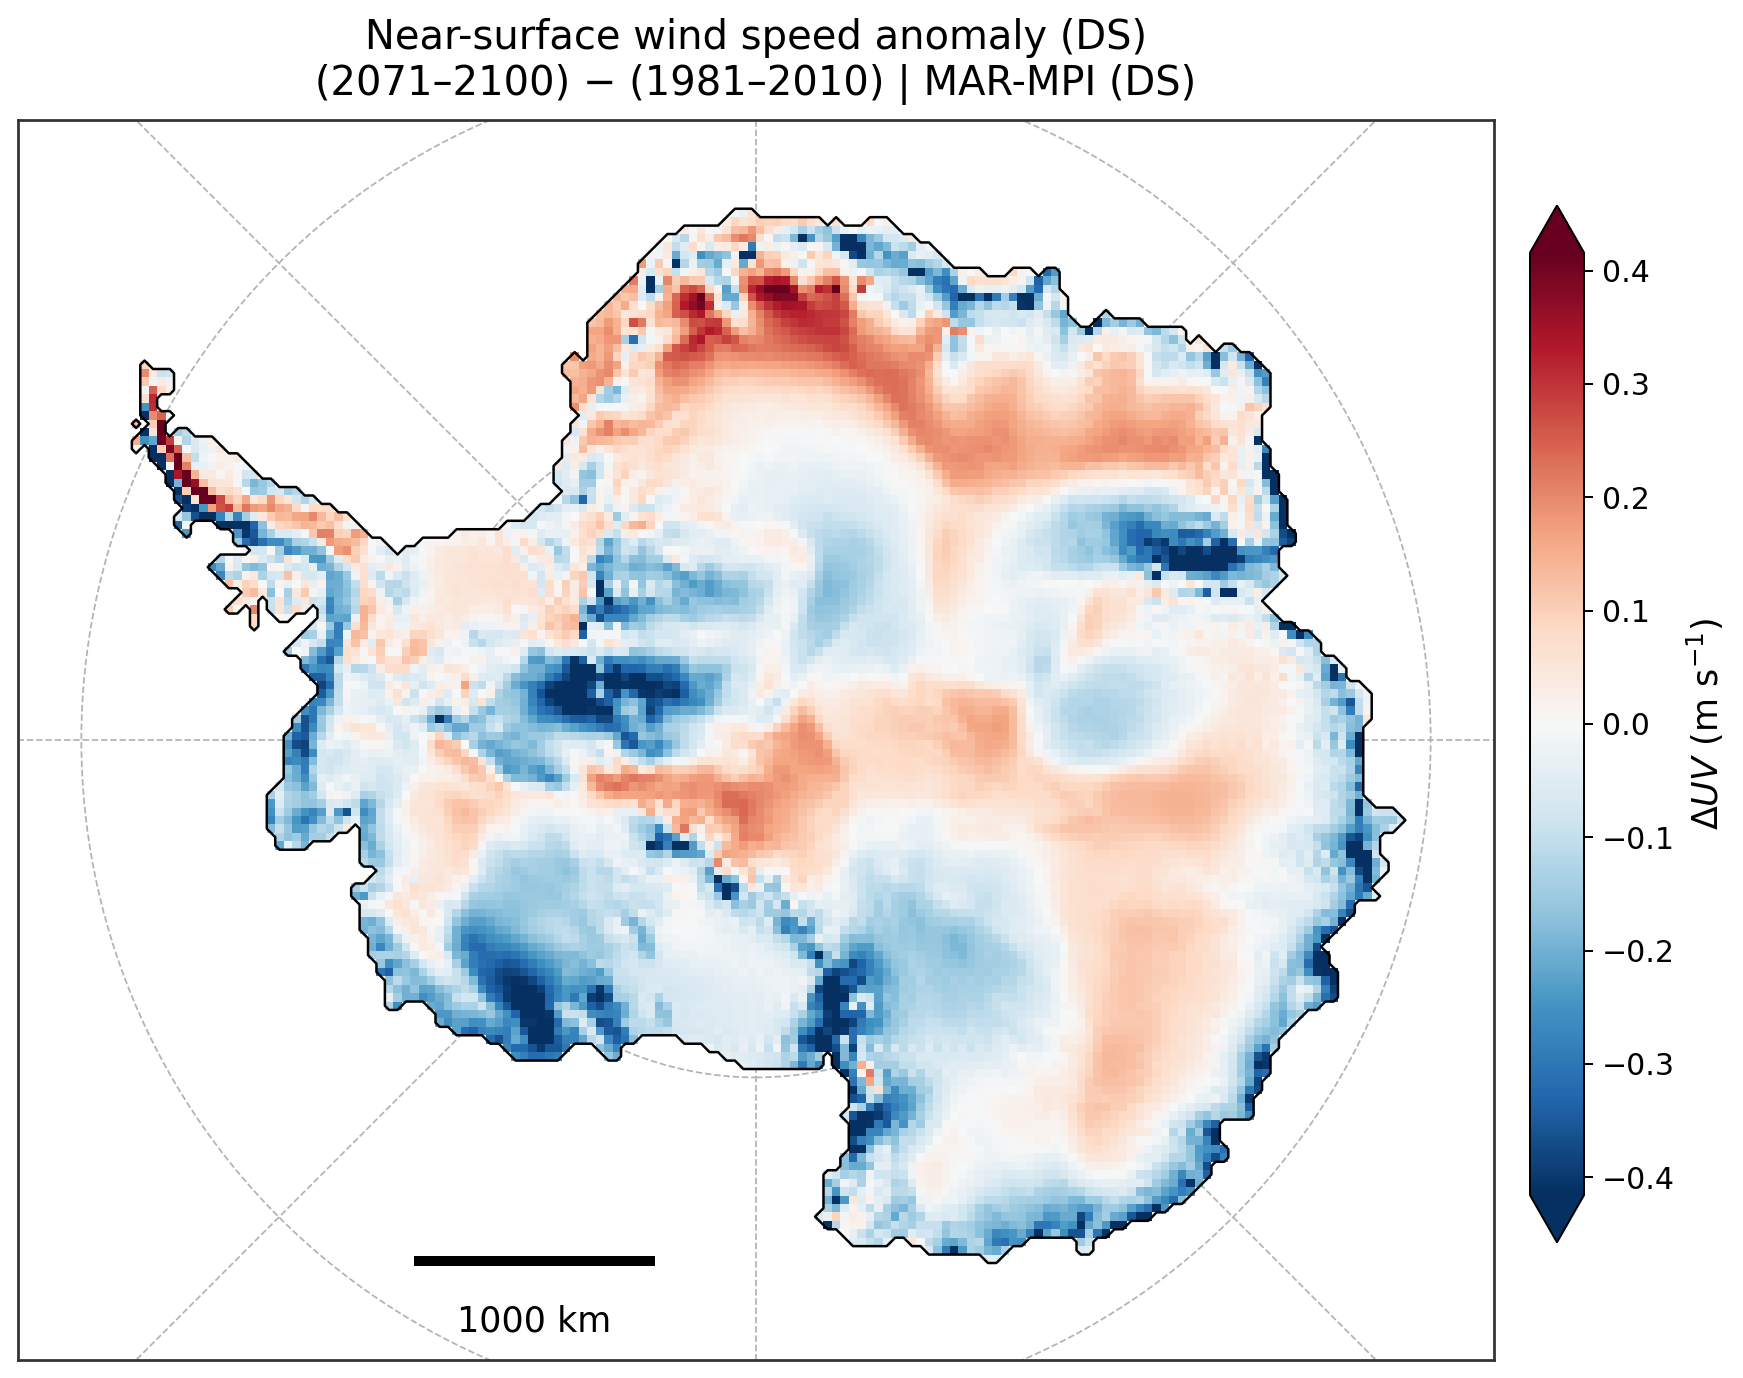

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# paths and periods
BASE_Y0, BASE_Y1 = 1981, 2010
FUT_Y0,  FUT_Y1  = 2071, 2100

# wind, density and threshold-velocity files
BASE_DIR = "/Users/dashakan/Desktop/scripts_AIS/winddensity/"
FILE_TMPL = "year-UV-RHO-USTH-MAR-DS_{MODEL}-1980-2100.nc"

# choose model here:
MODEL = "MPI"   # options: "CNRM", "IPSL", "MPI", "UKM"

MODEL_TITLES = {
    "IPSL": "MAR-IPSL (DS)",
    "UKM":  "MAR-UKESM (DS)",
    "MPI":  "MAR-MPI (DS)",
    "CNRM": "MAR-CNRM (DS)",
}

# plot styling
def _draw_polar_guides(ax, cx, cy, rmax):
    for frac in [0.35, 0.70, 1.00]:
        ax.add_patch(Circle((cx, cy), frac * rmax, fill=False,
                            ls="--", lw=0.7, ec="0.7", zorder=2))
    for ang in [0, 45, 90, 135]:
        t = np.deg2rad(ang)
        dx = np.array([-rmax, rmax]) * np.cos(t)
        dy = np.array([-rmax, rmax]) * np.sin(t)
        ax.plot(cx + dx, cy + dy, ls="--", lw=0.7, color="0.7", zorder=2)

def _add_scalebar_1000km(ax, xmin, xmax, ymin, ymax,
                         length=1000.0,  # X/Y are in km in shade grid
                         xfrac=0.35, yfrac=0.08):
    W, H = (xmax - xmin), (ymax - ymin)
    xc = xmin + xfrac * W
    x0, x1 = xc - 0.5 * length, xc + 0.5 * length
    y = ymin + yfrac * H
    ax.plot([x0, x1], [y, y], color="k", lw=4, solid_capstyle="butt", zorder=20)
    ax.text(xc, y - 0.035 * H, "1000 km", ha="center", va="top",
            fontsize=14, color="k", zorder=21)

def _mean_period_years(da, y0, y1):
    """Mean of yearly TIME coordinate (timestamps at Jan 1) between y0..y1 inclusive."""
    years = da["TIME"].dt.year
    return da.where((years >= y0) & (years <= y1), drop=True).mean("TIME", skipna=True)

# open the file and compute the anomaly
fn = BASE_DIR + FILE_TMPL.format(MODEL=MODEL)
ds = xr.open_dataset(fn, engine="netcdf4", decode_times=False)

# annual stamps, 1980-2100
dates = pd.date_range("1980-01-01", "2100-01-01", freq="AS")
ds["TIME"] = dates

# near-surface wind speed
# UV has an ATMLAY axis, take the near-surface one
UV = ds["UV"].sel(ATMLAY=0.99973, method="nearest")

# dims need to match the plotting grid (Y,X)
# the base cell uses uppercase X/Y, some files come with lowercase
if "x" in UV.dims and "X" not in UV.dims:
    UV = UV.rename({"x": "X"})
if "y" in UV.dims and "Y" not in UV.dims:
    UV = UV.rename({"y": "Y"})

# anomaly: 2071-2100 minus 1981-2010
base = _mean_period_years(UV, BASE_Y0, BASE_Y1).values
fut  = _mean_period_years(UV, FUT_Y0,  FUT_Y1 ).values
dUV  = fut - base

# mask with lsm from shade.ice_masking()
field = np.ma.array(dUV, mask=lsm)

# plot
X = x2D + dh
Y = y2D + dh

# symmetric colour limits from a percentile
v = field.compressed()
vmax = np.nanpercentile(np.abs(v), 98) if v.size else 1.0
if not np.isfinite(vmax) or vmax == 0:
    vmax = 1.0

xmin, xmax = float(np.nanmin(X)), float(np.nanmax(X))
ymin, ymax = float(np.nanmin(Y)), float(np.nanmax(Y))
cx, cy = 0.5 * (xmin + xmax), 0.5 * (ymin + ymax)
corners = np.array([[xmin, ymin], [xmin, ymax], [xmax, ymin], [xmax, ymax]], dtype=float)
rmax = float(np.max(np.sqrt((corners[:, 0] - cx) ** 2 + (corners[:, 1] - cy) ** 2)))

fig, ax = plt.subplots(1, 1, figsize=(10, 9), dpi=180)
plt.subplots_adjust(left=0.04, right=0.86, top=0.92, bottom=0.06)

_draw_polar_guides(ax, cx, cy, rmax)

im = ax.pcolormesh(X, Y, field, shading="auto",
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax, zorder=3)

# outline the mask edge
ax.contour(X, Y, (~lsm).astype(float), levels=[0.5], colors="k", linewidths=1.0, zorder=5)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_linewidth(1.1)
    sp.set_color("0.2")

_add_scalebar_1000km(ax, xmin, xmax, ymin, ymax)

ax.set_title(
    f"Near-surface wind speed anomaly (DS)\n({FUT_Y0}–{FUT_Y1}) − ({BASE_Y0}–{BASE_Y1}) | {MODEL_TITLES.get(MODEL, MODEL)}",
    fontsize=16, pad=10
)

cax = fig.add_axes([0.88, 0.18, 0.03, 0.64])
cb = fig.colorbar(im, cax=cax, extend="both")
cb.set_label(r"$\Delta UV$ (m s$^{-1}$)", fontsize=14)
cb.ax.tick_params(labelsize=12)

plt.show()

### Significance
Fisher-Snedecor first to choose between Student and Welch, then a two-sided permutation test on the mean difference as a check.

In [16]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, f as f_dist

BASE_Y0, BASE_Y1 = 1981, 2010
FUT_Y0,  FUT_Y1  = 2071, 2100

def _series_by_year(da):
    """xarray DataArray (TIME) -> pandas Series indexed by year."""
    s = da.to_series()
    s.index = pd.to_datetime(s.index).year
    return s.sort_index()

def _subset_years(da, y0, y1):
    s = _series_by_year(da)
    return s.loc[y0:y1].astype(float).values

def fisher_variance_test(x, y):
    x = np.asarray(x); y = np.asarray(y)
    x = x[~np.isnan(x)]; y = y[~np.isnan(y)]
    v1 = np.var(x, ddof=1); v2 = np.var(y, ddof=1)
    F = v1 / v2
    df1, df2 = len(x)-1, len(y)-1
    p = 2 * min(f_dist.cdf(F, df1, df2), 1 - f_dist.cdf(F, df1, df2))
    return F, p

def perm_test_mean_diff(x, y, n_perm=10000, seed=0):
    rng = np.random.default_rng(seed)
    x = np.asarray(x); y = np.asarray(y)
    x = x[~np.isnan(x)]; y = y[~np.isnan(y)]
    obs = np.mean(x) - np.mean(y)
    pooled = np.concatenate([x, y])
    n_x = len(x)
    diffs = np.empty(n_perm)
    for i in range(n_perm):
        rng.shuffle(pooled)
        diffs[i] = np.mean(pooled[:n_x]) - np.mean(pooled[n_x:])
    p = (np.sum(np.abs(diffs) >= np.abs(obs)) + 1) / (n_perm + 1)
    return obs, p

def run_tests(dic, reg, model, var, base=(BASE_Y0,BASE_Y1), fut=(FUT_Y0,FUT_Y1),
              do_fisher=True, n_perm=10000, seed=0):
    da = dic[reg][model][var]
    A = _subset_years(da, base[0], base[1])
    B = _subset_years(da, fut[0], fut[1])

    out = {
        "region": reg,
        "model": model,
        "var": var,
        "n_base": int(np.sum(~np.isnan(A))),
        "n_fut":  int(np.sum(~np.isnan(B))),
        "mean_base": float(np.nanmean(A)),
        "mean_fut":  float(np.nanmean(B)),
        "diff_fut_minus_base": float(np.nanmean(B) - np.nanmean(A)),
    }

    # Fisher decides between Student and Welch
    if do_fisher:
        F, pF = fisher_variance_test(A, B)
        out["F"] = float(F); out["p_fisher"] = float(pF)
        equal_var = (pF > 0.05)
    else:
        equal_var = False

    t, p = ttest_ind(A, B, equal_var=equal_var, nan_policy="omit")
    out["ttest"] = "Student" if equal_var else "Welch"
    out["t"] = float(t); out["p_ttest"] = float(p)

    # permutation test
    obs, pperm = perm_test_mean_diff(B, A, n_perm=n_perm, seed=seed)  # fut - base
    out["p_perm"] = float(pperm)

    return out

# run over every model, region and variable
vars_to_test = ["UV", "RO1", "UUSTH"]
models = ["UKM", "CM6", "MPI", "IPL"]      # adapt if you use CNRM/IPSL strings
regions = ["ice", "grd", "shelf"]

results = []
for reg in regions:
    for model in models:
        for var in vars_to_test:
            results.append(run_tests(dyn_mean, reg, model, var))

df_tests = pd.DataFrame(results)

# nicer view
df_tests.sort_values(["region","var","model"])[
    ["region","var","model","mean_base","mean_fut","diff_fut_minus_base","ttest","p_ttest","p_perm","p_fisher"]
]

,region,var,model,mean_base,mean_fut,diff_fut_minus_base,ttest,p_ttest,p_perm,p_fisher
16,grd,RO1,CM6,371.461880,373.751138,2.289258,Student,2.174140e-05,0.000200,9.328816e-02
22,grd,RO1,IPL,374.738512,377.325073,2.586561,Welch,4.283856e-07,0.000100,6.561423e-05
19,grd,RO1,MPI,370.346056,371.501112,1.155056,Student,6.366546e-04,0.000500,3.916292e-01
13,grd,RO1,UKM,369.170218,371.035933,1.865715,Student,1.299754e-05,0.000100,4.732189e-01
17,grd,UUSTH,CM6,0.463660,0.470773,0.007112,Student,1.352685e-05,0.000100,9.756155e-02
23,grd,UUSTH,IPL,0.473619,0.481588,0.007969,Welch,3.019279e-07,0.000100,7.058856e-05
20,grd,UUSTH,MPI,0.460369,0.463953,0.003584,Student,4.779761e-04,0.000400,3.720501e-01
14,grd,UUSTH,UKM,0.456789,0.462602,0.005812,Student,7.440880e-06,0.000100,4.635171e-01
15,grd,UV,CM6,6.753736,6.665258,-0.088478,Student,1.124895e-04,0.000300,2.211197e-01
21,grd,UV,IPL,6.874583,6.852445,-0.022138,Student,2.314268e-01,0.227577,4.285099e-01


### The same tests for near-surface temperature

TT sits in the main MAR output rather than the wind files, so it gets its own preprocessing before going through the same tests.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, f as f_dist

# paths and periods
BASE_Y0, BASE_Y1 = 1981, 2010
FUT_Y0,  FUT_Y1  = 2071, 2100

# main DS output, TT lives in these
BASE_DIR_MAIN = "/Users/dashakan/Desktop/scripts_AIS/"
FILE_TMPL_MAIN = "year-MAR-DS_{MODEL}-1980-2100.nc"


MODEL_FILE_TOKEN = {
    "UKM": "UKM",
    "CM6": "CNRM",
    "MPI": "MPI",
    "IPL": "IPL",   # filename uses IPL (not IPSL) 
}

regions = ["ice", "grd", "shelf"]
models  = ["UKM", "CM6", "MPI", "IPL"]

# preprocessing for TT
def preprocess_TT(ds):
    ds_new = ds
    # sector selection where the file has one
    for dim_name in ["SECTOR", "SECTOR1_1"]:
        if dim_name in ds_new.dims or dim_name in ds_new.coords:
            try:
                ds_new = ds_new.sel({dim_name: 1})
            except Exception:
                pass
    # near-surface temperature
    if "TT" in ds_new and "ATMLAY" in ds_new["TT"].dims:
        ds_new["TT"] = ds_new["TT"].sel(ATMLAY=0.99973, method="nearest")

    # rename dims to match the masks
    if "x" in ds_new.dims and "X" not in ds_new.dims:
        ds_new = ds_new.rename_dims({"x": "X"})
    if "y" in ds_new.dims and "Y" not in ds_new.dims:
        ds_new = ds_new.rename_dims({"y": "Y"})
    return ds_new

# same helpers as above
def _series_by_year(da):
    s = da.to_series()
    s.index = pd.to_datetime(s.index).year
    return s.sort_index()

def _subset_years(da, y0, y1):
    s = _series_by_year(da)
    return s.loc[y0:y1].astype(float).values

def fisher_variance_test(x, y):
    x = np.asarray(x); y = np.asarray(y)
    x = x[~np.isnan(x)]; y = y[~np.isnan(y)]
    v1 = np.var(x, ddof=1); v2 = np.var(y, ddof=1)
    F = v1 / v2
    df1, df2 = len(x)-1, len(y)-1
    p = 2 * min(f_dist.cdf(F, df1, df2), 1 - f_dist.cdf(F, df1, df2))
    return F, p

def perm_test_mean_diff(x, y, n_perm=10000, seed=0):
    rng = np.random.default_rng(seed)
    x = np.asarray(x); y = np.asarray(y)
    x = x[~np.isnan(x)]; y = y[~np.isnan(y)]
    obs = np.mean(x) - np.mean(y)
    pooled = np.concatenate([x, y])
    n_x = len(x)
    diffs = np.empty(n_perm)
    for i in range(n_perm):
        rng.shuffle(pooled)
        diffs[i] = np.mean(pooled[:n_x]) - np.mean(pooled[n_x:])
    p = (np.sum(np.abs(diffs) >= np.abs(obs)) + 1) / (n_perm + 1)
    return obs, p

def run_tests_on_da(da, reg, model, varname="TT",
                    base=(BASE_Y0,BASE_Y1), fut=(FUT_Y0,FUT_Y1),
                    do_fisher=True, n_perm=10000, seed=0):
    A = _subset_years(da, base[0], base[1])
    B = _subset_years(da, fut[0], fut[1])

    out = {
        "region": reg,
        "var": varname,
        "model": model,
        "mean_base": float(np.nanmean(A)),
        "mean_fut": float(np.nanmean(B)),
        "diff_fut_minus_base": float(np.nanmean(B) - np.nanmean(A)),
    }

    if do_fisher:
        F, pF = fisher_variance_test(A, B)
        equal_var = (pF > 0.05)
        out["p_fisher"] = float(pF)
    else:
        equal_var = False
        out["p_fisher"] = np.nan

    t, p = ttest_ind(A, B, equal_var=equal_var, nan_policy="omit")
    out["ttest"] = "Student" if equal_var else "Welch"
    out["p_ttest"] = float(p)

    _, pperm = perm_test_mean_diff(B, A, n_perm=n_perm, seed=seed)  # fut - base
    out["p_perm"] = float(pperm)

    return out

def spatial_mean_TT(ds, mask, y0=1980, y1=2100):
    # spatial_mean() comes from the base cell
    return spatial_mean(ds, "TT", mask, data_start=y0, data_end=y1)

# run
dates = pd.date_range("1980-01-01", "2100-01-01", freq="AS")

rows = []
for model in models:
    token = MODEL_FILE_TOKEN[model]
    fn = BASE_DIR_MAIN + FILE_TMPL_MAIN.format(MODEL=token)
    ds = xr.open_mfdataset(fn, decode_times=False, preprocess=preprocess_TT, engine="netcdf4")
    ds["TIME"] = dates

    
    TT_ice   = spatial_mean_TT(ds, ice_msk)
    TT_grd   = spatial_mean_TT(ds, grd_msk)
    TT_shelf = spatial_mean_TT(ds, shf_msk)

    rows.append(run_tests_on_da(TT_grd,   "grd",   model, "TT"))
    rows.append(run_tests_on_da(TT_ice,   "ice",   model, "TT"))
    rows.append(run_tests_on_da(TT_shelf, "shelf", model, "TT"))

df_TT = pd.DataFrame(rows)

df_TT = df_TT[["region","var","model","mean_base","mean_fut","diff_fut_minus_base","ttest","p_ttest","p_perm","p_fisher"]]
df_TT = df_TT.sort_values(["region","model"])

print(df_TT.to_string(index=False))

/var/folders/m4/s6gxk__51rnfsvq365qr6fx40000gn/T/ipykernel_6498/596000861.py:129: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  dates = pd.date_range("1980-01-01", "2100-01-01", freq="AS")


region var model  mean_base   mean_fut  diff_fut_minus_base   ttest      p_ttest  p_perm     p_fisher
   grd  TT   CM6 -35.167940 -30.503954             4.663986   Welch 3.881696e-23  0.0001 1.391678e-06
   grd  TT   IPL -34.424289 -30.115996             4.308294   Welch 2.367675e-26  0.0001 1.834540e-02
   grd  TT   MPI -33.772064 -30.859444             2.912620 Student 5.089142e-30  0.0001 6.494243e-01
   grd  TT   UKM -34.973760 -29.610502             5.363258   Welch 2.267098e-30  0.0001 5.347982e-03
   ice  TT   CM6 -34.264110 -29.327558             4.936551   Welch 1.744662e-23  0.0001 7.010223e-07
   ice  TT   IPL -33.596280 -29.119742             4.476538   Welch 1.662572e-26  0.0001 1.104826e-02
   ice  TT   MPI -32.868428 -29.880342             2.988086 Student 2.187627e-30  0.0001 5.429123e-01
   ice  TT   UKM -34.184760 -28.615331             5.569429   Welch 5.395940e-31  0.0001 6.939939e-03
 shelf  TT   CM6 -21.912918 -15.926034             5.986884   Welch 9.909236e-27  

### Significance table for the SMB components

Runs on `bs_dic`, the DS simulation, where the series are already in Gt/yr, so nothing is converted here. Set up for ME; the other variables are in the list, commented out.

In [ ]:
#
#

import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, f as f_dist

# periods
BASE_Y0, BASE_Y1 = 1981, 2010
FUT_Y0,  FUT_Y1  = 2071, 2100

# variables, DS run only
VARS = [
    "ME",   # melt
    # "SMB",
    # "SU",
    # "RU",
    # "ER",  # DS run only
    # "SF",
    # "RF",
]

# regions to include
REGIONS = ["ice", "grd", "shelf"]

# needed from the base cell:
# bs_dic (DS run), list_mod_names
DS_RUN = bs_dic

# helpers
def _as_year_indexed_series(da):
    """
    Convert a DataArray with TIME coordinate to a pandas Series indexed by YEAR (int).
    Works for TIME as datetime64 (recommended). If TIME already numeric years, also OK.
    """
    if not hasattr(da, "to_series"):
        raise TypeError(f"Expected xarray.DataArray-like, got {type(da)}")

    s = da.to_series()

    
    if isinstance(s.index, pd.MultiIndex):
        
        
        raise ValueError(f"Series index is MultiIndex (dims not reduced to 1D TIME): {da.dims}")

    idx = s.index

 
    if np.issubdtype(idx.dtype, np.datetime64):
        years = pd.to_datetime(idx).year.astype(int)
    else:
        
        try:
            years = pd.Index(idx).astype(int).values
        except Exception:
            years = pd.to_datetime(idx).year.astype(int)

    s.index = years
    s = s.sort_index()
    return s

def _subset_years(da, y0, y1):
    s = _as_year_indexed_series(da)
    out = s.loc[int(y0):int(y1)].astype(float).values
    out = out[np.isfinite(out)]
    return out

def fisher_variance_test(x, y):
    """Two-sided Fisher-Snedecor p-value for equality of variances."""
    x = np.asarray(x); y = np.asarray(y)
    x = x[np.isfinite(x)]; y = y[np.isfinite(y)]
    if len(x) < 3 or len(y) < 3:
        return np.nan
    v1 = np.var(x, ddof=1); v2 = np.var(y, ddof=1)
    if v1 == 0 and v2 == 0:
        return 1.0
    if v2 == 0:
        return 0.0
    F = v1 / v2
    df1, df2 = len(x) - 1, len(y) - 1
    p = 2 * min(f_dist.cdf(F, df1, df2), 1 - f_dist.cdf(F, df1, df2))
    return float(p)

def permutation_pvalue_mean_diff(x, y, n_perm=10000, seed=0):
    """
    Two-sided permutation test for mean(x)-mean(y).
    Here x=future, y=base if you want p-value for future-minus-base.
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(x); y = np.asarray(y)
    x = x[np.isfinite(x)]; y = y[np.isfinite(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan

    obs = np.mean(x) - np.mean(y)
    pooled = np.concatenate([x, y])
    nx = len(x)

    diffs = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        rng.shuffle(pooled)
        diffs[i] = np.mean(pooled[:nx]) - np.mean(pooled[nx:])

    p = (np.sum(np.abs(diffs) >= np.abs(obs)) + 1) / (n_perm + 1)
    return float(p)


rows = []

for reg in REGIONS:
    for mod in list_mod_names:
        container = DS_RUN[reg][mod]  

        for var in VARS:
            if var not in container:
                continue

            da = container[var]  
            A = _subset_years(da, BASE_Y0, BASE_Y1)  
            B = _subset_years(da, FUT_Y0,  FUT_Y1)   

            if len(A) < 3 or len(B) < 3:
                rows.append({
                    "region": reg, "var": var, "model": mod, "unit": "Gt/yr",
                    "mean_base": np.nan, "mean_fut": np.nan, "diff_fut_minus_base": np.nan,
                    "ttest": "", "p_ttest": np.nan, "p_perm": np.nan, "p_fisher": np.nan
                })
                continue

            pF = fisher_variance_test(A, B)
            equal_var = (pF > 0.05) if np.isfinite(pF) else False

            # Student or Welch
            tstat, p_t = ttest_ind(A, B, equal_var=equal_var, nan_policy="omit")

            # Permutation test for (future - base)
            p_perm = permutation_pvalue_mean_diff(B, A, n_perm=10000, seed=0)

            rows.append({
                "region": reg,
                "var": var,
                "model": mod,
                "unit": "Gt/yr",
                "mean_base": float(np.mean(A)),
                "mean_fut": float(np.mean(B)),
                "diff_fut_minus_base": float(np.mean(B) - np.mean(A)),
                "ttest": "Student" if equal_var else "Welch",
                "p_ttest": float(p_t),
                "p_perm": float(p_perm),
                "p_fisher": float(pF),
            })

df = pd.DataFrame(rows)
df = df.sort_values(["region", "var", "model"]).reset_index(drop=True)

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
display(df)

,region,var,model,unit,mean_base,mean_fut,diff_fut_minus_base,ttest,p_ttest,p_perm,p_fisher
0,grd,ME,CM6,Gt/yr,39.053846,402.466866,363.413020,Welch,7.230612e-12,0.0001,5.514353e-26
1,grd,ME,IPL,Gt/yr,55.107190,330.632886,275.525697,Welch,1.141410e-13,0.0001,9.381490e-14
2,grd,ME,MPI,Gt/yr,52.842799,170.881089,118.038290,Welch,6.857485e-13,0.0001,1.062716e-09
3,grd,ME,UKM,Gt/yr,29.363817,318.849709,289.485892,Welch,7.372695e-13,0.0001,6.921841e-22
4,ice,ME,CM6,Gt/yr,129.057644,1162.769021,1033.711378,Welch,7.282265e-14,0.0001,1.188046e-23
5,ice,ME,IPL,Gt/yr,181.619008,921.874133,740.255124,Welch,3.903085e-15,0.0001,8.541712e-12
6,ice,ME,MPI,Gt/yr,170.317245,492.288322,321.971077,Welch,1.913677e-15,0.0001,3.755025e-08
7,ice,ME,UKM,Gt/yr,99.333435,882.766809,783.433373,Welch,4.433525e-15,0.0001,9.376372e-19
8,shelf,ME,CM6,Gt/yr,98.656807,786.747631,688.090824,Welch,1.763920e-15,0.0001,9.857909e-22
9,shelf,ME,IPL,Gt/yr,139.012266,616.454037,477.441771,Welch,1.400436e-16,0.0001,2.235624e-10


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import ttest_ind, f as f_dist


BASE = (1981, 2010)
FUT  = (2071, 2100)


def preprocess_uv_rho_usth(ds):
    
    ds_new = ds

    
    for dim_name in ["SECTOR", "SECTOR1_1"]:
        if (dim_name in ds_new.dims) or (dim_name in ds_new.coords):
            try:
                ds_new = ds_new.sel({dim_name: 1})
            except Exception:
                pass

    
    if "UV" in ds_new and "ATMLAY" in ds_new["UV"].dims:
        try:
            ds_new["UV"] = ds_new["UV"].sel(ATMLAY=0.99973)
        except Exception:
            pass

    
    if ("OUTLAY" in ds_new.dims) or ("OUTLAY" in ds_new.coords):
        try:
            ds_new = ds_new.sel(OUTLAY="0")
        except Exception:
            try:
                ds_new = ds_new.sel(OUTLAY=0)
            except Exception:
                pass

    
    if "x" in ds_new.dims and "X" not in ds_new.dims:
        ds_new = ds_new.rename_dims({"x": "X"})
    if "y" in ds_new.dims and "Y" not in ds_new.dims:
        ds_new = ds_new.rename_dims({"y": "Y"})

    return ds_new


dates = pd.date_range("1980-01-01", "2100-01-01", freq="YS") 


base = "/Users/dashakan/Desktop/scripts_AIS/winddensity/"
paths = {
    "UKM":  base + "year-UV-RHO-USTH-MAR-DS_UKM-1980-2100.nc",
    "CM6":  base + "year-UV-RHO-USTH-MAR-DS_CNRM-1980-2100.nc",
    "MPI":  base + "year-UV-RHO-USTH-MAR-DS_MPI-1980-2100.nc",
    "IPL":  base + "year-UV-RHO-USTH-MAR-DS_IPSL-1980-2100.nc",
}


dyn_ds = {}
for name, p in paths.items():
    ds = xr.open_mfdataset(
        p,
        decode_times=False,
        preprocess=preprocess_uv_rho_usth,
        engine="netcdf4",
        combine="by_coords",
    )
    ds = ds.assign_coords(TIME=("TIME", dates))
    dyn_ds[name] = ds

models = list(dyn_ds.keys())
vars_to_test = ["UV", "RO1", "UUSTH"]


def align_mask_to_da(mask, da):
   
    m = mask
    
    rename = {}
    if "x" in m.dims and "X" in da.dims: rename["x"] = "X"
    if "y" in m.dims and "Y" in da.dims: rename["y"] = "Y"
    if rename:
        m = m.rename(rename)
    
    spatial = [d for d in ["Y", "X"] if d in da.dims]
    m = m.transpose(*spatial)
    
    try:
        m, _ = xr.align(m, da.isel(TIME=0, drop=True), join="inner")
    except Exception:
        pass
    return m


def split_periods(da, base=BASE, fut=FUT):
    years = da["TIME"].dt.year
    A = da.where((years >= base[0]) & (years <= base[1]), drop=True)
    B = da.where((years >= fut[0])  & (years <= fut[1]),  drop=True)
    return A, B


def _fisher_pvalue_1d(a, b):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if (a.size < 2) or (b.size < 2):
        return np.nan
    v1 = np.var(a, ddof=1)
    v2 = np.var(b, ddof=1)
    if (v1 <= 0) or (v2 <= 0):
        return np.nan
    F = v1 / v2
    df1, df2 = a.size - 1, b.size - 1
    cdf = f_dist.cdf(F, df1, df2)
    return 2 * min(cdf, 1 - cdf)

def _ttest_pvalue_1d(a, b, equal_var):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if (a.size < 2) or (b.size < 2):
        return np.nan
    _, p = ttest_ind(a, b, equal_var=equal_var)
    return p


def pixel_tests_t_and_fisher(da, base=BASE, fut=FUT):
    
    A, B = split_periods(da, base=base, fut=fut)

    
    p_fisher = xr.apply_ufunc(
        _fisher_pvalue_1d,
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        join="override",
    )

    equal_var = (p_fisher > 0.05).fillna(False)

    p_student = xr.apply_ufunc(
        lambda a, b: _ttest_pvalue_1d(a, b, True),
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        join="override",
    )

    p_welch = xr.apply_ufunc(
        lambda a, b: _ttest_pvalue_1d(a, b, False),
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        join="override",
    )

    p_ttest = xr.where(equal_var, p_student, p_welch)
    diff = B.mean("TIME") - A.mean("TIME")

    return xr.Dataset(
        {
            "diff_fut_minus_base": diff,
            "p_fisher": p_fisher,
            "p_ttest": p_ttest,
            "equal_var": equal_var.astype(np.int8),
        }
    )


for m in models:
    ds = dyn_ds[m]
    chunk_map = {}
    if "Y" in ds.dims: chunk_map["Y"] = 200
    if "X" in ds.dims: chunk_map["X"] = 200
    if chunk_map:
        dyn_ds[m] = ds.chunk({**chunk_map, "TIME": -1})


masks = {"ice": ice_msk, "grd": grd_msk, "shelf": shf_msk}

pixel_results = {reg: {m: {} for m in models} for reg in masks.keys()}

for reg, msk in masks.items():
    for model in models:
        for var in vars_to_test:
            da = dyn_ds[model][var]
            msk_aligned = align_mask_to_da(msk, da)
            da_reg = da.where(msk_aligned)
            pixel_results[reg][model][var] = pixel_tests_t_and_fisher(da_reg)

pixel_results["ice"]["UKM"]["UV"]["p_ttest"]  # (Y,X) p-values map
pixel_results["ice"]["UKM"]["UV"]["diff_fut_minus_base"] # anomaly map

<xarray.DataArray 'diff_fut_minus_base' (Y: 148, X: 3)> Size: 2kB
dask.array<sub, shape=(148, 3), dtype=float32, chunksize=(148, 3), chunktype=numpy.ndarray>
Coordinates:
  * Y        (Y) float32 592B -2.555e+03 -2.52e+03 ... 2.555e+03 2.59e+03
  * X        (X) float32 12B 35.0 70.0 140.0
    OUTLAY   float32 4B 0.0
    SECTOR   float32 4B 1.0
Attributes:
    long_name:     Wind Speed
    units:         m/s
    cell_methods:  TIME: mean
    history:       From ICE.k77.1980.01.01-10

### UV anomaly map with significance

Absolute change

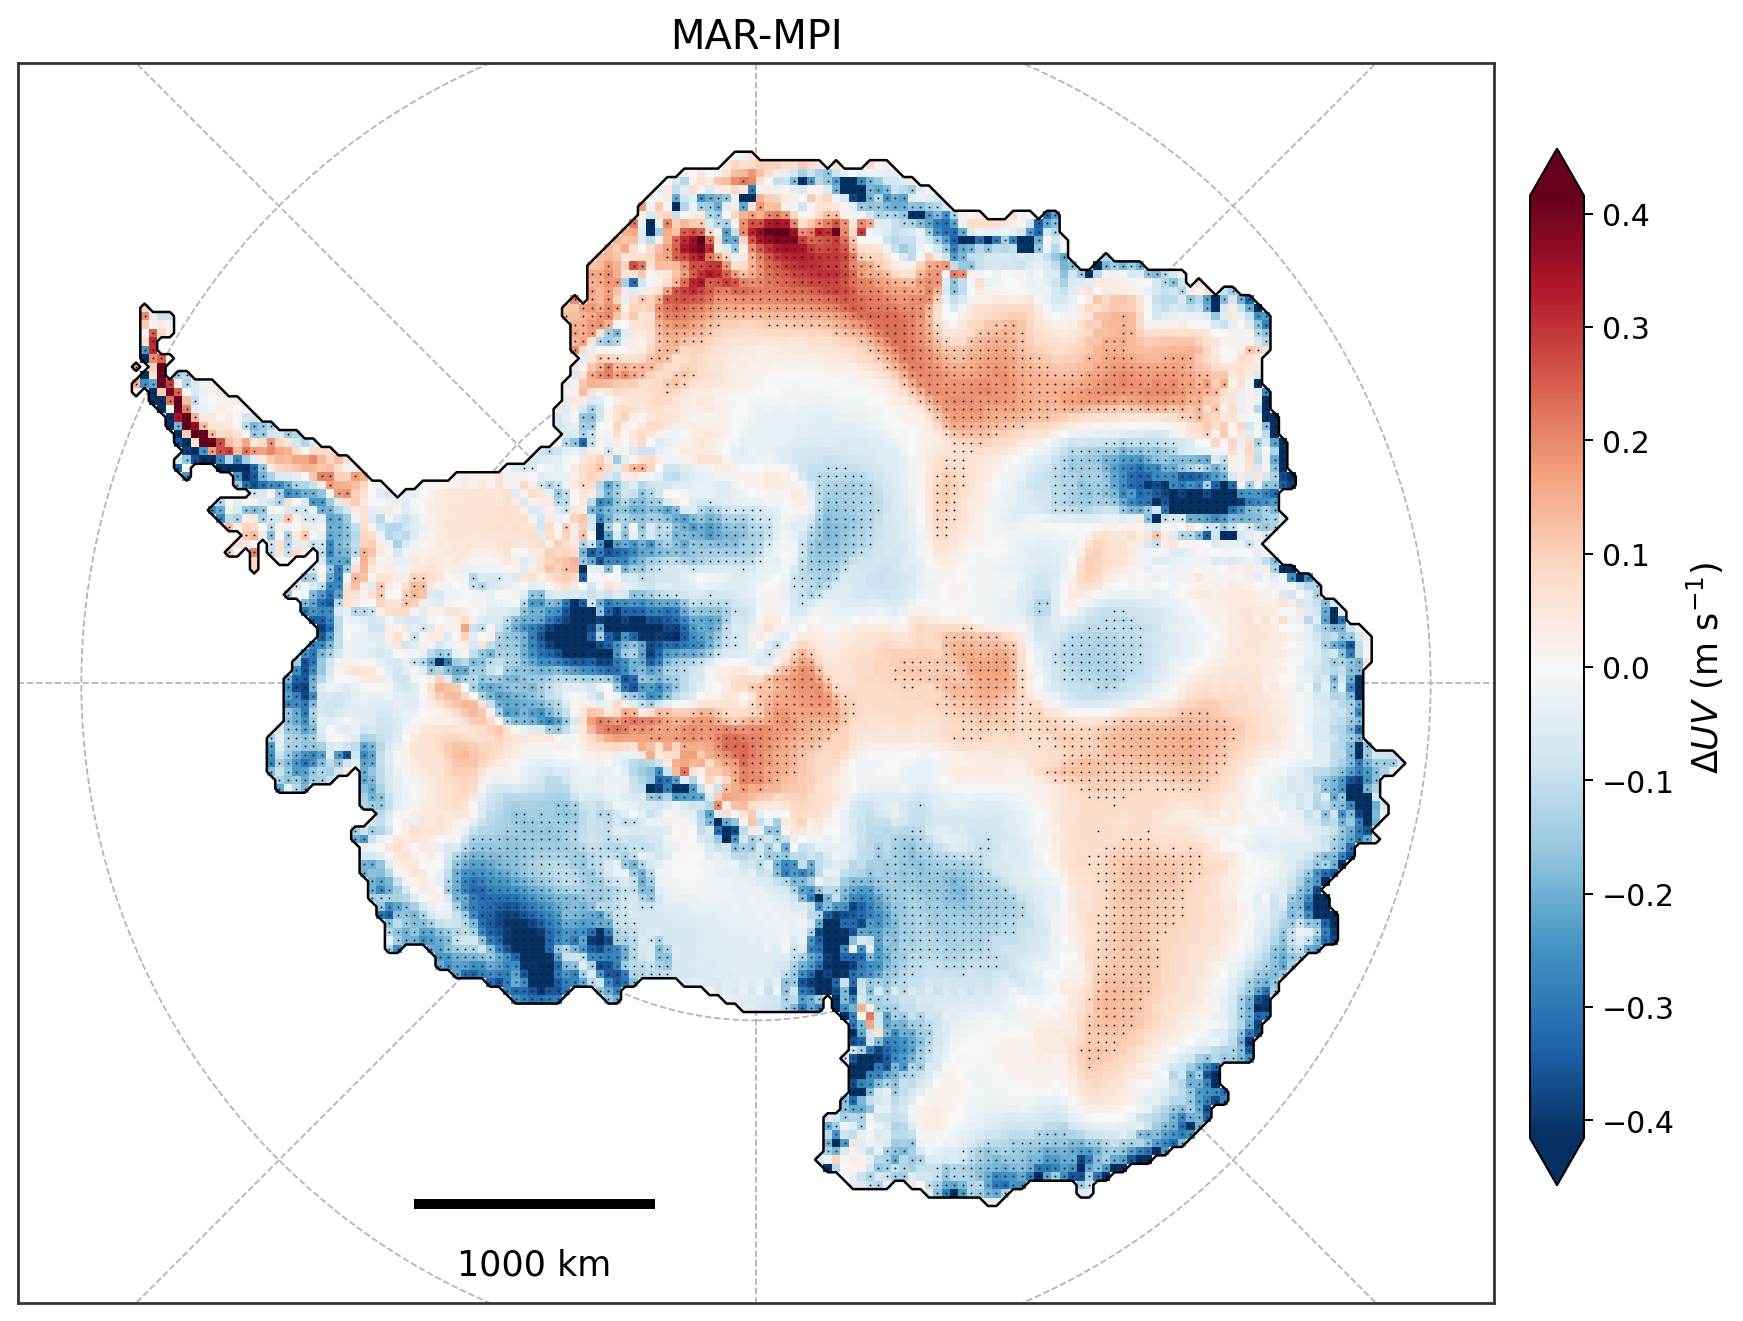

In [ ]:
import numpy as np
import numpy.ma as ma
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import ttest_ind, f as f_dist


BASE_Y0, BASE_Y1 = 1981, 2010
FUT_Y0,  FUT_Y1  = 2071, 2100
ALPHA = 0.05

BASE_DIR = "/Users/dashakan/Desktop/scripts_AIS/winddensity/"
FILE_TMPL = "year-UV-RHO-USTH-MAR-DS_{MODEL}-1980-2100.nc"
MODEL = "MPI"  # "CNRM", "IPSL", "MPI", "UKM"

MODEL_TITLES = {
    "IPSL": "MAR-IPSL (DS)",
    "UKM":  "MAR-UKESM (DS)",
    "MPI":  "MAR-MPI (DS)",
    "CNRM": "MAR-CNRM (DS)",
}


def _draw_polar_guides(ax, cx, cy, rmax):
    for frac in [0.35, 0.70, 1.00]:
        ax.add_patch(Circle((cx, cy), frac * rmax, fill=False,
                            ls="--", lw=0.7, ec="0.7", zorder=2))
    for ang in [0, 45, 90, 135]:
        t = np.deg2rad(ang)
        dx = np.array([-rmax, rmax]) * np.cos(t)
        dy = np.array([-rmax, rmax]) * np.sin(t)
        ax.plot(cx + dx, cy + dy, ls="--", lw=0.7, color="0.7", zorder=2)

def _add_scalebar_1000km(ax, xmin, xmax, ymin, ymax,
                         length=1000.0, xfrac=0.35, yfrac=0.08):
    W, H = (xmax - xmin), (ymax - ymin)
    xc = xmin + xfrac * W
    x0, x1 = xc - 0.5 * length, xc + 0.5 * length
    y = ymin + yfrac * H
    ax.plot([x0, x1], [y, y], color="k", lw=4, solid_capstyle="butt", zorder=20)
    ax.text(xc, y - 0.035 * H, "1000 km", ha="center", va="top",
            fontsize=14, color="k", zorder=21)


def _subset_years(da, y0, y1):
    years = da["TIME"].dt.year
    return da.where((years >= y0) & (years <= y1), drop=True)


def _fisher_pvalue_1d(a, b):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if (a.size < 2) or (b.size < 2):
        return np.nan
    v1 = np.var(a, ddof=1)
    v2 = np.var(b, ddof=1)
    if (v1 <= 0) or (v2 <= 0):
        return np.nan
    F = v1 / v2
    df1, df2 = a.size - 1, b.size - 1
    cdf = f_dist.cdf(F, df1, df2)
    return 2 * min(cdf, 1 - cdf)

def _ttest_pvalue_1d(a, b, equal_var):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if (a.size < 2) or (b.size < 2):
        return np.nan
    _, p = ttest_ind(a, b, equal_var=equal_var)
    return p

def pixel_diff_and_sig(da, base=(BASE_Y0, BASE_Y1), fut=(FUT_Y0, FUT_Y1), alpha=ALPHA):
    """
    da: DataArray(TIME,Y,X)
    returns:
      diff (Y,X) mean(fut)-mean(base)
      p_ttest (Y,X) Student if Fisher p>0.05 else Welch
      sig (Y,X) boolean
    """
    A = _subset_years(da, base[0], base[1])
    B = _subset_years(da, fut[0], fut[1])

    p_fisher = xr.apply_ufunc(
        _fisher_pvalue_1d,
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        join="override",   
    )
    equal_var = (p_fisher > 0.05).fillna(False)

    p_student = xr.apply_ufunc(
        lambda a, b: _ttest_pvalue_1d(a, b, True),
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        join="override",
    )
    p_welch = xr.apply_ufunc(
        lambda a, b: _ttest_pvalue_1d(a, b, False),
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        join="override",
    )

    p_ttest = xr.where(equal_var, p_student, p_welch)
    diff = B.mean("TIME", skipna=True) - A.mean("TIME", skipna=True)
    sig = (p_ttest < alpha)
    return diff, p_ttest, sig


fn = BASE_DIR + FILE_TMPL.format(MODEL=MODEL)
ds = xr.open_dataset(fn, engine="netcdf4", decode_times=False)

dates = pd.date_range("1980-01-01", "2100-01-01", freq="YS")
ds = ds.assign_coords(TIME=("TIME", dates))

UV = ds["UV"].sel(ATMLAY=0.99973, method="nearest")


if "x" in UV.dims and "X" not in UV.dims:
    UV = UV.rename({"x": "X"})
if "y" in UV.dims and "Y" not in UV.dims:
    UV = UV.rename({"y": "Y"})


X_full = x2D[0, :]  
Y_full = y2D[:, 0]   
lsm_da_full = xr.DataArray(lsm, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})
X_da_full   = xr.DataArray(x2D + dh, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})
Y_da_full   = xr.DataArray(y2D + dh, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})
Xuv = UV["X"].values
lsm_use = lsm_da_full.sel(X=Xuv, method="nearest").values
Xplot   = X_da_full.sel(X=Xuv, method="nearest").values
Yplot   = Y_da_full.sel(X=Xuv, method="nearest").values
if ("Y" in UV.coords) and (UV.sizes.get("Y", None) == lsm_use.shape[0]):
    pass
elif ("Y" in UV.coords) and (UV.sizes.get("Y", None) != lsm_use.shape[0]):
    Yuv = UV["Y"].values
    lsm_use = xr.DataArray(lsm_use, dims=("Y", "X"), coords={"Y": Y_full, "X": Xuv}).sel(Y=Yuv, method="nearest").values
    Xplot   = xr.DataArray(Xplot,   dims=("Y", "X"), coords={"Y": Y_full, "X": Xuv}).sel(Y=Yuv, method="nearest").values
    Yplot   = xr.DataArray(Yplot,   dims=("Y", "X"), coords={"Y": Y_full, "X": Xuv}).sel(Y=Yuv, method="nearest").values
UVm = UV.where(~xr.DataArray(lsm_use, dims=("Y", "X"), coords={"Y": UV["Y"].values, "X": UV["X"].values}))

diff_da, p_da, sig_da = pixel_diff_and_sig(UVm)

dUV = diff_da.values
sig = sig_da.values

field = ma.array(dUV, mask=lsm_use)


v = field.compressed()
vmax = np.nanpercentile(np.abs(v), 98) if v.size else 1.0
if not np.isfinite(vmax) or vmax == 0:
    vmax = 1.0

xmin, xmax = float(np.nanmin(Xplot)), float(np.nanmax(Xplot))
ymin, ymax = float(np.nanmin(Yplot)), float(np.nanmax(Yplot))
cx, cy = 0.5 * (xmin + xmax), 0.5 * (ymin + ymax)
corners = np.array([[xmin, ymin], [xmin, ymax], [xmax, ymin], [xmax, ymax]], dtype=float)
rmax = float(np.max(np.sqrt((corners[:, 0] - cx) ** 2 + (corners[:, 1] - cy) ** 2)))

fig, ax = plt.subplots(1, 1, figsize=(10, 9), dpi=180)
plt.subplots_adjust(left=0.04, right=0.86, top=0.92, bottom=0.06)

_draw_polar_guides(ax, cx, cy, rmax)

im = ax.pcolormesh(Xplot, Yplot, field, shading="auto",
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax, zorder=3)


ax.contour(Xplot, Yplot, (~lsm_use).astype(float), levels=[0.5],
           colors="k", linewidths=1.0, zorder=5)

sig_show = sig & (~lsm_use) & np.isfinite(dUV)
iy, ix = np.where(sig_show)
ax.scatter(Xplot[iy, ix], Yplot[iy, ix], s=2, c="k", marker=".", linewidths=0, zorder=10)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_linewidth(1.1)
    sp.set_color("0.2")

_add_scalebar_1000km(ax, xmin, xmax, ymin, ymax)

ax.set_title(f"MAR-{MODEL}", fontsize=16)

cax = fig.add_axes([0.88, 0.18, 0.03, 0.64])
cb = fig.colorbar(im, cax=cax, extend="both")
cb.set_label(r"$\Delta UV$ (m s$^{-1}$)", fontsize=14)
cb.ax.tick_params(labelsize=12)

plt.show()

### The same map as relative change

100 x (future - reference) / reference. 

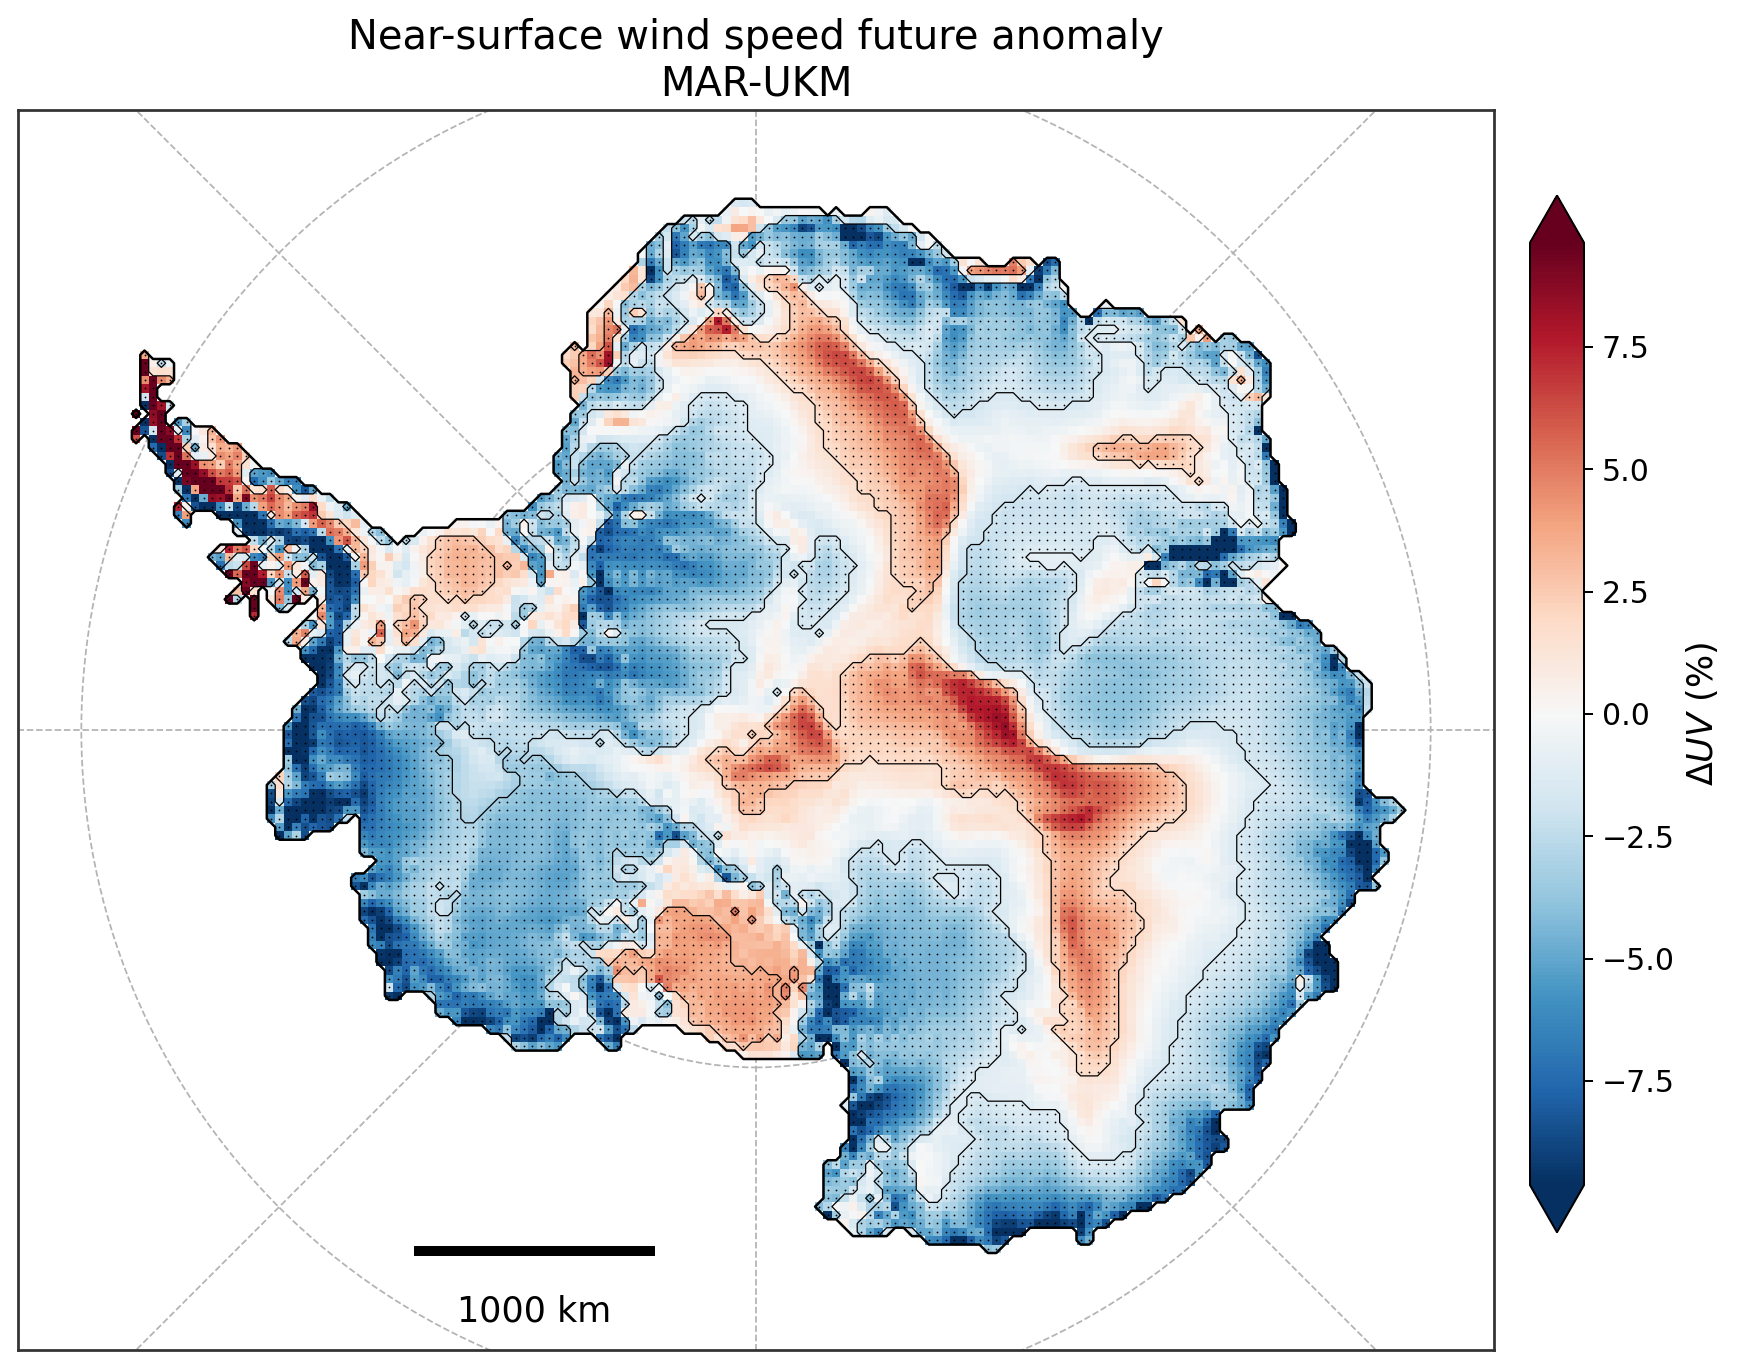

In [ ]:
import numpy as np
import numpy.ma as ma
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import ttest_ind, f as f_dist


BASE_Y0, BASE_Y1 = 1981, 2010
FUT_Y0,  FUT_Y1  = 2071, 2100
ALPHA = 0.05

BASE_DIR = "/Users/dashakan/Desktop/scripts_AIS/winddensity/"
FILE_TMPL = "year-UV-RHO-USTH-MAR-DS_{MODEL}-1980-2100.nc"
MODEL = "UKM"  # "CNRM", "IPSL", "MPI", "UKM"


def _draw_polar_guides(ax, cx, cy, rmax):
    for frac in [0.35, 0.70, 1.00]:
        ax.add_patch(Circle((cx, cy), frac * rmax, fill=False,
                            ls="--", lw=0.7, ec="0.7", zorder=2))
    for ang in [0, 45, 90, 135]:
        t = np.deg2rad(ang)
        dx = np.array([-rmax, rmax]) * np.cos(t)
        dy = np.array([-rmax, rmax]) * np.sin(t)
        ax.plot(cx + dx, cy + dy, ls="--", lw=0.7, color="0.7", zorder=2)

def _add_scalebar_1000km(ax, xmin, xmax, ymin, ymax,
                         length=1000.0, xfrac=0.35, yfrac=0.08):
    W, H = (xmax - xmin), (ymax - ymin)
    xc = xmin + xfrac * W
    x0, x1 = xc - 0.5 * length, xc + 0.5 * length
    y = ymin + yfrac * H
    ax.plot([x0, x1], [y, y], color="k", lw=4, solid_capstyle="butt", zorder=20)
    ax.text(xc, y - 0.035 * H, "1000 km", ha="center", va="top",
            fontsize=14, color="k", zorder=21)

# time axis
def _subset_years(da, y0, y1):
    years = da["TIME"].dt.year
    return da.where((years >= y0) & (years <= y1), drop=True)

# per-pixel tests, NaN-safe
def _fisher_pvalue_1d(a, b):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if (a.size < 2) or (b.size < 2):
        return np.nan
    v1 = np.var(a, ddof=1)
    v2 = np.var(b, ddof=1)
    if (v1 <= 0) or (v2 <= 0):
        return np.nan
    F = v1 / v2
    df1, df2 = a.size - 1, b.size - 1
    cdf = f_dist.cdf(F, df1, df2)
    return 2 * min(cdf, 1 - cdf)

def _ttest_pvalue_1d(a, b, equal_var):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if (a.size < 2) or (b.size < 2):
        return np.nan
    _, p = ttest_ind(a, b, equal_var=equal_var)
    return p

def pixel_pvals_student_or_welch(da, base=(BASE_Y0, BASE_Y1), fut=(FUT_Y0, FUT_Y1), alpha=ALPHA):
    """
    da: DataArray(TIME,Y,X)
    returns:
      p_ttest (Y,X) Student if Fisher p>0.05 else Welch
      sig (Y,X) boolean
    """
    A = _subset_years(da, base[0], base[1])
    B = _subset_years(da, fut[0], fut[1])

    p_fisher = xr.apply_ufunc(
        _fisher_pvalue_1d,
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        join="override",   
    )
    equal_var = (p_fisher > 0.05).fillna(False)

    p_student = xr.apply_ufunc(
        lambda a, b: _ttest_pvalue_1d(a, b, True),
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        join="override",
    )
    p_welch = xr.apply_ufunc(
        lambda a, b: _ttest_pvalue_1d(a, b, False),
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        join="override",
    )

    p_ttest = xr.where(equal_var, p_student, p_welch)
    sig = (p_ttest < alpha)
    return p_ttest, sig


fn = BASE_DIR + FILE_TMPL.format(MODEL=MODEL)
ds = xr.open_dataset(fn, engine="netcdf4", decode_times=False)

dates = pd.date_range("1980-01-01", "2100-01-01", freq="YS")
ds = ds.assign_coords(TIME=("TIME", dates))

UV = ds["UV"].sel(ATMLAY=0.99973, method="nearest")


if "x" in UV.dims and "X" not in UV.dims:
    UV = UV.rename({"x": "X"})
if "y" in UV.dims and "Y" not in UV.dims:
    UV = UV.rename({"y": "Y"})

X_full = x2D[0, :]  
Y_full = y2D[:, 0] 

lsm_da_full = xr.DataArray(lsm, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})
X_da_full   = xr.DataArray(x2D + dh, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})
Y_da_full   = xr.DataArray(y2D + dh, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})

Xuv = UV["X"].values
lsm_use = lsm_da_full.sel(X=Xuv, method="nearest").values
Xplot   = X_da_full.sel(X=Xuv, method="nearest").values
Yplot   = Y_da_full.sel(X=Xuv, method="nearest").values


if "Y" in UV.coords and UV.sizes.get("Y", None) != lsm_use.shape[0]:
    Yuv = UV["Y"].values
    lsm_use = xr.DataArray(lsm_use, dims=("Y", "X"), coords={"Y": Y_full, "X": Xuv}).sel(Y=Yuv, method="nearest").values
    Xplot   = xr.DataArray(Xplot,   dims=("Y", "X"), coords={"Y": Y_full, "X": Xuv}).sel(Y=Yuv, method="nearest").values
    Yplot   = xr.DataArray(Yplot,   dims=("Y", "X"), coords={"Y": Y_full, "X": Xuv}).sel(Y=Yuv, method="nearest").values


UVm = UV.where(~xr.DataArray(lsm_use, dims=("Y", "X"),
                            coords={"Y": UV["Y"].values, "X": UV["X"].values}))

# relative change, %
A = _subset_years(UVm, BASE_Y0, BASE_Y1)
B = _subset_years(UVm, FUT_Y0,  FUT_Y1)

base_mean = A.mean("TIME", skipna=True)
fut_mean  = B.mean("TIME", skipna=True)


eps = 1e-12
rel_da = 100.0 * (fut_mean - base_mean) / xr.where(np.abs(base_mean) > eps, base_mean, np.nan)

# the t-test run
p_da, sig_da = pixel_pvals_student_or_welch(UVm)

rel = rel_da.values
sig = sig_da.values

field = ma.array(rel, mask=lsm_use)

v = field.compressed()
vmax = np.nanpercentile(np.abs(v), 98) if v.size else 10.0
if not np.isfinite(vmax) or vmax == 0:
    vmax = 10.0

xmin, xmax = float(np.nanmin(Xplot)), float(np.nanmax(Xplot))
ymin, ymax = float(np.nanmin(Yplot)), float(np.nanmax(Yplot))
cx, cy = 0.5 * (xmin + xmax), 0.5 * (ymin + ymax)
corners = np.array([[xmin, ymin], [xmin, ymax], [xmax, ymin], [xmax, ymax]], dtype=float)
rmax = float(np.max(np.sqrt((corners[:, 0] - cx) ** 2 + (corners[:, 1] - cy) ** 2)))

fig, ax = plt.subplots(1, 1, figsize=(10, 9), dpi=180)
plt.subplots_adjust(left=0.04, right=0.86, top=0.92, bottom=0.06)

_draw_polar_guides(ax, cx, cy, rmax)

im = ax.pcolormesh(Xplot, Yplot, field, shading="auto",
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax, zorder=3)

ax.contour(Xplot, Yplot, (~lsm_use).astype(float), levels=[0.5],
           colors="k", linewidths=1.0, zorder=5)

sig_show = sig & (~lsm_use) & np.isfinite(rel)

ax.contour(
    Xplot, Yplot,
    sig_show.astype(float),
    levels=[0.5],
    colors="black",
    linewidths=0.5,
    zorder=9
)

# 2) dots
iy, ix = np.where(sig_show)
ax.scatter(
    Xplot[iy, ix],
    Yplot[iy, ix],
    s=2,
    c="black",
    marker=".",
    linewidths=0,
    zorder=10
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_linewidth(1.1)
    sp.set_color("0.2")

_add_scalebar_1000km(ax, xmin, xmax, ymin, ymax)

ax.set_title(f"Near-surface wind speed future anomaly\nMAR-{MODEL}", fontsize=16)

cax = fig.add_axes([0.88, 0.18, 0.03, 0.64])
cb = fig.colorbar(im, cax=cax, extend="both")
cb.set_label(r"$\Delta UV$ (%)", fontsize=14)
cb.ax.tick_params(labelsize=12)

plt.show()

## Multi-model agreement

### Relative change and significance for all four models

In [83]:
MODELS = ["CNRM","IPSL","MPI","UKM"]

anom_all = []
sig_all = []

for MODEL in MODELS:

    fn = BASE_DIR + FILE_TMPL.format(MODEL=MODEL)
    ds = xr.open_dataset(fn, engine="netcdf4", decode_times=False)

    dates = pd.date_range("1980-01-01","2100-01-01",freq="YS")
    ds = ds.assign_coords(TIME=("TIME",dates))

    UV = ds["UV"].sel(ATMLAY=0.99973, method="nearest")

    if "x" in UV.dims: UV = UV.rename({"x":"X"})
    if "y" in UV.dims: UV = UV.rename({"y":"Y"})

    UVm = UV.where(~mask_da)

    A = _subset_years(UVm, BASE_Y0, BASE_Y1)
    B = _subset_years(UVm, FUT_Y0, FUT_Y1)

    base_mean = A.mean("TIME")
    fut_mean = B.mean("TIME")

    rel = 100*(fut_mean-base_mean)/base_mean

    _, sig = pixel_pvals_student_or_welch(UVm)

    anom_all.append(rel)
    sig_all.append(sig)

    ds.close()

anom_all = xr.concat(anom_all, dim="model")
sig_all = xr.concat(sig_all, dim="model")

### Sign agreement across models


In [84]:
# sign of change
sign = xr.where(anom_all > 0, 1, -1)

# count models increasing / decreasing
n_inc = (sign == 1).sum("model")
n_dec = (sign == -1).sum("model")

# majority agreement
agree_inc = n_inc >= 3
agree_dec = n_dec >= 3

# at least one model significant
sig_any = sig_all.any("model")

robust_inc = agree_inc & sig_any
robust_dec = agree_dec & sig_any

In [85]:
robust_change = xr.zeros_like(anom_all.isel(model=0))

robust_change = xr.where(robust_inc, 1, robust_change)
robust_change = xr.where(robust_dec, -1, robust_change)

### Relative change and significance stacked on a shared grid

Same loop as above, but the plotting grid and mask from the first model are kept so all four end up on one grid.

In [87]:
import numpy as np
import xarray as xr
import pandas as pd

MODELS = ["CNRM", "IPSL", "MPI", "UKM"]

rel_list = []
sig_list = []

grid_ready = {}

for MODEL in MODELS:
    fn = BASE_DIR + FILE_TMPL.format(MODEL=MODEL)
    ds = xr.open_dataset(fn, engine="netcdf4", decode_times=False)

    dates = pd.date_range("1980-01-01", "2100-01-01", freq="YS")
    ds = ds.assign_coords(TIME=("TIME", dates))

    UV = ds["UV"].sel(ATMLAY=0.99973, method="nearest")

    if "x" in UV.dims and "X" not in UV.dims:
        UV = UV.rename({"x": "X"})
    if "y" in UV.dims and "Y" not in UV.dims:
        UV = UV.rename({"y": "Y"})

    # line lsm and the plotting grid up with UV
    X_full = x2D[0, :]
    Y_full = y2D[:, 0]

    lsm_da_full = xr.DataArray(lsm, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})
    X_da_full   = xr.DataArray(x2D + dh, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})
    Y_da_full   = xr.DataArray(y2D + dh, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})

    Xuv = UV["X"].values
    lsm_use = lsm_da_full.sel(X=Xuv, method="nearest").values
    Xplot   = X_da_full.sel(X=Xuv, method="nearest").values
    Yplot   = Y_da_full.sel(X=Xuv, method="nearest").values

    if "Y" in UV.coords and UV.sizes.get("Y", None) != lsm_use.shape[0]:
        Yuv = UV["Y"].values
        lsm_use = xr.DataArray(lsm_use, dims=("Y", "X"), coords={"Y": Y_full, "X": Xuv}).sel(Y=Yuv, method="nearest").values
        Xplot   = xr.DataArray(Xplot,   dims=("Y", "X"), coords={"Y": Y_full, "X": Xuv}).sel(Y=Yuv, method="nearest").values
        Yplot   = xr.DataArray(Yplot,   dims=("Y", "X"), coords={"Y": Y_full, "X": Xuv}).sel(Y=Yuv, method="nearest").values

    mask_da = xr.DataArray(
        lsm_use, dims=("Y", "X"),
        coords={"Y": UV["Y"].values, "X": UV["X"].values}
    )

    UVm = UV.where(~mask_da)

    A = _subset_years(UVm, BASE_Y0, BASE_Y1)
    B = _subset_years(UVm, FUT_Y0, FUT_Y1)

    base_mean = A.mean("TIME", skipna=True)
    fut_mean  = B.mean("TIME", skipna=True)

    eps = 1e-12
    rel_da = 100.0 * (fut_mean - base_mean) / xr.where(np.abs(base_mean) > eps, base_mean, np.nan)

    _, sig_da = pixel_pvals_student_or_welch(UVm)

    rel_list.append(rel_da.expand_dims(model=[MODEL]))
    sig_list.append(sig_da.expand_dims(model=[MODEL]))

    if not grid_ready:
        grid_ready["Xplot"] = Xplot
        grid_ready["Yplot"] = Yplot
        grid_ready["lsm_use"] = lsm_use

    ds.close()

rel_all = xr.concat(rel_list, dim="model")   # model, Y, X
sig_all = xr.concat(sig_list, dim="model")   # model, Y, X

Xplot = grid_ready["Xplot"]
Yplot = grid_ready["Yplot"]
lsm_use = grid_ready["lsm_use"]

### Three or more models significant and agreeing on sign

In [88]:
sign_all = xr.where(rel_all > 0, 1, xr.where(rel_all < 0, -1, 0))

sig_pos_3plus = (((rel_all > 0) & sig_all).sum("model") >= 3)
sig_neg_3plus = (((rel_all < 0) & sig_all).sum("model") >= 3)

sig_3plus_same_sign = sig_pos_3plus | sig_neg_3plus

### Map: one model's change, with multi-model agreement outlined

Dots mark pixels significant in the model being plotted. The thick contour encloses pixels where at least three models are significant and agree on the sign.

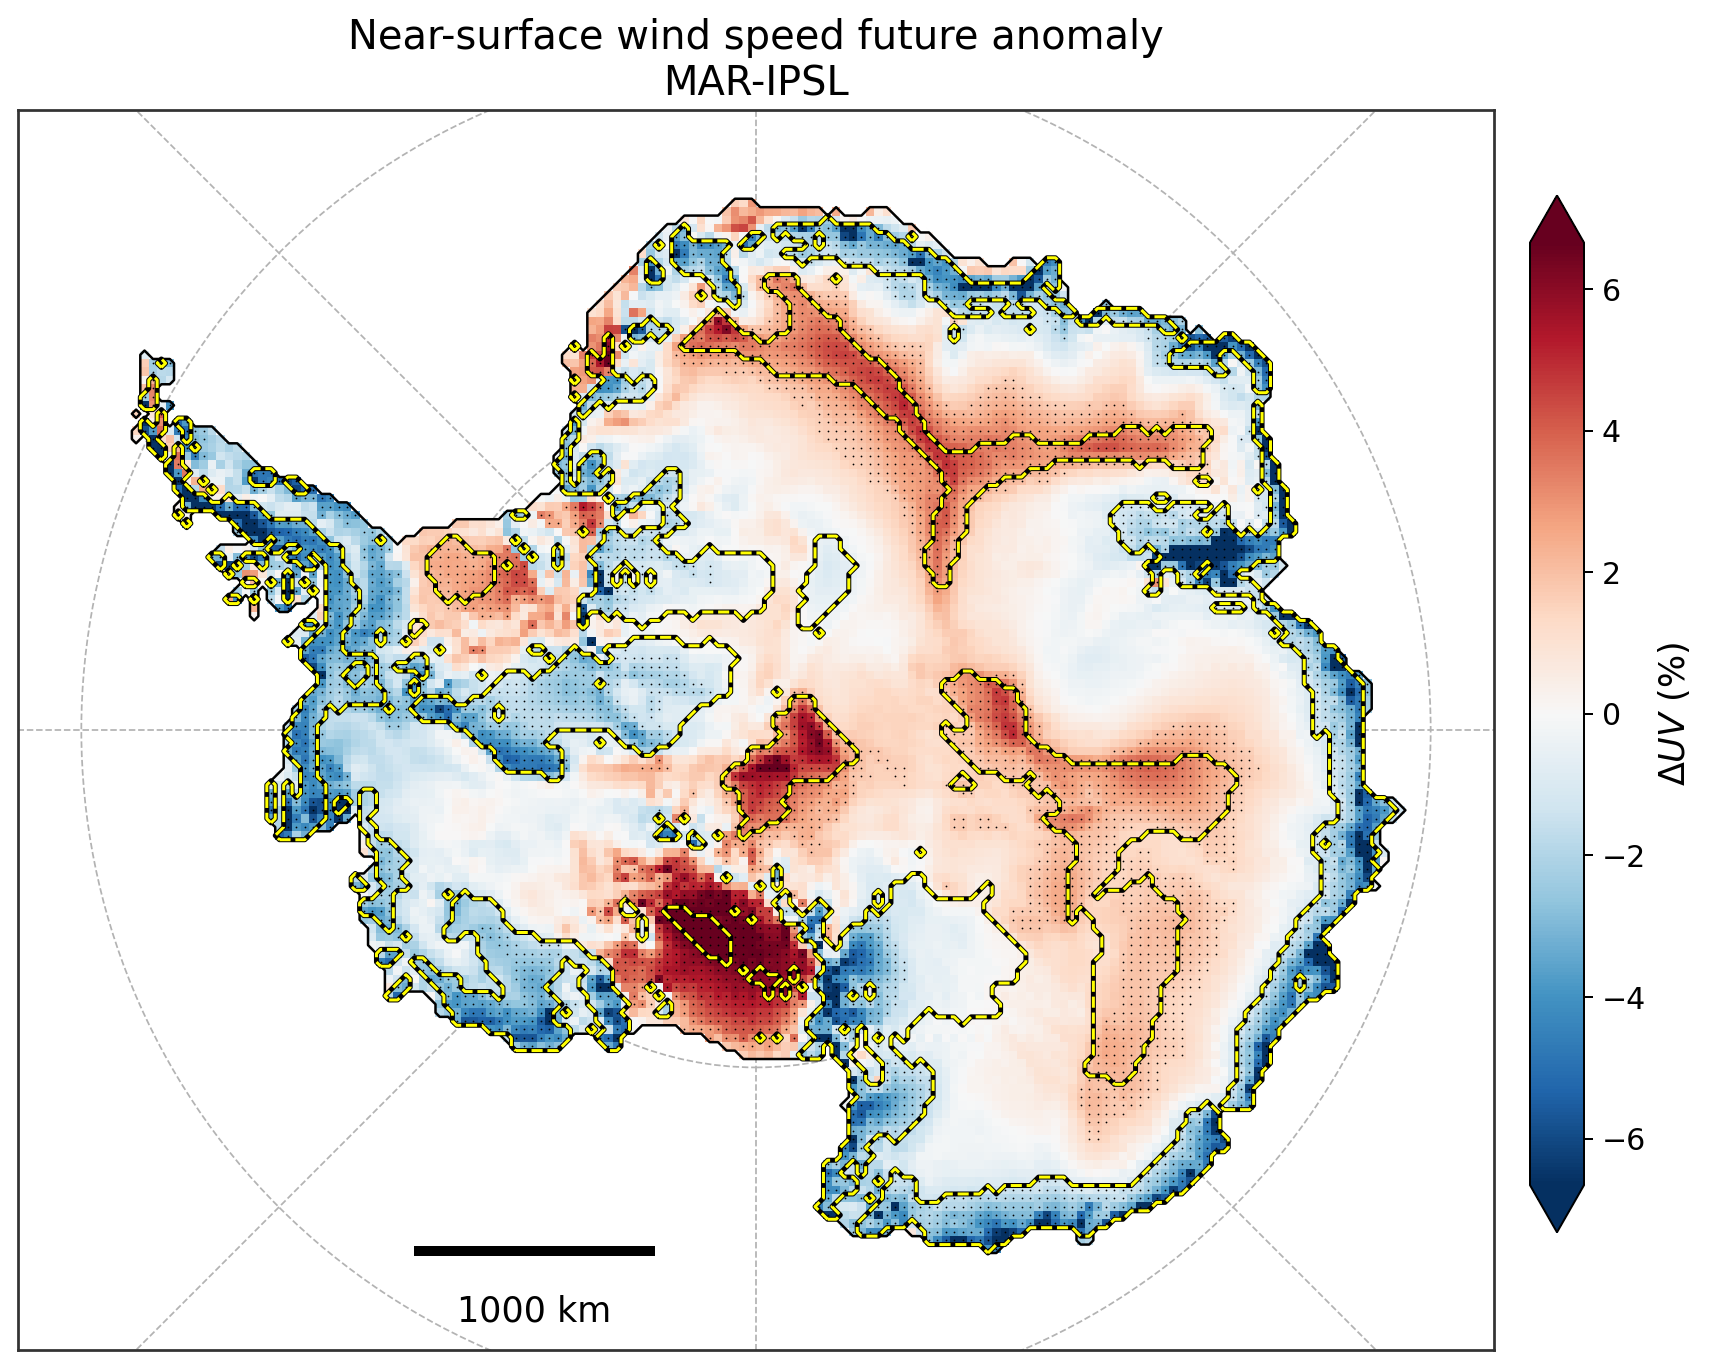

In [97]:
import numpy.ma as ma
import matplotlib.pyplot as plt

MODEL = "IPSL"   

rel_da_this = rel_all.sel(model=MODEL)
sig_da_this = sig_all.sel(model=MODEL)

rel = rel_da_this.values
sig_this = sig_da_this.values


multi_mask = sig_3plus_same_sign.values
#multi_mask = sig_3plus.values

field = ma.array(rel, mask=lsm_use)

v = field.compressed()
vmax = np.nanpercentile(np.abs(v), 98) if v.size else 10.0
if not np.isfinite(vmax) or vmax == 0:
    vmax = 10.0

xmin, xmax = float(np.nanmin(Xplot)), float(np.nanmax(Xplot))
ymin, ymax = float(np.nanmin(Yplot)), float(np.nanmax(Yplot))
cx, cy = 0.5 * (xmin + xmax), 0.5 * (ymin + ymax)
corners = np.array([[xmin, ymin], [xmin, ymax], [xmax, ymin], [xmax, ymax]], dtype=float)
rmax = float(np.max(np.sqrt((corners[:, 0] - cx) ** 2 + (corners[:, 1] - cy) ** 2)))

fig, ax = plt.subplots(1, 1, figsize=(10, 9), dpi=180)
plt.subplots_adjust(left=0.04, right=0.86, top=0.92, bottom=0.06)

_draw_polar_guides(ax, cx, cy, rmax)

im = ax.pcolormesh(
    Xplot, Yplot, field,
    shading="auto", cmap="RdBu_r",
    vmin=-vmax, vmax=vmax, zorder=3
)


ax.contour(
    Xplot, Yplot, (~lsm_use).astype(float),
    levels=[0.5], colors="k", linewidths=1.0, zorder=5
)

# 1) dots: significant in this model
sig_show = sig_this & (~lsm_use) & np.isfinite(rel)
iy, ix = np.where(sig_show)
ax.scatter(
    Xplot[iy, ix], Yplot[iy, ix],
    s=2, c="k", marker=".", linewidths=0, zorder=9
)

# 2) thick contour: significant in 3+ models
multi_show = multi_mask & (~lsm_use) & np.isfinite(rel)

# black underlay
ax.contour(
    Xplot, Yplot,
    multi_show.astype(float),
    levels=[0.5],
    colors="k",
    linewidths=2,
    zorder=10
)


ax.contour(
    Xplot, Yplot,
    multi_show.astype(float),
    levels=[0.5],
    colors="yellow",
    linewidths=1.2,
    linestyles="--",
    zorder=11
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

for sp in ax.spines.values():
    sp.set_linewidth(1.1)
    sp.set_color("0.2")

_add_scalebar_1000km(ax, xmin, xmax, ymin, ymax)
ax.set_title(f"Near-surface wind speed future anomaly\nMAR-{MODEL}", fontsize=16)

cax = fig.add_axes([0.88, 0.18, 0.03, 0.64])
cb = fig.colorbar(im, cax=cax, extend="both")
cb.set_label(r"$\Delta UV$ (%)", fontsize=14)
cb.ax.tick_params(labelsize=12)

plt.show()

## Surface density

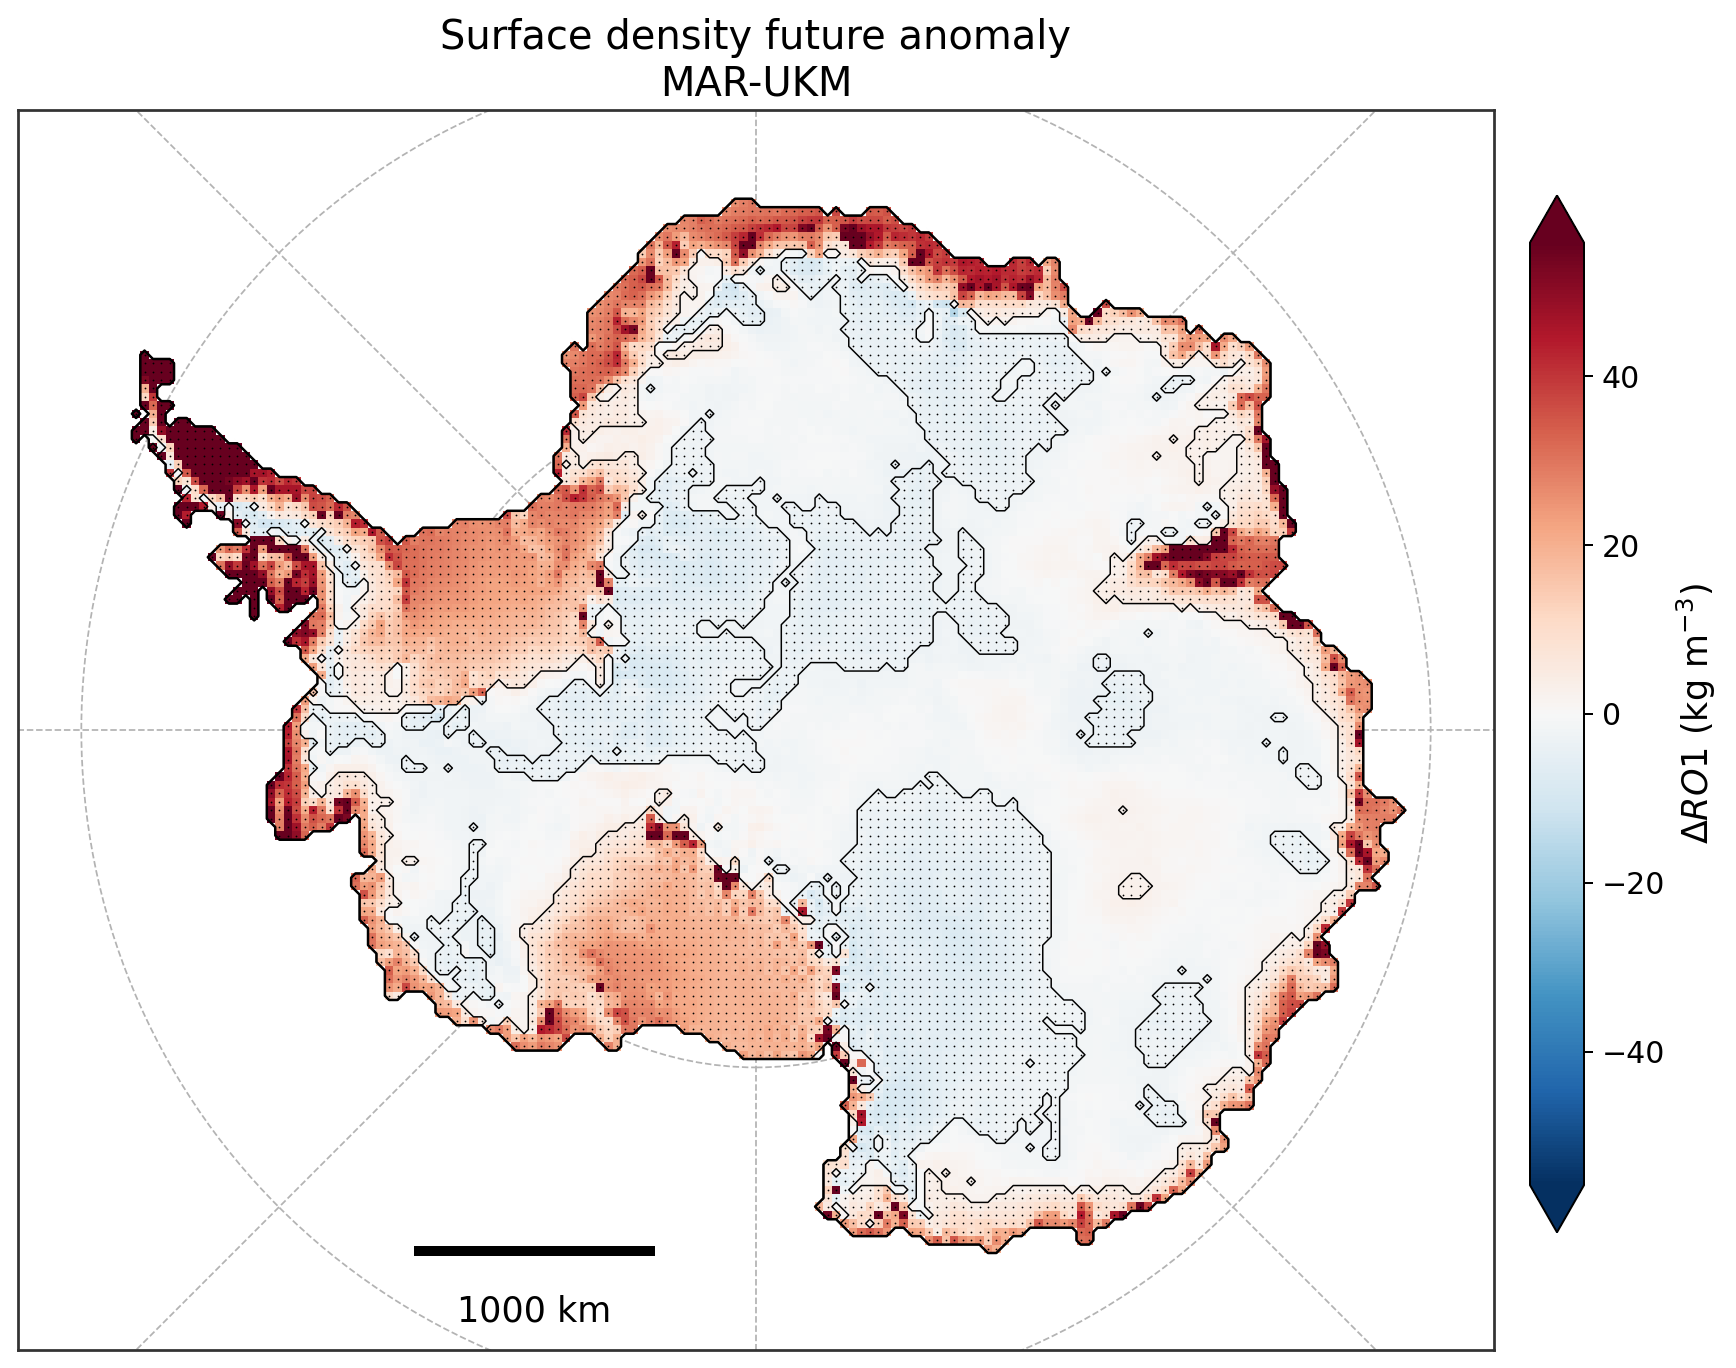

In [ ]:
import numpy as np
import numpy.ma as ma
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import ttest_ind, f as f_dist

# paths and periods
BASE_Y0, BASE_Y1 = 1981, 2010
FUT_Y0,  FUT_Y1  = 2071, 2100
ALPHA = 0.05

BASE_DIR = "/Users/dashakan/Desktop/scripts_AIS/winddensity/"
FILE_TMPL = "year-UV-RHO-USTH-MAR-DS_{MODEL}-1980-2100.nc"
MODEL = "UKM"   # "UKM", "CM6", "MPI", "IPL"

def preprocess_uv_rho_usth(ds):
    ds_new = ds


    for dim_name in ["SECTOR", "SECTOR1_1"]:
        if dim_name in ds_new.dims or dim_name in ds_new.coords:
            try:
                ds_new = ds_new.sel({dim_name: 1})
            except Exception:
                pass

    # near-surface wind
    if "UV" in ds_new and "ATMLAY" in ds_new["UV"].dims:
        try:
            ds_new["UV"] = ds_new["UV"].sel(ATMLAY=0.99973)
        except Exception:
            pass


    if "OUTLAY" in ds_new.dims or "OUTLAY" in ds_new.coords:
        try:
            ds_new = ds_new.sel(OUTLAY="0")
        except Exception:
            try:
                ds_new = ds_new.sel(OUTLAY=0)
            except Exception:
                pass


    rename = {}
    if "x" in ds_new.dims and "X" not in ds_new.dims:
        rename["x"] = "X"
    if "y" in ds_new.dims and "Y" not in ds_new.dims:
        rename["y"] = "Y"
    if rename:
        ds_new = ds_new.rename(rename)

    return ds_new


def _draw_polar_guides(ax, cx, cy, rmax):
    for frac in [0.35, 0.70, 1.00]:
        ax.add_patch(Circle((cx, cy), frac * rmax, fill=False,
                            ls="--", lw=0.7, ec="0.7", zorder=2))
    for ang in [0, 45, 90, 135]:
        t = np.deg2rad(ang)
        dx = np.array([-rmax, rmax]) * np.cos(t)
        dy = np.array([-rmax, rmax]) * np.sin(t)
        ax.plot(cx + dx, cy + dy, ls="--", lw=0.7, color="0.7", zorder=2)

def _add_scalebar_1000km(ax, xmin, xmax, ymin, ymax,
                         length=1000.0, xfrac=0.35, yfrac=0.08):
    W, H = (xmax - xmin), (ymax - ymin)
    xc = xmin + xfrac * W
    x0, x1 = xc - 0.5 * length, xc + 0.5 * length
    y = ymin + yfrac * H
    ax.plot([x0, x1], [y, y], color="k", lw=4, solid_capstyle="butt", zorder=20)
    ax.text(xc, y - 0.035 * H, "1000 km", ha="center", va="top",
            fontsize=14, color="k", zorder=21)


def _subset_years(da, y0, y1):
    years = da["TIME"].dt.year
    return da.where((years >= y0) & (years <= y1), drop=True)

def _fisher_pvalue_1d(a, b):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if (a.size < 2) or (b.size < 2):
        return np.nan
    v1 = np.var(a, ddof=1)
    v2 = np.var(b, ddof=1)
    if (v1 <= 0) or (v2 <= 0):
        return np.nan
    F = v1 / v2
    df1, df2 = a.size - 1, b.size - 1
    cdf = f_dist.cdf(F, df1, df2)
    return 2 * min(cdf, 1 - cdf)

def _ttest_pvalue_1d(a, b, equal_var):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if (a.size < 2) or (b.size < 2):
        return np.nan
    _, p = ttest_ind(a, b, equal_var=equal_var)
    return p

def pixel_pvals_student_or_welch(da, base=(BASE_Y0, BASE_Y1), fut=(FUT_Y0, FUT_Y1), alpha=ALPHA):
   
    try:
        da = da.chunk({"TIME": -1})
    except Exception:
        pass

    A = _subset_years(da, base[0], base[1])
    B = _subset_years(da, fut[0], fut[1])

    p_fisher = xr.apply_ufunc(
        _fisher_pvalue_1d,
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={"allow_rechunk": True},
        output_dtypes=[float],
        join="override",
    )
    equal_var = (p_fisher > 0.05).fillna(False)

    p_student = xr.apply_ufunc(
        lambda a, b: _ttest_pvalue_1d(a, b, True),
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={"allow_rechunk": True},
        output_dtypes=[float],
        join="override",
    )

    p_welch = xr.apply_ufunc(
        lambda a, b: _ttest_pvalue_1d(a, b, False),
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={"allow_rechunk": True},
        output_dtypes=[float],
        join="override",
    )

    p_ttest = xr.where(equal_var, p_student, p_welch)
    sig = (p_ttest < alpha)
    return p_ttest, sig


fn = BASE_DIR + FILE_TMPL.format(MODEL=MODEL)
ds = xr.open_mfdataset(
    fn,
    decode_times=False,
    preprocess=preprocess_uv_rho_usth,
    engine="netcdf4",
    combine="by_coords"
)

dates = pd.date_range("1980-01-01", "2100-01-01", freq="YS")
ds = ds.assign_coords(TIME=("TIME", dates))

RO1 = ds["RO1"]

if "x" in RO1.dims and "X" not in RO1.dims:
    RO1 = RO1.rename({"x": "X"})
if "y" in RO1.dims and "Y" not in RO1.dims:
    RO1 = RO1.rename({"y": "Y"})


X_full = x2D[0, :]
Y_full = y2D[:, 0]

lsm_da_full = xr.DataArray(lsm, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})
X_da_full   = xr.DataArray(x2D + dh, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})
Y_da_full   = xr.DataArray(y2D + dh, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})

Xro1 = RO1["X"].values
Yro1 = RO1["Y"].values

lsm_use = lsm_da_full.sel(X=Xro1, method="nearest")
Xplot   = X_da_full.sel(X=Xro1, method="nearest")
Yplot   = Y_da_full.sel(X=Xro1, method="nearest")


if lsm_use.sizes["Y"] != len(Yro1):
    lsm_use = lsm_use.sel(Y=Yro1, method="nearest")
    Xplot   = Xplot.sel(Y=Yro1, method="nearest")
    Yplot   = Yplot.sel(Y=Yro1, method="nearest")

lsm_use = lsm_use.values
Xplot = Xplot.values
Yplot = Yplot.values


mask_da = xr.DataArray(
    lsm_use,
    dims=("Y", "X"),
    coords={"Y": RO1["Y"].values, "X": RO1["X"].values}
)
RO1m = RO1.where(~mask_da)


try:
    RO1m = RO1m.chunk({"TIME": -1, "Y": 200, "X": 200})
except Exception:
    pass

A = _subset_years(RO1m, BASE_Y0, BASE_Y1)
B = _subset_years(RO1m, FUT_Y0, FUT_Y1)

base_mean = A.mean("TIME", skipna=True)
fut_mean  = B.mean("TIME", skipna=True)

change_da = fut_mean - base_mean

# significance
p_da, sig_da = pixel_pvals_student_or_welch(RO1m)

change = change_da.values
sig = sig_da.values

field = ma.array(change, mask=lsm_use)


v = field.compressed()
vmax = np.nanpercentile(np.abs(v), 98) if v.size else 10.0
if not np.isfinite(vmax) or vmax == 0:
    vmax = 10.0

xmin, xmax = float(np.nanmin(Xplot)), float(np.nanmax(Xplot))
ymin, ymax = float(np.nanmin(Yplot)), float(np.nanmax(Yplot))
cx, cy = 0.5 * (xmin + xmax), 0.5 * (ymin + ymax)

corners = np.array([[xmin, ymin], [xmin, ymax], [xmax, ymin], [xmax, ymax]], dtype=float)
rmax = float(np.max(np.sqrt((corners[:, 0] - cx) ** 2 + (corners[:, 1] - cy) ** 2)))

fig, ax = plt.subplots(1, 1, figsize=(10, 9), dpi=180)
plt.subplots_adjust(left=0.04, right=0.86, top=0.92, bottom=0.06)

_draw_polar_guides(ax, cx, cy, rmax)

im = ax.pcolormesh(
    Xplot, Yplot, field,
    shading="auto",
    cmap="RdBu_r",
    vmin=-vmax, vmax=vmax,
    zorder=3

ax.contour(
    Xplot, Yplot, (~lsm_use).astype(float),
    levels=[0.5], colors="k", linewidths=1.0, zorder=5
)

sig_show = sig & (~lsm_use) & np.isfinite(change)

ax.contour(
    Xplot, Yplot, sig_show.astype(float),
    levels=[0.5], colors="black", linewidths=0.6, zorder=9
)

iy, ix = np.where(sig_show)
ax.scatter(
    Xplot[iy, ix], Yplot[iy, ix],
    s=2, c="black", marker=".", linewidths=0, zorder=10
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

for sp in ax.spines.values():
    sp.set_linewidth(1.1)
    sp.set_color("0.2")

_add_scalebar_1000km(ax, xmin, xmax, ymin, ymax)

ax.set_title(f"Surface density future anomaly\nMAR-{MODEL}", fontsize=16)

cax = fig.add_axes([0.88, 0.18, 0.03, 0.64])
cb = fig.colorbar(im, cax=cax, extend="both")
cb.set_label(r"$\Delta RO1$ (kg m$^{-3}$)", fontsize=14)
cb.ax.tick_params(labelsize=12)

plt.show()

## Threshold friction velocity

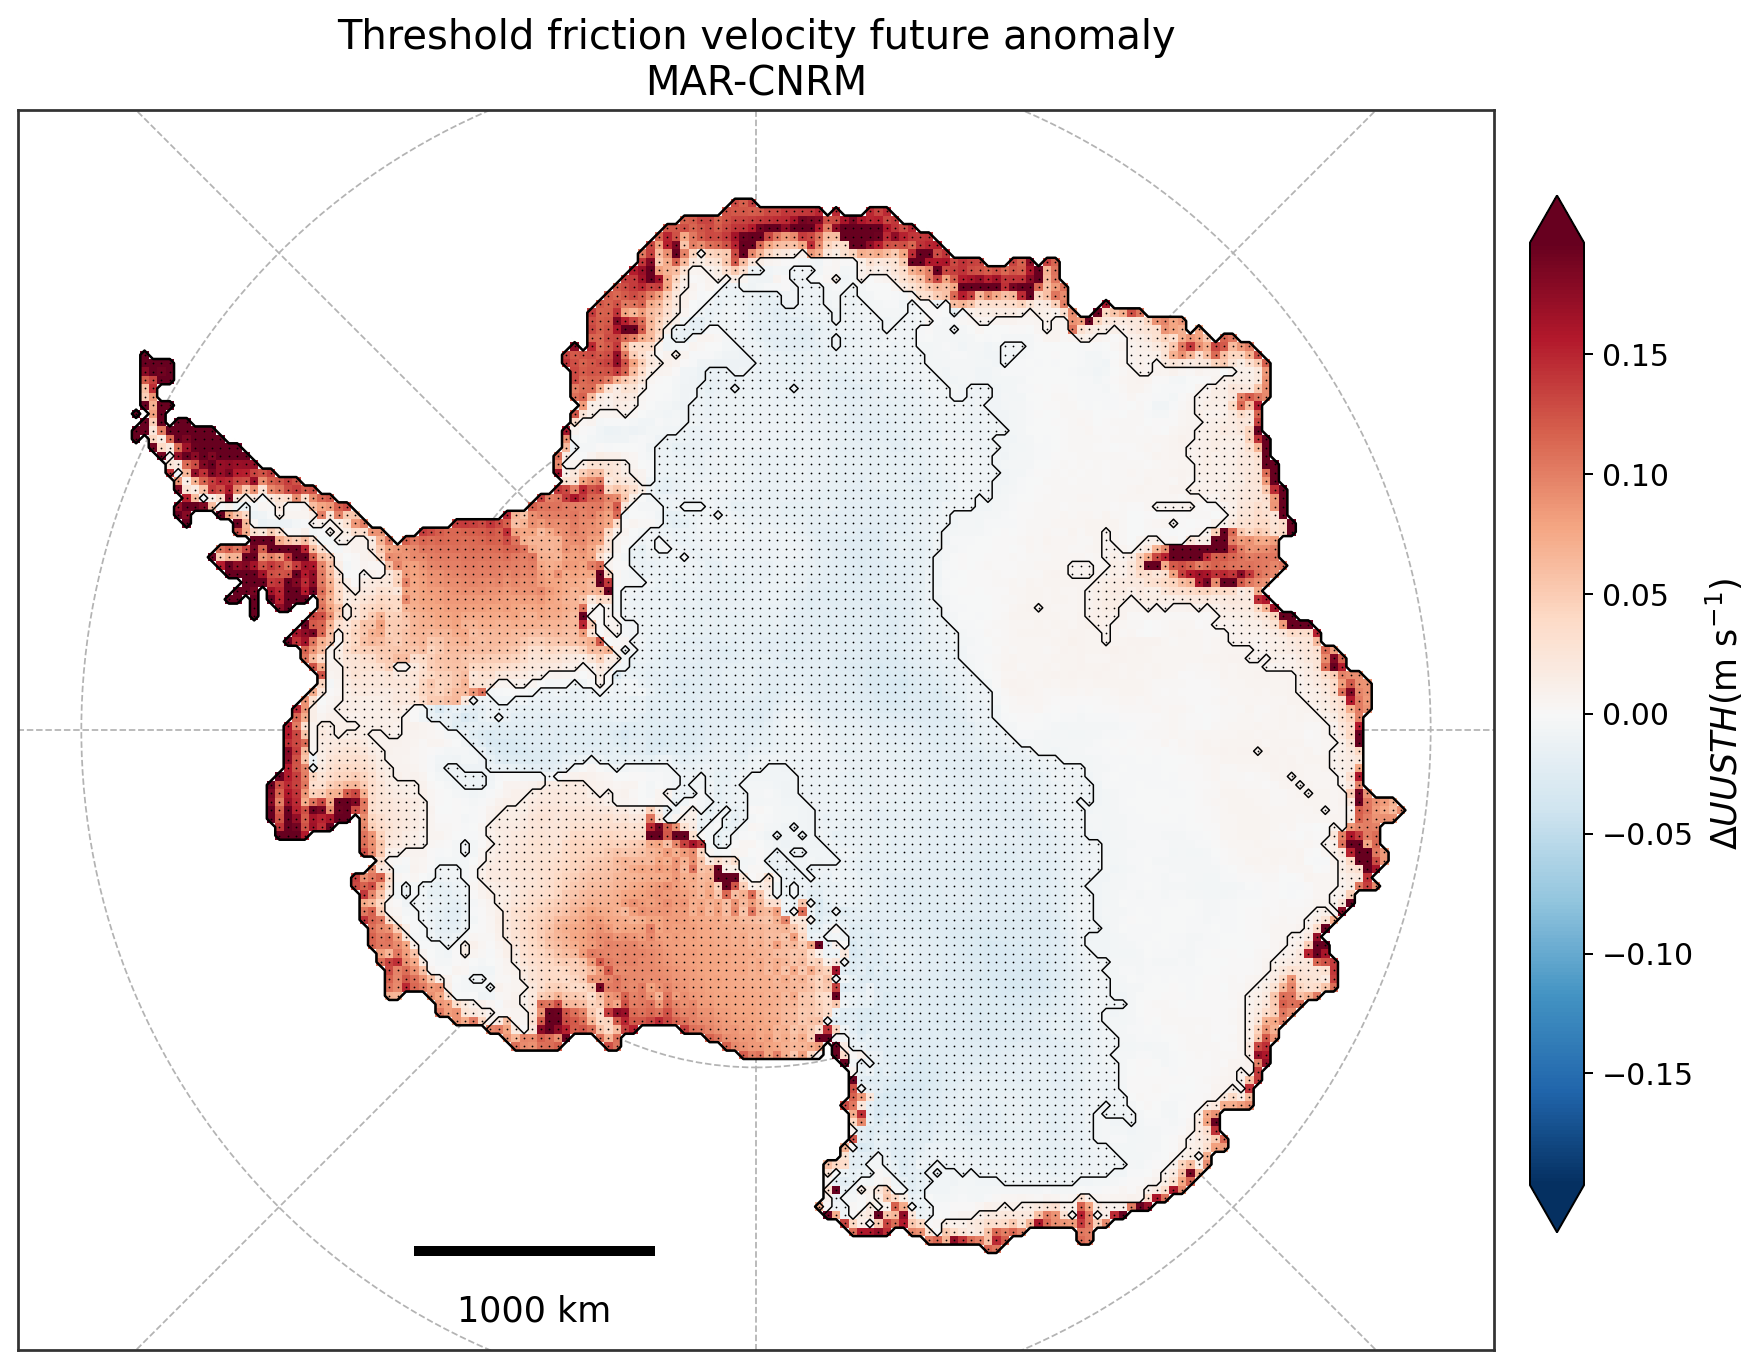

In [ ]:
import numpy as np
import numpy.ma as ma
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import ttest_ind, f as f_dist


BASE_Y0, BASE_Y1 = 1981, 2010
FUT_Y0,  FUT_Y1  = 2071, 2100
ALPHA = 0.05

BASE_DIR = "/Users/dashakan/Desktop/scripts_AIS/winddensity/"
FILE_TMPL = "year-UV-RHO-USTH-MAR-DS_{MODEL}-1980-2100.nc"
MODEL = "CNRM"   # "UKM", "CM6", "MPI", "IPL"

def preprocess_uv_rho_usth(ds):
    ds_new = ds

  
    for dim_name in ["SECTOR", "SECTOR1_1"]:
        if dim_name in ds_new.dims or dim_name in ds_new.coords:
            try:
                ds_new = ds_new.sel({dim_name: 1})
            except Exception:
                pass

   
    if "UV" in ds_new and "ATMLAY" in ds_new["UV"].dims:
        try:
            ds_new["UV"] = ds_new["UV"].sel(ATMLAY=0.99973)
        except Exception:
            pass

 
    if "OUTLAY" in ds_new.dims or "OUTLAY" in ds_new.coords:
        try:
            ds_new = ds_new.sel(OUTLAY="0")
        except Exception:
            try:
                ds_new = ds_new.sel(OUTLAY=0)
            except Exception:
                pass

  
    rename = {}
    if "x" in ds_new.dims and "X" not in ds_new.dims:
        rename["x"] = "X"
    if "y" in ds_new.dims and "Y" not in ds_new.dims:
        rename["y"] = "Y"
    if rename:
        ds_new = ds_new.rename(rename)

    return ds_new


def _draw_polar_guides(ax, cx, cy, rmax):
    for frac in [0.35, 0.70, 1.00]:
        ax.add_patch(Circle((cx, cy), frac * rmax, fill=False,
                            ls="--", lw=0.7, ec="0.7", zorder=2))
    for ang in [0, 45, 90, 135]:
        t = np.deg2rad(ang)
        dx = np.array([-rmax, rmax]) * np.cos(t)
        dy = np.array([-rmax, rmax]) * np.sin(t)
        ax.plot(cx + dx, cy + dy, ls="--", lw=0.7, color="0.7", zorder=2)

def _add_scalebar_1000km(ax, xmin, xmax, ymin, ymax,
                         length=1000.0, xfrac=0.35, yfrac=0.08):
    W, H = (xmax - xmin), (ymax - ymin)
    xc = xmin + xfrac * W
    x0, x1 = xc - 0.5 * length, xc + 0.5 * length
    y = ymin + yfrac * H
    ax.plot([x0, x1], [y, y], color="k", lw=4, solid_capstyle="butt", zorder=20)
    ax.text(xc, y - 0.035 * H, "1000 km", ha="center", va="top",
            fontsize=14, color="k", zorder=21)


def _subset_years(da, y0, y1):
    years = da["TIME"].dt.year
    return da.where((years >= y0) & (years <= y1), drop=True)

def _fisher_pvalue_1d(a, b):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if (a.size < 2) or (b.size < 2):
        return np.nan
    v1 = np.var(a, ddof=1)
    v2 = np.var(b, ddof=1)
    if (v1 <= 0) or (v2 <= 0):
        return np.nan
    F = v1 / v2
    df1, df2 = a.size - 1, b.size - 1
    cdf = f_dist.cdf(F, df1, df2)
    return 2 * min(cdf, 1 - cdf)

def _ttest_pvalue_1d(a, b, equal_var):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if (a.size < 2) or (b.size < 2):
        return np.nan
    _, p = ttest_ind(a, b, equal_var=equal_var)
    return p

def pixel_pvals_student_or_welch(da, base=(BASE_Y0, BASE_Y1), fut=(FUT_Y0, FUT_Y1), alpha=ALPHA):
   
    try:
        da = da.chunk({"TIME": -1})
    except Exception:
        pass

    A = _subset_years(da, base[0], base[1])
    B = _subset_years(da, fut[0], fut[1])

    p_fisher = xr.apply_ufunc(
        _fisher_pvalue_1d,
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={"allow_rechunk": True},
        output_dtypes=[float],
        join="override",
    )
    equal_var = (p_fisher > 0.05).fillna(False)

    p_student = xr.apply_ufunc(
        lambda a, b: _ttest_pvalue_1d(a, b, True),
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={"allow_rechunk": True},
        output_dtypes=[float],
        join="override",
    )

    p_welch = xr.apply_ufunc(
        lambda a, b: _ttest_pvalue_1d(a, b, False),
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={"allow_rechunk": True},
        output_dtypes=[float],
        join="override",
    )

    p_ttest = xr.where(equal_var, p_student, p_welch)
    sig = (p_ttest < alpha)
    return p_ttest, sig


fn = BASE_DIR + FILE_TMPL.format(MODEL=MODEL)
ds = xr.open_mfdataset(
    fn,
    decode_times=False,
    preprocess=preprocess_uv_rho_usth,
    engine="netcdf4",
    combine="by_coords"
)

dates = pd.date_range("1980-01-01", "2100-01-01", freq="YS")
ds = ds.assign_coords(TIME=("TIME", dates))

UUSTH = ds["UUSTH"]

if "x" in UUSTH.dims and "X" not in UUSTH.dims:
    UUSTH = UUSTH.rename({"x": "X"})
if "y" in UUSTH.dims and "Y" not in UUSTH.dims:
    UUSTH = UUSTH.rename({"y": "Y"})

X_full = x2D[0, :]
Y_full = y2D[:, 0]

lsm_da_full = xr.DataArray(lsm, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})
X_da_full   = xr.DataArray(x2D + dh, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})
Y_da_full   = xr.DataArray(y2D + dh, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})

Xu = UUSTH["X"].values
Yu = UUSTH["Y"].values

lsm_use = lsm_da_full.sel(X=Xu, method="nearest")
Xplot   = X_da_full.sel(X=Xu, method="nearest")
Yplot   = Y_da_full.sel(X=Xu, method="nearest")

if lsm_use.sizes["Y"] != len(Yu):
    lsm_use = lsm_use.sel(Y=Yu, method="nearest")
    Xplot   = Xplot.sel(Y=Yu, method="nearest")
    Yplot   = Yplot.sel(Y=Yu, method="nearest")

lsm_use = lsm_use.values
Xplot = Xplot.values
Yplot = Yplot.values

mask_da = xr.DataArray(
    lsm_use,
    dims=("Y", "X"),
    coords={"Y": UUSTH["Y"].values, "X": UUSTH["X"].values}
)
UUSTHm = UUSTH.where(~mask_da)


try:
    UUSTHm = UUSTHm.chunk({"TIME": -1, "Y": 200, "X": 200})
except Exception:
    pass


A = _subset_years(UUSTHm, BASE_Y0, BASE_Y1)
B = _subset_years(UUSTHm, FUT_Y0, FUT_Y1)

base_mean = A.mean("TIME", skipna=True)
fut_mean  = B.mean("TIME", skipna=True)

change_da = fut_mean - base_mean


p_da, sig_da = pixel_pvals_student_or_welch(UUSTHm)

change = change_da.values
sig = sig_da.values

field = ma.array(change, mask=lsm_use)


v = field.compressed()
vmax = np.nanpercentile(np.abs(v), 98) if v.size else 0.1
if not np.isfinite(vmax) or vmax == 0:
    vmax = 0.1

xmin, xmax = float(np.nanmin(Xplot)), float(np.nanmax(Xplot))
ymin, ymax = float(np.nanmin(Yplot)), float(np.nanmax(Yplot))
cx, cy = 0.5 * (xmin + xmax), 0.5 * (ymin + ymax)

corners = np.array([[xmin, ymin], [xmin, ymax], [xmax, ymin], [xmax, ymax]], dtype=float)
rmax = float(np.max(np.sqrt((corners[:, 0] - cx) ** 2 + (corners[:, 1] - cy) ** 2)))

fig, ax = plt.subplots(1, 1, figsize=(10, 9), dpi=180)
plt.subplots_adjust(left=0.04, right=0.86, top=0.92, bottom=0.06)

_draw_polar_guides(ax, cx, cy, rmax)

im = ax.pcolormesh(
    Xplot, Yplot, field,
    shading="auto",
    cmap="RdBu_r",
    vmin=-vmax, vmax=vmax,
    zorder=3
)


ax.contour(
    Xplot, Yplot, (~lsm_use).astype(float),
    levels=[0.5], colors="k", linewidths=1.0, zorder=5
)


sig_show = sig & (~lsm_use) & np.isfinite(change)

ax.contour(
    Xplot, Yplot, sig_show.astype(float),
    levels=[0.5], colors="black", linewidths=0.6, zorder=9
)

iy, ix = np.where(sig_show)
ax.scatter(
    Xplot[iy, ix], Yplot[iy, ix],
    s=2, c="black", marker=".", linewidths=0, zorder=10
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

for sp in ax.spines.values():
    sp.set_linewidth(1.1)
    sp.set_color("0.2")

_add_scalebar_1000km(ax, xmin, xmax, ymin, ymax)

ax.set_title(f"Threshold friction velocity future anomaly\nMAR-{MODEL}", fontsize=16)

cax = fig.add_axes([0.88, 0.18, 0.03, 0.64])
cb = fig.colorbar(im, cax=cax, extend="both")
cb.set_label(r"$\Delta UUSTH$(m s$^{-1}$)", fontsize=14)
cb.ax.tick_params(labelsize=12)

plt.show()

## Melt and temperature

### Melt or temperature change map

Reads the main DS output. Switch `VAR` between TT and ME.

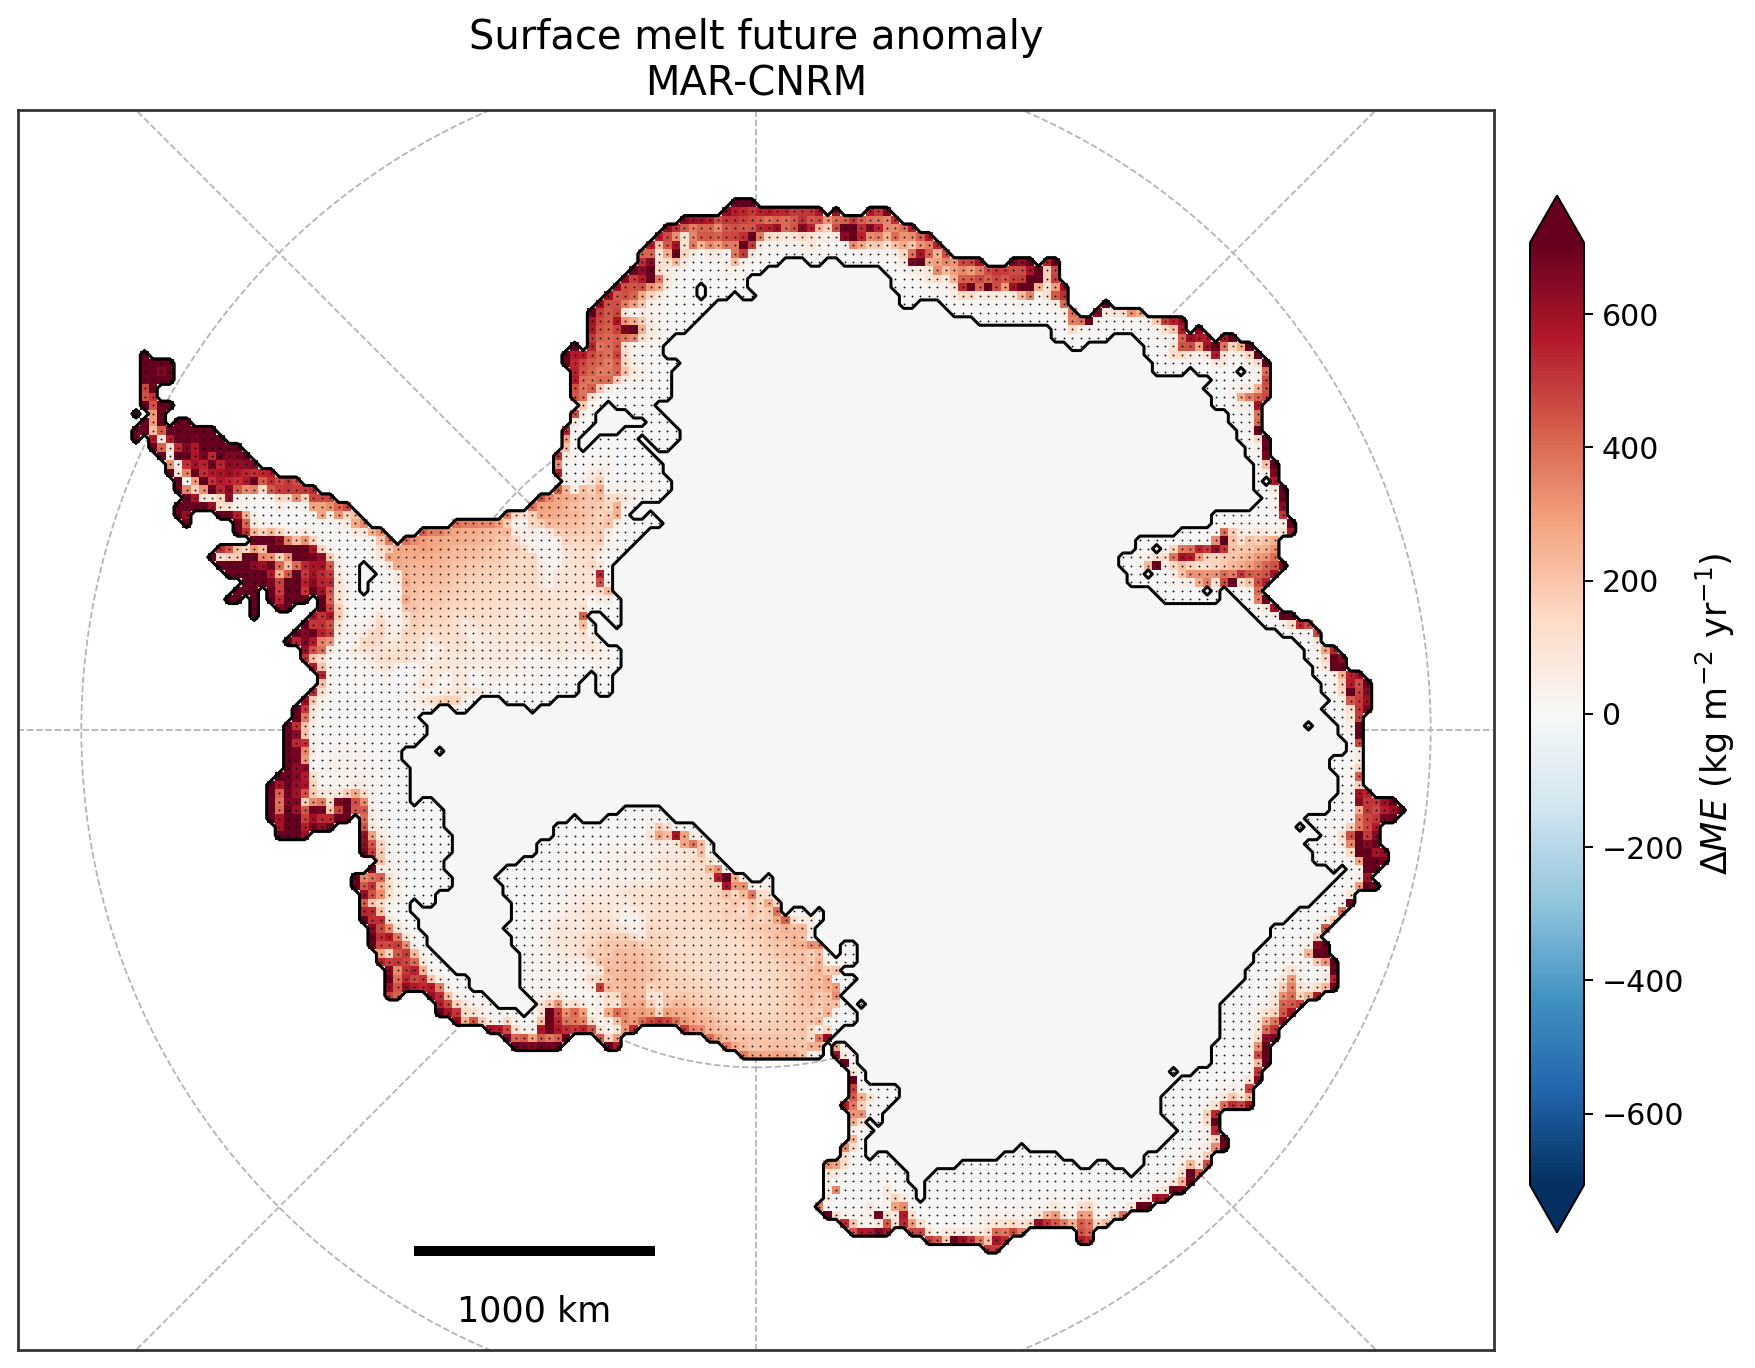

In [ ]:
import numpy as np
import numpy.ma as ma
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import ttest_ind, f as f_dist

# paths and periods
BASE_Y0, BASE_Y1 = 1981, 2010
FUT_Y0,  FUT_Y1  = 2071, 2100
ALPHA = 0.05

BASE_DIR = "/Users/dashakan/Desktop/scripts_AIS/"
FILE_TMPL = "year-MAR-DS_{MODEL}-1980-2100.nc"

MODEL = "CNRM"   # "UKM", "CNRM", "MPI", "IPL"
VAR   = "ME"     # "TT" or "ME"


def preprocess_mar_usual(ds):
    ds_new = ds

    for dim_name in ["SECTOR", "SECTOR1_1"]:
        if dim_name in ds_new.dims or dim_name in ds_new.coords:
            try:
                ds_new = ds_new.sel({dim_name: 1})
            except Exception:
                pass

    if "TT" in ds_new and "ATMLAY" in ds_new["TT"].dims:
        try:
            ds_new["TT"] = ds_new["TT"].sel(ATMLAY=0.99973)
        except Exception:
            pass

    rename = {}
    if "x" in ds_new.dims and "X" not in ds_new.dims:
        rename["x"] = "X"
    if "y" in ds_new.dims and "Y" not in ds_new.dims:
        rename["y"] = "Y"
    if rename:
        ds_new = ds_new.rename(rename)

    return ds_new

# plot styling
def _draw_polar_guides(ax, cx, cy, rmax):
    for frac in [0.35, 0.70, 1.00]:
        ax.add_patch(Circle((cx, cy), frac * rmax, fill=False,
                            ls="--", lw=0.7, ec="0.7", zorder=2))
    for ang in [0, 45, 90, 135]:
        t = np.deg2rad(ang)
        dx = np.array([-rmax, rmax]) * np.cos(t)
        dy = np.array([-rmax, rmax]) * np.sin(t)
        ax.plot(cx + dx, cy + dy, ls="--", lw=0.7, color="0.7", zorder=2)

def _add_scalebar_1000km(ax, xmin, xmax, ymin, ymax,
                         length=1000.0, xfrac=0.35, yfrac=0.08):
    W, H = (xmax - xmin), (ymax - ymin)
    xc = xmin + xfrac * W
    x0, x1 = xc - 0.5 * length, xc + 0.5 * length
    y = ymin + yfrac * H
    ax.plot([x0, x1], [y, y], color="k", lw=4, solid_capstyle="butt", zorder=20)
    ax.text(xc, y - 0.035 * H, "1000 km", ha="center", va="top",
            fontsize=14, color="k", zorder=21)

# time axis and test helpers
def _subset_years(da, y0, y1):
    years = da["TIME"].dt.year
    return da.where((years >= y0) & (years <= y1), drop=True)

def _fisher_pvalue_1d(a, b):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if (a.size < 2) or (b.size < 2):
        return np.nan
    v1 = np.var(a, ddof=1)
    v2 = np.var(b, ddof=1)
    if (v1 <= 0) or (v2 <= 0):
        return np.nan
    F = v1 / v2
    df1, df2 = a.size - 1, b.size - 1
    cdf = f_dist.cdf(F, df1, df2)
    return 2 * min(cdf, 1 - cdf)

def _ttest_pvalue_1d(a, b, equal_var):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if (a.size < 2) or (b.size < 2):
        return np.nan
    _, p = ttest_ind(a, b, equal_var=equal_var)
    return p

def pixel_pvals_student_or_welch(da, base=(BASE_Y0, BASE_Y1), fut=(FUT_Y0, FUT_Y1), alpha=ALPHA):
    try:
        da = da.chunk({"TIME": -1})
    except Exception:
        pass

    A = _subset_years(da, base[0], base[1])
    B = _subset_years(da, fut[0], fut[1])

    p_fisher = xr.apply_ufunc(
        _fisher_pvalue_1d,
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={"allow_rechunk": True},
        output_dtypes=[float],
        join="override",
    )
    equal_var = (p_fisher > 0.05).fillna(False)

    p_student = xr.apply_ufunc(
        lambda a, b: _ttest_pvalue_1d(a, b, True),
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={"allow_rechunk": True},
        output_dtypes=[float],
        join="override",
    )

    p_welch = xr.apply_ufunc(
        lambda a, b: _ttest_pvalue_1d(a, b, False),
        A, B,
        input_core_dims=[["TIME"], ["TIME"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={"allow_rechunk": True},
        output_dtypes=[float],
        join="override",
    )

    p_ttest = xr.where(equal_var, p_student, p_welch)
    sig = (p_ttest < alpha)
    return p_ttest, sig


TITLE_MAP = {
    "TT": "Near-surface temperature future anomaly",
    "ME": "Surface melt future anomaly",
}
CBAR_MAP = {
    "TT": (r"$\Delta TT$ (°C)", 2.0),
    "ME": (r"$\Delta ME$ (kg m$^{-2}$ yr$^{-1}$)", 50.0),
}


fn = BASE_DIR + FILE_TMPL.format(MODEL=MODEL)
ds = xr.open_mfdataset(
    fn,
    decode_times=False,
    preprocess=preprocess_mar_usual,
    engine="netcdf4",
    combine="by_coords"
)

dates = pd.date_range("1980-01-01", "2100-01-01", freq="YS")
ds = ds.assign_coords(TIME=("TIME", dates))

DA = ds[VAR]

if "x" in DA.dims and "X" not in DA.dims:
    DA = DA.rename({"x": "X"})
if "y" in DA.dims and "Y" not in DA.dims:
    DA = DA.rename({"y": "Y"})

X_full = x2D[0, :]
Y_full = y2D[:, 0]

lsm_da_full = xr.DataArray(lsm, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})
X_da_full   = xr.DataArray(x2D + dh, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})
Y_da_full   = xr.DataArray(y2D + dh, dims=("Y", "X"), coords={"Y": Y_full, "X": X_full})

Xv = DA["X"].values
Yv = DA["Y"].values

lsm_use = lsm_da_full.sel(X=Xv, method="nearest")
Xplot   = X_da_full.sel(X=Xv, method="nearest")
Yplot   = Y_da_full.sel(X=Xv, method="nearest")

if lsm_use.sizes["Y"] != len(Yv):
    lsm_use = lsm_use.sel(Y=Yv, method="nearest")
    Xplot   = Xplot.sel(Y=Yv, method="nearest")
    Yplot   = Yplot.sel(Y=Yv, method="nearest")

lsm_use = lsm_use.values
Xplot = Xplot.values
Yplot = Yplot.values

mask_da = xr.DataArray(
    lsm_use,
    dims=("Y", "X"),
    coords={"Y": DA["Y"].values, "X": DA["X"].values}
)
DAm = DA.where(~mask_da)

try:
    DAm = DAm.chunk({"TIME": -1, "Y": 200, "X": 200})
except Exception:
    pass


A = _subset_years(DAm, BASE_Y0, BASE_Y1)
B = _subset_years(DAm, FUT_Y0, FUT_Y1)

base_mean = A.mean("TIME", skipna=True)
fut_mean  = B.mean("TIME", skipna=True)

change_da = fut_mean - base_mean


p_da, sig_da = pixel_pvals_student_or_welch(DAm)

change = change_da.values
sig = sig_da.values

field = ma.array(change, mask=lsm_use)


v = field.compressed()
default_vmax = CBAR_MAP[VAR][1]
vmax = np.nanpercentile(np.abs(v), 98) if v.size else default_vmax
if not np.isfinite(vmax) or vmax == 0:
    vmax = default_vmax

xmin, xmax = float(np.nanmin(Xplot)), float(np.nanmax(Xplot))
ymin, ymax = float(np.nanmin(Yplot)), float(np.nanmax(Yplot))
cx, cy = 0.5 * (xmin + xmax), 0.5 * (ymin + ymax)

corners = np.array([[xmin, ymin], [xmin, ymax], [xmax, ymin], [xmax, ymax]], dtype=float)
rmax = float(np.max(np.sqrt((corners[:, 0] - cx) ** 2 + (corners[:, 1] - cy) ** 2)))

fig, ax = plt.subplots(1, 1, figsize=(10, 9), dpi=180)
plt.subplots_adjust(left=0.04, right=0.86, top=0.92, bottom=0.06)

_draw_polar_guides(ax, cx, cy, rmax)

im = ax.pcolormesh(
    Xplot, Yplot, field,
    shading="auto",
    cmap="RdBu_r",
    vmin=-vmax, vmax=vmax,
    zorder=3
)


ax.contour(
    Xplot, Yplot, (~lsm_use).astype(float),
    levels=[0.5], colors="k", linewidths=1.0, zorder=5
)

sig_show = sig & (~lsm_use) & np.isfinite(change)

ax.contour(
    Xplot, Yplot, sig_show.astype(float),
    levels=[0.5], colors="black", linewidths=1.2, zorder=9
)

iy, ix = np.where(sig_show)
ax.scatter(
    Xplot[iy, ix], Yplot[iy, ix],
    s=2, c="black", marker=".", linewidths=0, zorder=10
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

for sp in ax.spines.values():
    sp.set_linewidth(1.1)
    sp.set_color("0.2")

_add_scalebar_1000km(ax, xmin, xmax, ymin, ymax)

ax.set_title(f"{TITLE_MAP[VAR]}\nMAR-{MODEL}", fontsize=16)

cax = fig.add_axes([0.88, 0.18, 0.03, 0.64])
cb = fig.colorbar(im, cax=cax, extend="both")
cb.set_label(CBAR_MAP[VAR][0], fontsize=14)
cb.ax.tick_params(labelsize=12)

plt.show()